In [1]:
# CELL 1 — IMPORTS
# ─────────────────────────────────────────────────────────────
# Standard libraries
import os
import re
import json
import glob
import warnings
warnings.filterwarnings('ignore')
 
# Data processing
import pandas as pd
import numpy as np
 
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.use('Agg')
from IPython.display import display, Image
 
# Machine learning
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
 
# XGBoost and Saving
import xgboost as xgb
import joblib
 
print("All libraries imported!")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported!
XGBoost version: 3.2.0


In [2]:
# CELL 2 — PATHS
# ─────────────────────────────────────────────────────────────
BASE          = "D:/R26-IT-096/R26-IT-096/server/microservice-3/python_ml"
DATASETS_PATH = f"{BASE}/data/raw"
TEAMS_PATH    = f"{BASE}/data/raw/Teams"
 
# Lineup folder for validation
LINEUPS_PATH  = f"{DATASETS_PATH}/lineups"
 
PLAYER_RECORDS_PATH = "D:/datasets/player records"
GROUNDS_PATH        = "D:/datasets/grounds international"
 
PATHS = {
    "squads"             : f"{DATASETS_PATH}/squads.csv",
    "most_runs_t20"      : f"{DATASETS_PATH}/most_runst20_2025.csv",
    "most_runs_odi"      : f"{DATASETS_PATH}/most_runsODI_2025.csv",
    "most_runs_test"     : f"{DATASETS_PATH}/most_runsTest_2025.csv",
    "most_wickets_t20"   : f"{DATASETS_PATH}/most_wicketst20_2025.csv",
    "most_wickets_odi"   : f"{DATASETS_PATH}/most_wicketsODI_2025.csv",
    "most_wickets_test"  : f"{DATASETS_PATH}/most_wicketsTest_2025.csv",
    "best_avg_t20"       : f"{DATASETS_PATH}/best_averageT20_2025.csv",
    "best_avg_odi"       : f"{DATASETS_PATH}/best_averageODI_2025.csv",
    "best_avg_test"      : f"{DATASETS_PATH}/best_average_Test2025.csv",
    "best_economy_odi"   : f"{DATASETS_PATH}/best_economyODI_2025.csv",
    "best_economy_test"  : f"{DATASETS_PATH}/best_economyrateTest_2025.csv",
    "venues_intl"        : f"{DATASETS_PATH}/venues_international.csv",
    "matches"            : f"{DATASETS_PATH}/matches.csv",
    "batting_stats"      : f"{DATASETS_PATH}/batting_stats.csv",
    "bowling_stats"      : f"{DATASETS_PATH}/bowling_stats.csv",
    "key_scorecards"     : f"{DATASETS_PATH}/key_scorecards.csv",
    "awards"             : f"{DATASETS_PATH}/awards.csv",
    "tournament_summary" : f"{DATASETS_PATH}/tournament_summary.csv",
    "allgrounds"         : f"{GROUNDS_PATH}/allgrounds.csv",
    "odi_home_away"      : f"{GROUNDS_PATH}/odi_home_away_win.csv",
    "odi_rpo"            : f"{GROUNDS_PATH}/odi_runsscoredperover_allgrounds.csv",
    "odi_rpw"            : f"{GROUNDS_PATH}/odi_runsscoredperwicket_allgrounds.csv",
    "t20_rpo"            : f"{GROUNDS_PATH}/t20_runsscoredperover_allgrounds.csv",
    "t20_rpw"            : f"{GROUNDS_PATH}/t20_runsscoredperwicket_allgrounds.csv",
    "test_home_away"     : f"{GROUNDS_PATH}/test_home_away_win.csv",
    "test_rpo"           : f"{GROUNDS_PATH}/test_runsscoredperover_allgrounds.csv",
    "test_rpw"           : f"{GROUNDS_PATH}/test_runsscoredperwicket_allgrounds.csv",
    "test_high_stand"    : f"{GROUNDS_PATH}/test_highest_average_stands.csv",
    "test_low_stand"     : f"{GROUNDS_PATH}/test_lowest_average_opening_stand.csv",
}
 
print("=" * 60)
print("FILE CHECK")
print("=" * 60)
for name, path in PATHS.items():
    s = "FOUND  " if os.path.exists(path) else "MISSING"
    print(f"  [{s}] {name:<25} {os.path.basename(path)}")
 
print(f"\nTeams folder   : {'FOUND' if os.path.exists(TEAMS_PATH) else 'MISSING'}")
print(f"Lineups folder : {'FOUND' if os.path.exists(LINEUPS_PATH) else 'MISSING'}")
print(f"Player Records : {'FOUND' if os.path.exists(PLAYER_RECORDS_PATH) else 'MISSING'}")
print(f"Grounds folder : {'FOUND' if os.path.exists(GROUNDS_PATH) else 'MISSING'}")
 

FILE CHECK
  [FOUND  ] squads                    squads.csv
  [FOUND  ] most_runs_t20             most_runst20_2025.csv
  [FOUND  ] most_runs_odi             most_runsODI_2025.csv
  [FOUND  ] most_runs_test            most_runsTest_2025.csv
  [FOUND  ] most_wickets_t20          most_wicketst20_2025.csv
  [FOUND  ] most_wickets_odi          most_wicketsODI_2025.csv
  [FOUND  ] most_wickets_test         most_wicketsTest_2025.csv
  [FOUND  ] best_avg_t20              best_averageT20_2025.csv
  [FOUND  ] best_avg_odi              best_averageODI_2025.csv
  [FOUND  ] best_avg_test             best_average_Test2025.csv
  [FOUND  ] best_economy_odi          best_economyODI_2025.csv
  [FOUND  ] best_economy_test         best_economyrateTest_2025.csv
  [FOUND  ] venues_intl               venues_international.csv
  [FOUND  ] matches                   matches.csv
  [FOUND  ] batting_stats             batting_stats.csv
  [FOUND  ] bowling_stats             bowling_stats.csv
  [FOUND  ] key_scoreca

In [3]:
# CELL 3 — LOAD ALL DATASETS
# ─────────────────────────────────────────────────────────────
def safe_load(path, name):
    """Load CSV trying multiple encodings."""
    for enc in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"  LOADED  {name:<30} shape={str(df.shape):<14} "
                  f"cols={df.columns.tolist()[:5]}")
            return df
        except UnicodeDecodeError:
            continue
        except FileNotFoundError:
            print(f"  MISSING {name:<30} not found")
            return pd.DataFrame()
        except Exception as e:
            print(f"  ERROR   {name:<30} {e}")
            return pd.DataFrame()
    print(f"  FAILED  {name:<30} all encodings failed")
    return pd.DataFrame()
 
print("=" * 60)
print("LOADING ALL DATASETS")
print("=" * 60)
 
squads_df         = safe_load(PATHS["squads"],            "squads")
runs_t20_df       = safe_load(PATHS["most_runs_t20"],     "most_runs_t20")
runs_odi_df       = safe_load(PATHS["most_runs_odi"],     "most_runs_odi")
runs_test_df      = safe_load(PATHS["most_runs_test"],    "most_runs_test")
wkts_t20_df       = safe_load(PATHS["most_wickets_t20"],  "most_wickets_t20")
wkts_odi_df       = safe_load(PATHS["most_wickets_odi"],  "most_wickets_odi")
wkts_test_df      = safe_load(PATHS["most_wickets_test"], "most_wickets_test")
avg_t20_df        = safe_load(PATHS["best_avg_t20"],      "best_avg_t20")
avg_odi_df        = safe_load(PATHS["best_avg_odi"],      "best_avg_odi")
avg_test_df       = safe_load(PATHS["best_avg_test"],     "best_avg_test")
econ_odi_df       = safe_load(PATHS["best_economy_odi"],  "best_economy_odi")
econ_test_df      = safe_load(PATHS["best_economy_test"], "best_economy_test")
venues_df         = safe_load(PATHS["venues_intl"],       "venues_international")
matches_df        = safe_load(PATHS["matches"],           "matches")
batting_stats_df  = safe_load(PATHS["batting_stats"],     "batting_stats")
bowling_stats_df  = safe_load(PATHS["bowling_stats"],     "bowling_stats")
key_scorecards_df = safe_load(PATHS["key_scorecards"],    "key_scorecards")
awards_df         = safe_load(PATHS["awards"],            "awards")
tournament_df     = safe_load(PATHS["tournament_summary"],"tournament_summary")
 
print("\n--- GROUND DATASETS ---")
allgrounds_df     = safe_load(PATHS["allgrounds"],        "allgrounds")
odi_home_away_df  = safe_load(PATHS["odi_home_away"],     "odi_home_away")
odi_rpo_df        = safe_load(PATHS["odi_rpo"],           "odi_rpo")
odi_rpw_df        = safe_load(PATHS["odi_rpw"],           "odi_rpw")
t20_rpo_df        = safe_load(PATHS["t20_rpo"],           "t20_rpo")
t20_rpw_df        = safe_load(PATHS["t20_rpw"],           "t20_rpw")
test_home_away_df = safe_load(PATHS["test_home_away"],    "test_home_away")
test_rpo_df       = safe_load(PATHS["test_rpo"],          "test_rpo")
test_rpw_df       = safe_load(PATHS["test_rpw"],          "test_rpw")
test_high_stand_df= safe_load(PATHS["test_high_stand"],   "test_high_stand")
test_low_stand_df = safe_load(PATHS["test_low_stand"],    "test_low_stand")
 
print("\nAllgrounds exact columns:", allgrounds_df.columns.tolist())
print(allgrounds_df.head(3))

LOADING ALL DATASETS
  LOADED  squads                         shape=(300, 4)       cols=['team', 'player_name', 'role', 'designation']
  LOADED  most_runs_t20                  shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_runs_odi                  shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_runs_test                 shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_wickets_t20               shape=(100, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  most_wickets_odi               shape=(100, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  most_wickets_test              shape=(100, 16)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  best_avg_t20                   shape=(100, 16)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  best_avg_odi                   shape=(419, 12)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO

In [4]:
# CELL 4 — LOAD PLAYER RECORDS
# ─────────────────────────────────────────────────────────────
def load_player_records(player_records_path, fmt):
    """
    Load player career records.
    Files named like: t20_ausrecords.csv, odi_indrecords.csv
    """
    records = []
    if not os.path.exists(player_records_path):
        print(f"Player records path not found: {player_records_path}")
        return pd.DataFrame()
 
    for team_folder in sorted(os.listdir(player_records_path)):
        fp = os.path.join(player_records_path, team_folder)
        if not os.path.isdir(fp):
            continue
        team_name = team_folder.replace("_players", "")
        for f in os.listdir(fp):
            if not f.endswith(".csv"):
                continue
            if not f.lower().startswith(fmt.lower() + "_"):
                continue
            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_name
                    df["format"] = fmt.upper()
                    records.append(df)
                    print(f"  LOADED  {team_name:<20} {f:<30} {len(df)} players")
                    break
                except UnicodeDecodeError:
                    continue
                except Exception as e:
                    print(f"  ERROR   {team_name}/{f}: {e}")
                    break
 
    if records:
        combined = pd.concat(records, ignore_index=True)
        print(f"\n  {fmt.upper()} player records: {len(combined)} from {len(records)} teams")
        return combined
    return pd.DataFrame()
 
print("=" * 60)
print("LOADING PLAYER RECORDS")
print("=" * 60)
 
print("\n--- T20 ---")
pr_t20  = load_player_records(PLAYER_RECORDS_PATH, "t20")
print("\n--- ODI ---")
pr_odi  = load_player_records(PLAYER_RECORDS_PATH, "odi")
print("\n--- Test ---")
pr_test = load_player_records(PLAYER_RECORDS_PATH, "test")
 
if not pr_t20.empty:
    print(f"\nPlayer records T20 columns: {pr_t20.columns.tolist()}")
    print(pr_t20.head(3))

LOADING PLAYER RECORDS

--- T20 ---
  LOADED  Afghanistan          t20_afgrecords.csv             38 players
  LOADED  Australia            t20_ausrecords.csv             37 players
  LOADED  Bangladesh           t20_banrecords.csv             38 players
  LOADED  England              t20_engrecords.csv             31 players
  LOADED  India                t20_indrecords.csv             38 players
  LOADED  Ireland              t20_irerecords.csv             21 players
  LOADED  New Zealand          t20_nzrecords.csv              41 players
  LOADED  Pakistan             t20_pakrecords.csv             49 players
  LOADED  South Africa         t20_sarecords.csv              43 players
  LOADED  Sri Lanka            t20_slrecords.csv              40 players
  LOADED  West Indies          t20_wirecords.csv              38 players
  LOADED  Zimbabwe             t20_zimrecords.csv             32 players

  T20 player records: 446 from 12 teams

--- ODI ---
  LOADED  Afghanistan          odi

In [5]:
# CELL 5 — LOAD TEAM ROSTERS  (Spin/Pace aware)
# ─────────────────────────────────────────────────────────────
def load_team_format(teams_path, fmt):
    """
    Load team roster CSVs.
    Roles now include 'Spin Bowler' and 'Pace Bowler' in addition
    to the original categories — both are preserved here and
    normalised in standardize_columns / engineer_features later.
    """
    records = []
    if not os.path.exists(teams_path):
        print(f"Teams path not found: {teams_path}")
        return pd.DataFrame()
 
    for team_folder in sorted(os.listdir(teams_path)):
        fp = os.path.join(teams_path, team_folder)
        if not os.path.isdir(fp):
            continue
        for f in os.listdir(fp):
            if not f.endswith(".csv") or not f.upper().startswith(fmt.upper()):
                continue
            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_folder
                    df["format"] = fmt
                    records.append(df)
                    print(f"  LOADED  {team_folder:<16} {f:<22} {len(df)} players")
                    break
                except Exception:
                    continue
 
    if records:
        combined = pd.concat(records, ignore_index=True)
        if "Player" in combined.columns:
            combined = combined.drop_duplicates(subset=["Player", "team"], keep="first")
        elif "Name" in combined.columns:
            combined = combined.drop_duplicates(subset=["Name", "team"], keep="first")
        print(f"\n  {fmt} TOTAL: {len(combined)} unique players loaded")
        return combined.reset_index(drop=True)
    return pd.DataFrame()
 
print("=" * 60)
print("LOADING TEAM ROSTERS")
print("=" * 60)
t20_teams  = load_team_format(TEAMS_PATH, "T20")
odi_teams  = load_team_format(TEAMS_PATH, "ODI")
test_teams = load_team_format(TEAMS_PATH, "TEST")

LOADING TEAM ROSTERS
  LOADED  Afghanistan      T20_afg.csv            15 players
  LOADED  Australia        T20_aus.csv            15 players
  LOADED  Bangladesh       T20_ban.csv            15 players
  LOADED  England          T20_eng.csv            16 players
  LOADED  India            T20_ind.csv            16 players
  LOADED  Ireland          T20_ire.csv            15 players
  LOADED  New Zealand      T20_nz.csv             16 players
  LOADED  Pakistan         T20_pak.csv            16 players
  LOADED  South Africa     T20_sa.csv             15 players
  LOADED  Sri Lanka        T20_sl.csv             16 players
  LOADED  West Indies      T20_wi.csv             15 players
  LOADED  Zimbabwe         T20_zim.csv            15 players

  T20 TOTAL: 185 unique players loaded
  LOADED  Afghanistan      ODI_afg.csv            15 players
  LOADED  Australia        ODI_aus.csv            15 players
  LOADED  Bangladesh       ODI_ban.csv            15 players
  LOADED  England       

In [6]:
# CELL 6 — LOAD LINEUPS FOR VALIDATION
# ─────────────────────────────────────────────────────────────
def load_lineups(lineups_path, fmt):
    """
    Loads last-played XI files from lineups/<team>_lineups/ folders.
    Each CSV inside has columns like:
        Afghanistan, Australia, Bangladesh, ... (one column per opponent)
    where each column lists the 11 players that team played last time
    against that opponent in the given format.
 
    Returns a dict:  { team_name : { opponent : [player1, ..., player11] } }
    """
    lineup_dict = {}
 
    if not os.path.exists(lineups_path):
        print(f"  Lineups path not found: {lineups_path}")
        return lineup_dict
 
    for team_folder in sorted(os.listdir(lineups_path)):
        fp = os.path.join(lineups_path, team_folder)
        if not os.path.isdir(fp):
            continue
 
        # Derive team name from folder e.g. "eng_lineups" → "England"
        raw_name  = team_folder.replace("_lineups", "").lower()
        team_abbr_map = {
            "afg": "Afghanistan", "aus": "Australia", "ban": "Bangladesh",
            "eng": "England",     "ind": "India",     "ire": "Ireland",
            "nz" : "New Zealand", "pak": "Pakistan",  "sa" : "South Africa",
            "sl" : "Sri Lanka",   "wi" : "West Indies","zim": "Zimbabwe",
        }
        team_name = team_abbr_map.get(raw_name, raw_name.title())
 
        for f in os.listdir(fp):
            if not f.endswith(".csv"):
                continue
            # Match format prefix  e.g. t20_nzlineups.csv, odi_englineups.csv
            if not f.lower().startswith(fmt.lower() + "_"):
                continue
 
            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    opp_dict = {}
                    for col in df.columns:
                        players = df[col].dropna().tolist()
                        players = [str(p).strip() for p in players if str(p).strip()]
                        opp_dict[col.strip()] = players
                    lineup_dict[team_name] = opp_dict
                    print(f"  LOADED  {team_name:<20} {f}  "
                          f"({len(opp_dict)} opponents)")
                    break
                except UnicodeDecodeError:
                    continue
                except Exception as e:
                    print(f"  ERROR   {team_folder}/{f}: {e}")
                    break
 
    print(f"\n  {fmt.upper()} lineups loaded for {len(lineup_dict)} teams")
    return lineup_dict
 
print("=" * 60)
print("LOADING LINEUPS (validation data)")
print("=" * 60)
lineups_t20  = load_lineups(LINEUPS_PATH, "t20")
lineups_odi  = load_lineups(LINEUPS_PATH, "odi")
lineups_test = load_lineups(LINEUPS_PATH, "test")

LOADING LINEUPS (validation data)
  LOADED  Afghanistan          t20_afglineups.csv  (11 opponents)
  LOADED  Australia            t20_auslineups.csv  (11 opponents)
  LOADED  Bangladesh           t20_banlineups.csv  (11 opponents)
  LOADED  England              t20_englineups.csv  (11 opponents)
  LOADED  India                t20_indlineups.csv  (11 opponents)
  LOADED  Ireland              t20_irelineups.csv  (11 opponents)
  LOADED  New Zealand          t20_nzlineups.csv  (11 opponents)
  LOADED  Pakistan             t20_paklineups.csv  (11 opponents)
  LOADED  South Africa         t20_salineups.csv  (11 opponents)
  LOADED  Sri Lanka            t20_sllineups.csv  (11 opponents)
  LOADED  West Indies          t20_wilineups.csv  (11 opponents)
  LOADED  Zimbabwe             t20_zimlineups.csv  (11 opponents)

  T20 lineups loaded for 12 teams
  LOADED  Afghanistan          odi_afglineups.csv  (11 opponents)
  LOADED  Australia            odi_auslineups.csv  (11 opponents)
  LOADED  B

In [7]:
# CELL 7  (MODIFIED) — STANDARDIZE COLUMNS
# Fix: map "Pitch Assistance" → "pitch_assist"
#      map "Scoring Nature"   → "scoring"
#      map "Stadium Name"     → "ground_name"  (venues CSV uses this)
# ─────────────────────────────────────────────────────────────
def standardize_columns(df):
    if df.empty:
        return df
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
 
    col_map      = {}
    seen_targets = set()
 
    for col in df.columns:
        cl     = col.lower()
        target = None
 
        if cl in ["player", "name"]:                                  target = "player_name"
        elif cl in ["known as", "known_as"]:                          target = "known_as"
        elif cl in ["role", "position"]:                              target = "role"
        elif cl in ["career", "span"]:                                target = "career_span"
        elif cl == "runs":                                            target = "runs"
        elif cl in ["bat avg","bat_avg","batting avg","ave","avg",
                    "average","batting average"]:                      target = "bat_avg"
        elif cl in ["sr","strike rate","strike_rate","batting sr"]:   target = "strike_rate"
        elif cl in ["hs","highest","highest score"]:                  target = "highest_score"
        elif cl in ["100s","100","centuries"]:                        target = "centuries"
        elif cl in ["mat","matches","matches played"]:                target = "matches_played"
        elif cl in ["inns","innings"]:                                target = "innings"
        elif cl in ["bf","balls_faced","balls faced"]:                target = "balls_faced"
        elif cl in ["wickets","wkts"]:                                target = "wickets"
        elif cl in ["bowl avg","bowl_avg","bowling avg",
                    "bowling average"]:                               target = "bowl_avg"
        elif cl in ["e/r","er","econ","economy","economy rate"]:      target = "economy"
        elif cl in ["5w","five wickets","five_wickets"]:              target = "five_wickets"
        elif cl == "bbi":                                             target = "bbi"
        # ── venue columns ──────────────────────────────────────
        elif cl in ["ground","ground_name","stadium name",
                    "stadium_name"]:                                  target = "ground_name"
        elif cl in ["rpo","runs per over"]:                           target = "rpo"
        elif cl in ["rpw","runs per wicket"]:                        target = "rpw"
        elif "home win" in cl or cl == "home_win":                   target = "home_win_pct"
        elif "away win" in cl or cl == "away_win":                   target = "away_win_pct"
        # ── FIX: venues_international.csv column names ─────────
        elif cl in ["pitch type","pitch_type"]:                      target = "pitch_type"
        elif cl in ["pitch assistance","pitch_assistance",
                    "pitch assist","pitch_assist"]:                   target = "pitch_assist"   # ← was missing
        elif cl in ["scoring nature","scoring_nature",
                    "scoring"]:                                       target = "scoring"
        elif cl in ["boundary dist.","boundary dist",
                    "boundary_dist","boundary"]:                      target = "boundary_dist"
        elif cl in ["capacity"]:                                      target = "capacity"
        elif cl in ["city"]:                                          target = "city"
        elif cl in ["country"]:                                       target = "country"
 
        if target and target not in seen_targets:
            col_map[col] = target
            seen_targets.add(target)
 
    df = df.rename(columns=col_map)
    df = df.loc[:, ~df.columns.duplicated(keep='first')].copy()
    return df
 
# Re-apply standardization to ALL dataframes (same list as original cell 7)
t20_teams    = standardize_columns(t20_teams)
odi_teams    = standardize_columns(odi_teams)
test_teams   = standardize_columns(test_teams)
runs_t20_df  = standardize_columns(runs_t20_df)
runs_odi_df  = standardize_columns(runs_odi_df)
runs_test_df = standardize_columns(runs_test_df)
wkts_t20_df  = standardize_columns(wkts_t20_df)
wkts_odi_df  = standardize_columns(wkts_odi_df)
wkts_test_df = standardize_columns(wkts_test_df)
avg_t20_df   = standardize_columns(avg_t20_df)
avg_odi_df   = standardize_columns(avg_odi_df)
avg_test_df  = standardize_columns(avg_test_df)
econ_odi_df  = standardize_columns(econ_odi_df)
econ_test_df = standardize_columns(econ_test_df)
squads_df    = standardize_columns(squads_df)
pr_t20       = standardize_columns(pr_t20)
pr_odi       = standardize_columns(pr_odi)
pr_test      = standardize_columns(pr_test)
allgrounds_df     = standardize_columns(allgrounds_df)
odi_home_away_df  = standardize_columns(odi_home_away_df)
odi_rpo_df        = standardize_columns(odi_rpo_df)
odi_rpw_df        = standardize_columns(odi_rpw_df)
t20_rpo_df        = standardize_columns(t20_rpo_df)
t20_rpw_df        = standardize_columns(t20_rpw_df)
test_home_away_df = standardize_columns(test_home_away_df)
test_rpo_df       = standardize_columns(test_rpo_df)
test_rpw_df       = standardize_columns(test_rpw_df)
venues_df         = standardize_columns(venues_df)   # ← make sure venues is also standardized
 
print("Standardization done!")
# Quick check — pitch_assist should now appear
if not venues_df.empty:
    print("venues_df columns:", venues_df.columns.tolist())
    if "pitch_assist" in venues_df.columns:
        print("✓ pitch_assist column found")
    else:
        print("✗ pitch_assist still missing — check raw column name in venues CSV")

Standardization done!
venues_df columns: ['country', 'ground_name', 'city', 'capacity', 'pitch_type', 'pitch_assist', 'boundary_dist', 'scoring', 'Weather & Dew']
✓ pitch_assist column found


In [8]:
# CELL 8 — BUILD MASTER DATASETS
# ─────────────────────────────────────────────────────────────
def extract_name(full_name):
    if pd.isna(full_name):
        return ""
    name = re.sub(r'\(.*?\)', '', str(full_name)).strip()
    name = re.sub(r'\s+', ' ', name)
    return name.lower()
 
def find_name_col(df):
    for col in ["player_name", "known_as", "name"]:
        if col in df.columns:
            return col
    return None
 
def merge_stat(master, stat_df, stat_cols, suffix=""):
    if stat_df.empty:
        return master
    name_col = find_name_col(stat_df)
    if name_col is None:
        return master
    stat_df = stat_df.copy()
    stat_df["name_key"] = stat_df[name_col].apply(extract_name)
    existing_cols = [c for c in stat_cols if c in stat_df.columns]
    keep = ["name_key"] + existing_cols
    if len(keep) == 1:
        return master
    stat_df = stat_df[keep].drop_duplicates("name_key", keep='first')
    if suffix:
        rename = {c: f"{c}{suffix}" for c in existing_cols}
        stat_df = stat_df.rename(columns=rename)
        keep = ["name_key"] + list(rename.values())
    master = master.merge(stat_df[keep], on="name_key", how="left")
    return master
 
def build_master(team_df, runs_df, wkts_df, avg_df, econ_df, squads_df, pr_df, fmt):
    df = team_df.copy()
    if df.empty:
        return df
 
    if "player_name" not in df.columns:
        for alt in ["Player", "Name", "name", "player"]:
            if alt in df.columns:
                df = df.rename(columns={alt: "player_name"})
                break
 
    if "player_name" not in df.columns:
        print(f"  ERROR: No player name column in {fmt} teams!")
        return df
 
    df["name_key"] = df["player_name"].apply(extract_name)
    df = df.drop_duplicates("name_key").reset_index(drop=True)
 
    df = merge_stat(df, runs_df,  ["runs","bat_avg","innings","matches_played","strike_rate"], "_runs")
    df = merge_stat(df, wkts_df,  ["wickets","bowl_avg","economy","bbi"], "_wkts")
    df = merge_stat(df, avg_df,   ["bat_avg","innings"], "_avg")
    df = merge_stat(df, econ_df,  ["economy"], "_econ")
 
    if not squads_df.empty:
        sq      = squads_df.copy()
        sq_name = find_name_col(sq)
        if sq_name:
            sq["name_key"] = sq[sq_name].apply(extract_name)
            sq_cols = ["name_key"] + [c for c in ["designation","role"] if c in sq.columns]
            sq = sq[sq_cols].drop_duplicates("name_key")
            df = df.merge(sq, on="name_key", how="left", suffixes=("","_sq"))
 
    if not pr_df.empty:
        pr      = pr_df.copy()
        pr_name = find_name_col(pr)
        if pr_name:
            pr["name_key"] = pr[pr_name].apply(extract_name)
            pr_cols  = ["runs","bat_avg","wickets","bowl_avg","economy","innings",
                        "matches_played","centuries","highest_score","five_wickets","strike_rate"]
            existing_pr = [c for c in pr_cols if c in pr.columns]
            pr_clean = pr[["name_key"] + existing_pr].drop_duplicates("name_key")
            rename   = {c: f"{c}_pr" for c in existing_pr}
            pr_clean = pr_clean.rename(columns=rename)
            df = df.merge(pr_clean, on="name_key", how="left")
            print(f"  Player records merged for {fmt}: "
                  f"{pr_clean['name_key'].isin(df['name_key']).sum()} matches")
 
    target_stats = ["runs","bat_avg","wickets","bowl_avg","economy",
                    "innings","matches_played","centuries","highest_score","strike_rate"]
 
    for base in target_stats:
        versions = [f"{base}{sfx}" for sfx in ["_pr","_runs","_wkts","_avg","_econ"]
                    if f"{base}{sfx}" in df.columns]
        if versions:
            if base not in df.columns:
                df[base] = df[versions[0]]
            for ver in versions:
                df[base] = df[base].combine_first(df[ver])
            df.drop(columns=versions, inplace=True)
 
    numeric_cols = target_stats + ["five_wickets"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0.0
 
    df["format"] = fmt
    filled = {c: (df[c] > 0).sum() for c in ["bat_avg","strike_rate","wickets","economy"]
              if c in df.columns}
    print(f"  {fmt} master shape: {df.shape} | Stats filled: {filled}")
    return df.reset_index(drop=True)
 
print("Building master datasets...")
t20_master  = build_master(t20_teams,  runs_t20_df, wkts_t20_df, avg_t20_df,  pd.DataFrame(), squads_df, pr_t20,  "T20")
odi_master  = build_master(odi_teams,  runs_odi_df, wkts_odi_df, avg_odi_df,  econ_odi_df,    squads_df, pr_odi,  "ODI")
test_master = build_master(test_teams, runs_test_df, wkts_test_df, avg_test_df, econ_test_df,  squads_df, pr_test, "Test")
 
print("\nT20 master sample:")
print(t20_master[["player_name","team","runs","bat_avg","strike_rate","wickets","economy"]].head(6))

Building master datasets...
  Player records merged for T20: 48 matches
  T20 master shape: (185, 22) | Stats filled: {'bat_avg': np.int64(185), 'strike_rate': np.int64(185), 'wickets': np.int64(76), 'economy': np.int64(131)}
  Player records merged for ODI: 43 matches
  ODI master shape: (185, 22) | Stats filled: {'bat_avg': np.int64(185), 'strike_rate': np.int64(184), 'wickets': np.int64(72), 'economy': np.int64(131)}
  Player records merged for Test: 46 matches
  Test master shape: (181, 23) | Stats filled: {'bat_avg': np.int64(181), 'strike_rate': np.int64(181), 'wickets': np.int64(72), 'economy': np.int64(128)}

T20 master sample:
          player_name         team    runs  bat_avg  strike_rate  wickets  \
0  Rahmanullah Gurbaz  Afghanistan  2280.0    36.00        142.5      0.0   
1      Ibrahim Zadran  Afghanistan  1865.0    34.16        125.0      0.0   
2     Sediqullah Atal  Afghanistan   621.0    31.66        138.0      0.0   
3  Azmatullah Omarzai  Afghanistan   808.0    26

In [9]:
# CELL 9 — FEATURE ENGINEERING  (Spin/Pace roles added)
# ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
 
def engineer_features(df, fmt):
    """
    Standardizes column names and handles granular role categories
    including the new Spin Bowler / Pace Bowler split.
    """
    if df.empty:
        return df
 
    df = df.copy()
 
    rename_map = {
        "Batting SR"  : "strike_rate",
        "Bat Avg"     : "bat_avg",
        "Bowl Avg"    : "bowl_avg",
        "Runs 2025"   : "runs",
        "Wkts 2025"   : "wickets",
        "Wickets"     : "wickets",
        "Economy"     : "economy",
    }
    actual_rename = {k: v for k, v in rename_map.items()
                     if k in df.columns and v not in df.columns}
    df = df.rename(columns=actual_rename)
 
    # ── Role standardization (now includes Spin/Pace Bowler) ─────
    if "role" in df.columns:
        role_map = {
            "batter"             : "Batter",
            "batsman"            : "Batter",
            "wk"                 : "Wicketkeeper",
            "wicketkeeper"       : "Wicketkeeper",
            "battingallrounder"  : "Batting All-Rounder",
            "bowlingallrounder"  : "Bowling All-Rounder",
            "allrounder"         : "All-Rounder",
            "bowler"             : "Bowler",
            # NEW: granular bowler types
            "spinbowler"         : "Spin Bowler",
            "pacebowler"         : "Pace Bowler",
            "seambowler"         : "Pace Bowler",
            "fastbowler"         : "Pace Bowler",
            "mediumpacebowler"   : "Pace Bowler",
            "mediumpace"         : "Pace Bowler",
            "spinner"            : "Spin Bowler",
            "offspin"            : "Spin Bowler",
            "legspin"            : "Spin Bowler",
            "leftarmspin"        : "Spin Bowler",
            "leftarmorthodox"    : "Spin Bowler",
            "slowleftarm"        : "Spin Bowler",
        }
        df["role"] = (df["role"].astype(str)
                                .str.strip()
                                .str.lower()
                                .str.replace(" ", "", regex=False)
                                .str.replace("-", "", regex=False))
        df["role"] = df["role"].map(role_map).fillna("Batter")
    else:
        df["role"] = "Batter"
 
    numeric_cols = ["bat_avg","strike_rate","runs","wickets","bowl_avg","economy","centuries"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0.0
 
    # Format weights
    sr_w   = {"T20": 0.55, "ODI": 0.30, "Test": 0.05}.get(fmt, 0.30)
    avg_w  = {"T20": 0.45, "ODI": 0.70, "Test": 0.95}.get(fmt, 0.70)
    econ_w = {"T20": 0.55, "ODI": 0.35, "Test": 0.15}.get(fmt, 0.35)
    bavg_w = 1 - econ_w
 
    df["batting_score"] = (
        df["bat_avg"]    * avg_w * 2.0 +
        df["strike_rate"]* sr_w         +
        df["runs"]       * 0.008
    ).fillna(0)
 
    df["bowl_avg_safe"] = df["bowl_avg"].replace(0, 999)
    df["econ_safe"]     = df["economy"].replace(0, 15)
    df["bowling_score"] = (
        df["wickets"] * 2.0 +
        (100 / df["bowl_avg_safe"]) * bavg_w * 1.5 +
        (10  / df["econ_safe"])     * econ_w * 10.0
    ).fillna(0)
    df.drop(columns=["bowl_avg_safe","econ_safe"], inplace=True)
 
    bat_ar = {"T20": 0.55, "ODI": 0.50, "Test": 0.45}.get(fmt, 0.50)
    df["allrounder_score"] = (df["batting_score"] * bat_ar +
                               df["bowling_score"] * (1 - bat_ar))
 
    # Role flags — Spin Bowler / Pace Bowler treated as sub-types of Bowler
    df["is_wicketkeeper"] = (df["role"] == "Wicketkeeper").astype(int)
    df["is_batter"]       = (df["role"] == "Batter").astype(int)
    df["is_bowler"]       = (df["role"].isin(
                                ["Bowler","Spin Bowler","Pace Bowler"])).astype(int)
    df["is_spin_bowler"]  = (df["role"] == "Spin Bowler").astype(int)
    df["is_pace_bowler"]  = (df["role"] == "Pace Bowler").astype(int)
    df["is_allrounder"]   = df["role"].str.contains("All-Rounder", case=False, na=False).astype(int)
    df["is_batting_ar"]   = (df["role"] == "Batting All-Rounder").astype(int)
    df["is_bowling_ar"]   = (df["role"] == "Bowling All-Rounder").astype(int)
 
    df["high_striker"]       = (df["strike_rate"] > 140).astype(int)
    df["power_hitter"]       = (df["strike_rate"] > 160).astype(int)
    df["elite_striker"]      = (df["strike_rate"] > 170).astype(int)
    df["experienced_batter"] = (df["bat_avg"]     > 30).astype(int)
    df["elite_batter"]       = (df["bat_avg"]     > 45).astype(int)
    df["wicket_taker"]       = (df["wickets"]     > 10).astype(int)
    df["economy_bowler"]     = (df["economy"].between(0.1, 8)).astype(int)
    df["century_scorer"]     = (df["centuries"]   > 1).astype(int)
 
    # Label encoder must include new roles
    all_possible_roles = [
        "Batter", "Wicketkeeper", "All-Rounder",
        "Batting All-Rounder", "Bowling All-Rounder",
        "Bowler", "Spin Bowler", "Pace Bowler",
    ]
    le = LabelEncoder()
    le.fit(all_possible_roles)
    # Handle unseen labels gracefully
    df["role_encoded"] = df["role"].apply(
        lambda r: le.transform([r])[0] if r in le.classes_ else -1
    )
 
    scaler = MinMaxScaler(feature_range=(0, 100))
    for col in ["batting_score","bowling_score","allrounder_score"]:
        if df[col].max() > df[col].min():
            df[[col]] = scaler.fit_transform(df[[col]])
        else:
            df[col] = 0.0
 
    print(f"\n{fmt} feature flags (count > 0):")
    for f_ in ["power_hitter","elite_striker","is_allrounder",
               "is_spin_bowler","is_pace_bowler"]:
        print(f"  {f_:<28}: {df[f_].sum()} players")
 
    return df
 
t20_master  = engineer_features(t20_master,  "T20")
odi_master  = engineer_features(odi_master,  "ODI")
test_master = engineer_features(test_master, "Test")
print("\nFeature engineering complete!")


T20 feature flags (count > 0):
  power_hitter                : 13 players
  elite_striker               : 5 players
  is_allrounder               : 54 players
  is_spin_bowler              : 19 players
  is_pace_bowler              : 45 players

ODI feature flags (count > 0):
  power_hitter                : 14 players
  elite_striker               : 14 players
  is_allrounder               : 50 players
  is_spin_bowler              : 19 players
  is_pace_bowler              : 42 players

Test feature flags (count > 0):
  power_hitter                : 0 players
  elite_striker               : 0 players
  is_allrounder               : 39 players
  is_spin_bowler              : 21 players
  is_pace_bowler              : 49 players

Feature engineering complete!


Generating training labels...
  T20 labels → Selected: 528 | Not selected: 212 | Balance: 71.4% selected  (total rows: 740)
  ODI labels → Selected: 528 | Not selected: 212 | Balance: 71.4% selected  (total rows: 740)
  Test labels → Selected: 528 | Not selected: 196 | Balance: 72.9% selected  (total rows: 724)
Labels generated successfully!

OPTIMIZING T20
  Label balance: 71.35% selected (528 of 740)

T20 RESULTS
----------------------------------------
Training Accuracy : 0.8733
Testing  Accuracy : 0.8176
Gap               : 0.0557


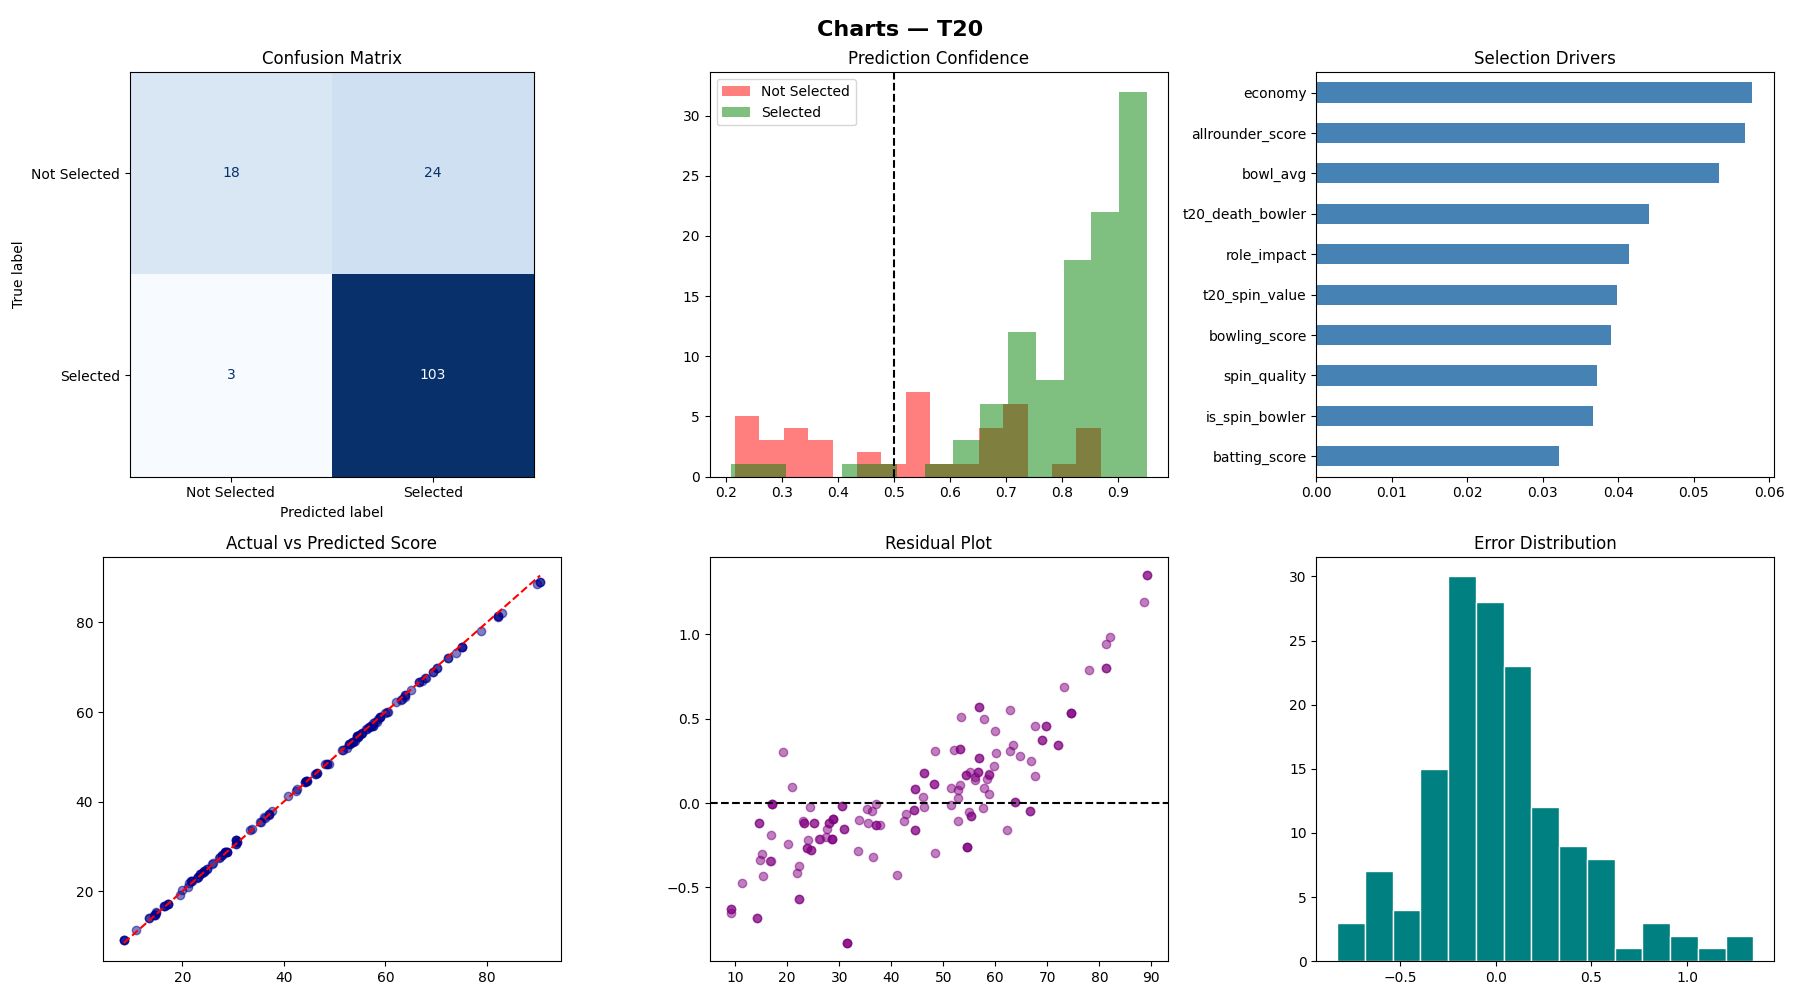


OPTIMIZING ODI
  Label balance: 71.35% selected (528 of 740)

ODI RESULTS
----------------------------------------
Training Accuracy : 0.8885
Testing  Accuracy : 0.8784
Gap               : 0.0101


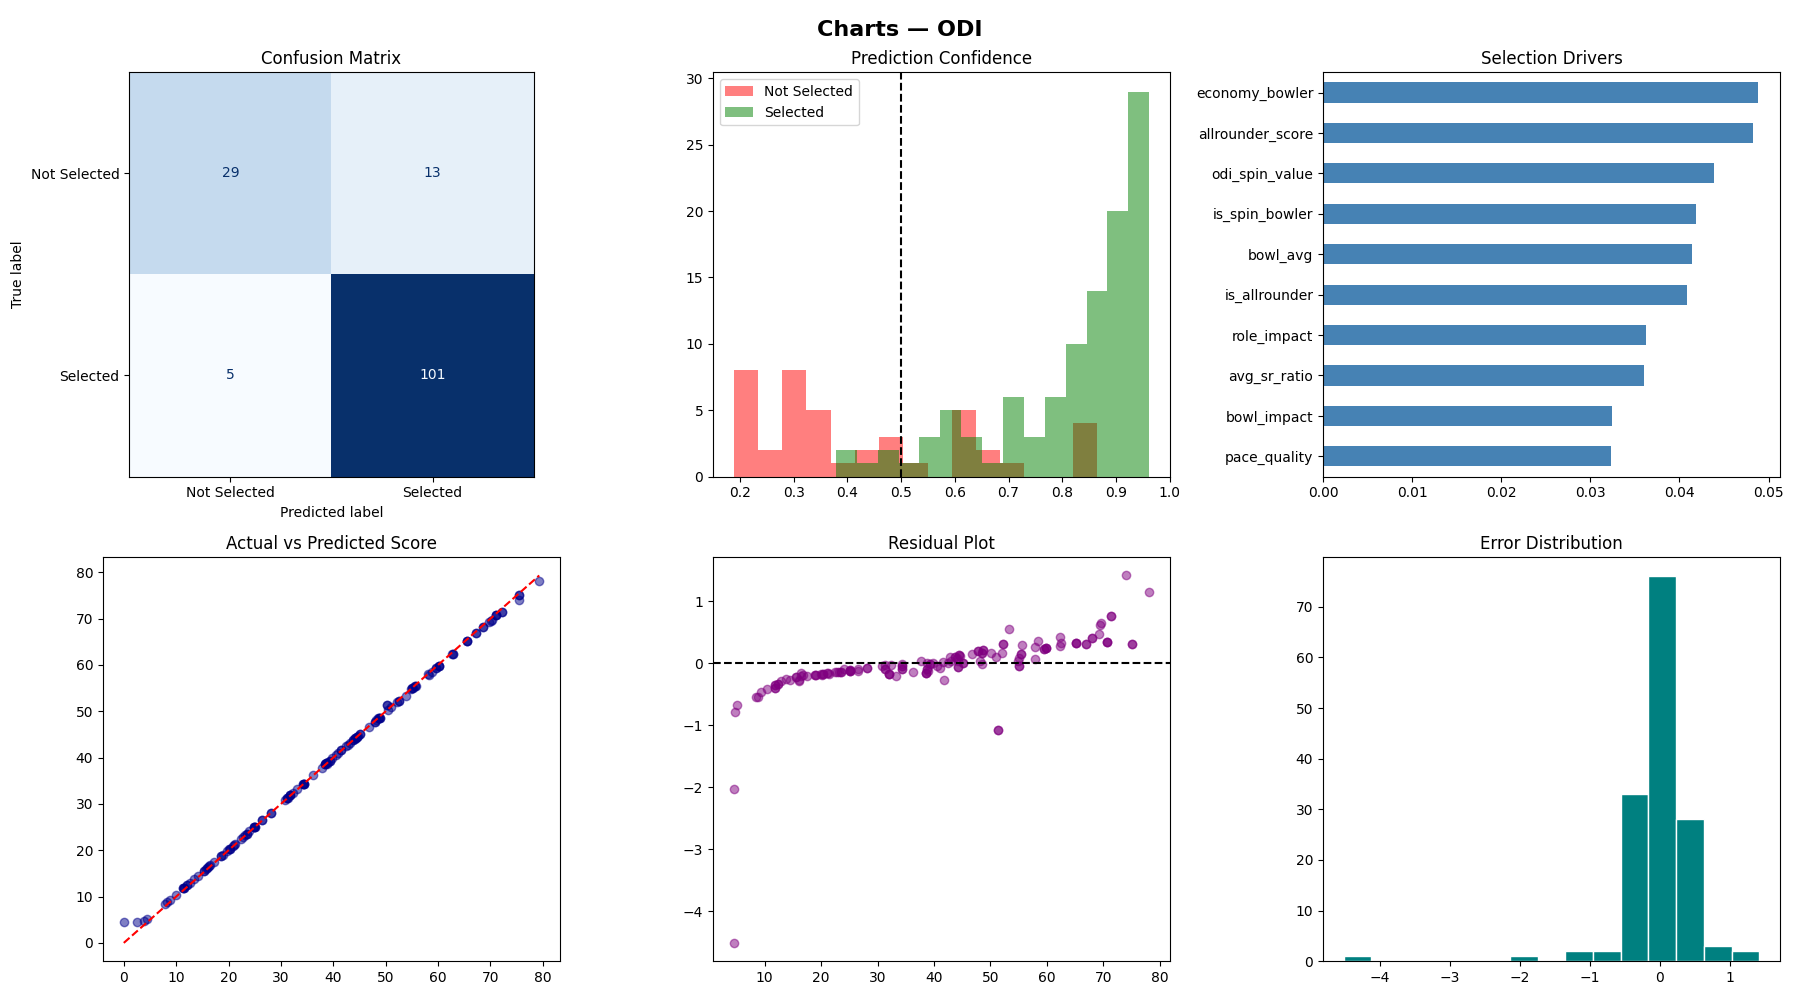


OPTIMIZING Test
  Label balance: 72.93% selected (528 of 724)

Test RESULTS
----------------------------------------
Training Accuracy : 0.8964
Testing  Accuracy : 0.8621
Gap               : 0.0343


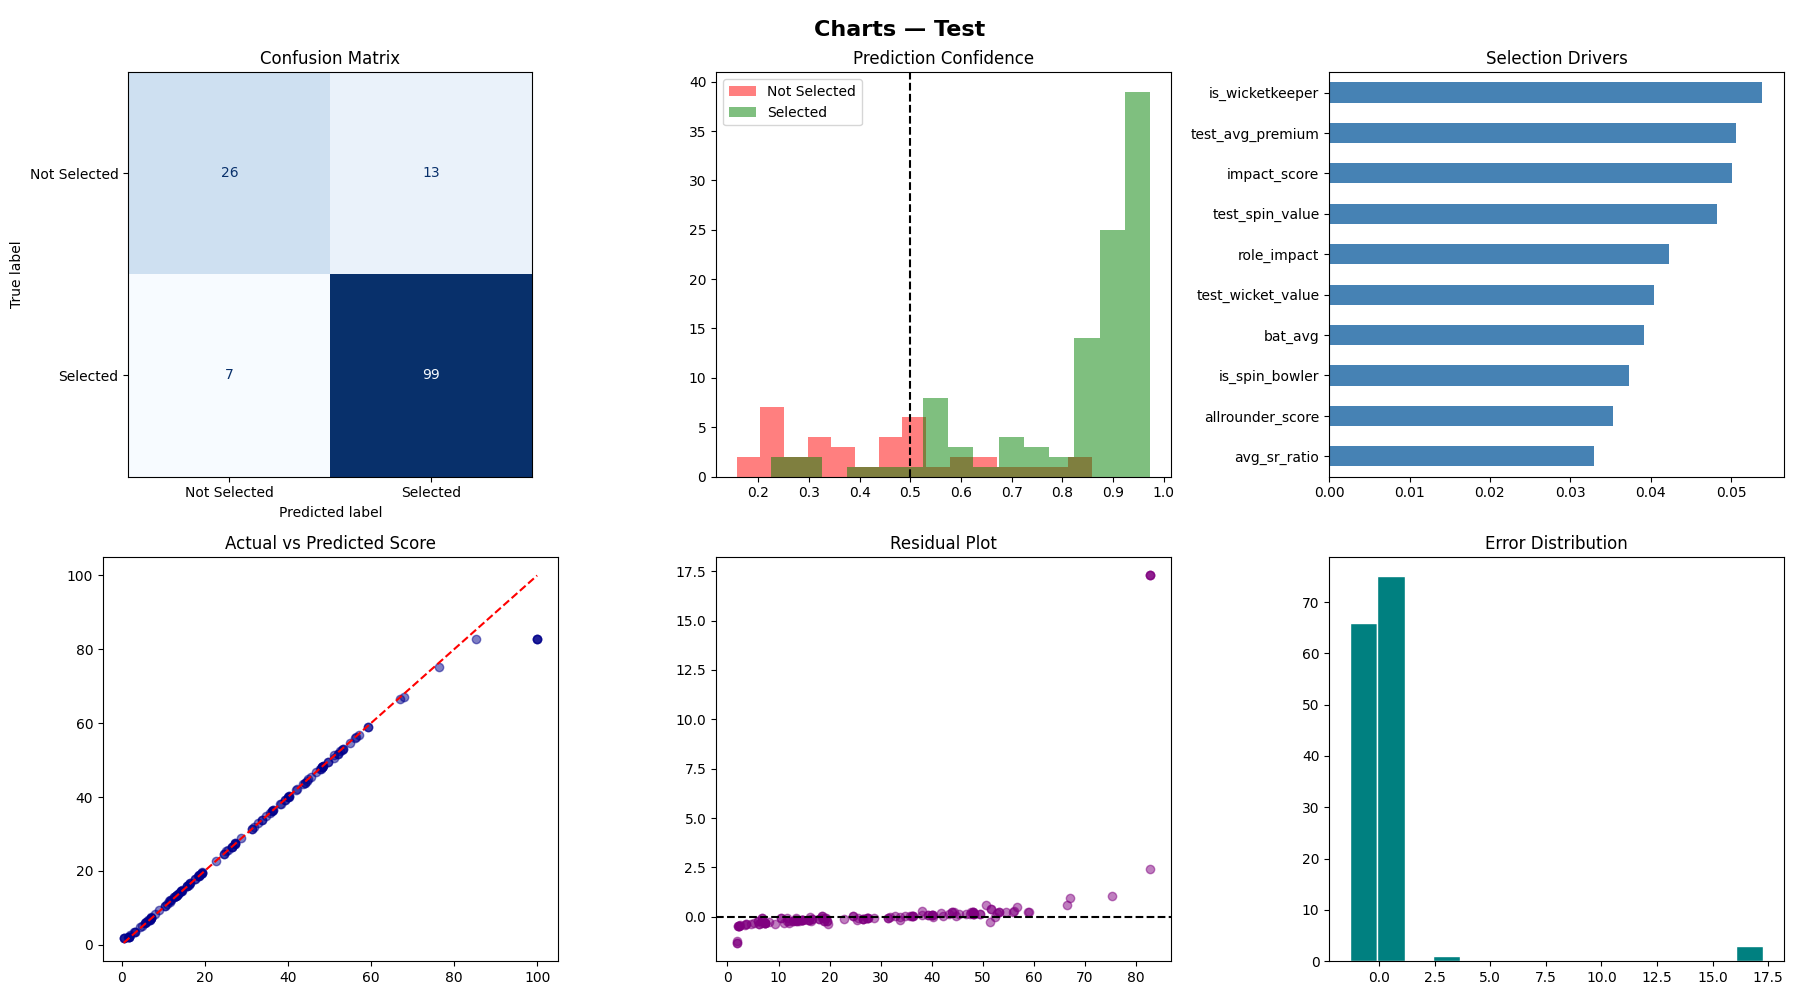


Models successfully optimized and charts generated!


In [10]:
# CELL 10 — LABELS + MODEL TRAINING
# ─────────────────────────────────────────────────────────────
 
def build_model_features(df, fmt):
    df = df.copy()
    df['bat_power']               = df['bat_avg'] * df['strike_rate']
    df['bowl_impact']             = df['wickets'] * (7 - df['economy'])
    df['consistency']             = (df['runs'] + 1) / (df['strike_rate'] + 1)
    df['experience_index']        = (df['runs'] * 0.4) + (df['wickets'] * 30)
    df['impact_score']            = (df['batting_score']    * 0.5 +
                                      df['bowling_score']    * 0.3 +
                                      df['allrounder_score'] * 0.2)
    df['overall_rating']          = df['bat_power'] + df['bowl_impact'] + df['impact_score']
    df['avg_sr_ratio']            = df['bat_avg'] / (df['strike_rate'] + 1)
    df['wicket_economy_ratio']    = (df['wickets'] + 1) / (df['economy'] + 1)
    df['role_impact']             = df['role_encoded'] * df['impact_score']
    df['batting_bowling_balance'] = (df['batting_score'] - df['bowling_score']).abs()
    df['spin_quality']            = df['is_spin_bowler'] * df['bowling_score']
    df['pace_quality']            = df['is_pace_bowler'] * df['bowling_score']
 
    if fmt == "T20":
        df['t20_sr_premium']       = np.where(df['strike_rate'] > 130,
                                              (df['strike_rate']-130)*df['bat_avg'], 0)
        df['t20_economy_bonus']    = np.where(df['economy'] < 7.5,
                                              (7.5-df['economy'])*df['wickets'], 0)
        df['t20_power_flag']       = df['power_hitter'] * df['high_striker']
        df['t20_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['t20_allrounder_value'] = df['is_allrounder'] * (df['batting_score']+df['bowling_score'])
        df['t20_boundary_proxy']   = df['strike_rate'] * df['power_hitter']
        df['t20_finisher_value']   = df['high_striker'] * df['bat_avg'] * df['is_allrounder']
        df['t20_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['t20_pace_value']       = df['pace_quality'] * df['wicket_taker']
 
    elif fmt == "ODI":
        df['odi_anchor_value']     = df['bat_avg'] * df['consistency']
        df['odi_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['odi_avg_premium']      = np.where(df['bat_avg'] > 35,
                                              (df['bat_avg']-35)*df['consistency'], 0)
        df['odi_sr_bonus']         = np.where(df['strike_rate'] > 85,
                                              (df['strike_rate']-85)*df['bat_avg'], 0)
        df['odi_economy_bonus']    = np.where(df['economy'] < 5.5,
                                              (5.5-df['economy'])*df['wickets'], 0)
        df['odi_experienced_bat']  = df['experienced_batter'] * df['bat_avg']
        df['odi_allrounder_val']   = df['is_allrounder'] * (df['batting_score']*0.6 +
                                                             df['bowling_score']*0.4)
        df['odi_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['odi_pace_value']       = df['pace_quality'] * df['wicket_taker']
 
    elif fmt == "Test":
        df['test_avg_premium']     = np.where(df['bat_avg'] > 40,
                                              (df['bat_avg']-40)*df['consistency'], 0)
        df['test_wicket_value']    = df['wickets'] * df['bowl_avg'].apply(
                                         lambda x: max(0, 35-x))
        df['test_elite_bat']       = np.where(df['bat_avg'] > 45,
                                              (df['bat_avg']-45)*df['runs'], 0)
        df['test_bowl_quality']    = np.where(df['bowl_avg'] < 30,
                                              (30-df['bowl_avg'])*df['wickets'], 0)
        df['test_run_accumulator'] = df['experienced_batter'] * df['runs']
        df['test_allrounder_val']  = df['is_allrounder'] * (df['batting_score']*0.5 +
                                                             df['bowling_score']*0.5)
        df['test_wicket_taker']    = df['wicket_taker'] * df['wickets']
        df['test_spin_value']      = df['spin_quality'] * (
                                         1 / (df['bowl_avg'].replace(0,99)+1))
        df['test_pace_value']      = df['pace_quality'] * (
                                         1 / (df['bowl_avg'].replace(0,99)+1))
    return df
 
 
def get_feature_list(df, fmt):
    base = [f for f in FEATURES if f in df.columns] + [
        'bat_power','bowl_impact','consistency','experience_index',
        'impact_score','overall_rating','avg_sr_ratio',
        'wicket_economy_ratio','role_impact','batting_bowling_balance',
        'spin_quality','pace_quality',
    ]
    extras = {
        "T20" : ['t20_sr_premium','t20_economy_bonus','t20_power_flag',
                 't20_death_bowler','t20_allrounder_value',
                 't20_boundary_proxy','t20_finisher_value',
                 't20_spin_value','t20_pace_value'],
        "ODI" : ['odi_anchor_value','odi_death_bowler','odi_avg_premium',
                 'odi_sr_bonus','odi_economy_bonus','odi_experienced_bat',
                 'odi_allrounder_val','odi_spin_value','odi_pace_value'],
        "Test": ['test_avg_premium','test_wicket_value','test_elite_bat',
                 'test_bowl_quality','test_run_accumulator',
                 'test_allrounder_val','test_wicket_taker',
                 'test_spin_value','test_pace_value'],
    }
    return [f for f in base + extras.get(fmt, []) if f in df.columns]
 
 
def create_labels_single(df, fmt, seed=42):
    """
    Creates is_in_probable_11 for one seed.
    Uses composite score + small random noise so each seed
    produces a slightly different valid XI per team.
    This gives more negative examples when stacked.
    """
    df = df.copy()
    df["is_in_probable_11"] = 0
 
    all_ar_roles = ["All-Rounder","Batting All-Rounder","Bowling All-Rounder"]
    bowler_roles = ["Bowler","Spin Bowler","Pace Bowler","Bowling All-Rounder"]
 
    STAT_WEIGHTS = {
        "T20" : {"runs": 0.10, "bat_avg": 0.20, "strike_rate": 0.35,
                 "wickets": 0.20, "economy": -0.15},
        "ODI" : {"runs": 0.15, "bat_avg": 0.30, "strike_rate": 0.20,
                 "wickets": 0.20, "economy": -0.15},
        "Test": {"runs": 0.20, "bat_avg": 0.40, "strike_rate": 0.05,
                 "wickets": 0.20, "economy": -0.15},
    }
    w = STAT_WEIGHTS.get(fmt, STAT_WEIGHTS["ODI"])
 
    stat_cols = ["runs","bat_avg","strike_rate","wickets","economy"]
    norm = {}
    for col in stat_cols:
        if col in df.columns:
            rng = df[col].max() - df[col].min()
            norm[col] = (df[col] - df[col].min()) / rng if rng > 0 \
                        else pd.Series(0.0, index=df.index)
        else:
            norm[col] = pd.Series(0.0, index=df.index)
    norm["economy"] = 1 - norm["economy"]
 
    df["_rank_score"] = (
        norm["runs"]        * abs(w["runs"])        +
        norm["bat_avg"]     * abs(w["bat_avg"])      +
        norm["strike_rate"] * abs(w["strike_rate"])  +
        norm["wickets"]     * abs(w["wickets"])      +
        norm["economy"]     * abs(w["economy"])
    )
    for col in ["batting_score","bowling_score","allrounder_score"]:
        if col not in df.columns:
            df[col] = 0.0
 
    # Add small reproducible noise so each seed picks slightly different XI
    rng_gen = np.random.default_rng(seed)
    noise   = rng_gen.uniform(-0.02, 0.02, size=len(df))
 
    df["_composite"] = (
        df["_rank_score"]            * 0.60 +
        (df["batting_score"]   / 100) * 0.20 +
        (df["bowling_score"]   / 100) * 0.12 +
        (df["allrounder_score"]/ 100) * 0.08 +
        noise
    )
 
    for team in df["team"].unique():
        tm  = df[df["team"] == team]
        sel = []
 
        def pick(roles, count):
            mask = tm["role"].isin(roles) & ~tm.index.isin(sel)
            return tm[mask].nlargest(count, "_composite").index.tolist()
 
        sel.extend(pick(["Wicketkeeper"], 1))
        sel.extend(pick(["Batter"], 3))
        sel.extend(pick(["Batting All-Rounder"], 1))
        sel.extend(pick(["All-Rounder","Batting All-Rounder",
                         "Bowling All-Rounder"], 1))
        sel.extend(pick(["Pace Bowler"], 2))
        sel.extend(pick(["Spin Bowler"], 2))
        sel.extend(pick(["Bowling All-Rounder"], 1))
        still_needed = 11 - len(sel)
        if still_needed > 0:
            sel.extend(pick(bowler_roles, still_needed))
        if len(sel) < 11:
            sel.extend(tm[~tm.index.isin(sel)]
                       .nlargest(11 - len(sel), "_composite").index.tolist())
 
        df.loc[sel[:11], "is_in_probable_11"] = 1
 
    df.drop(columns=["_rank_score","_composite"], inplace=True)
    return df
 
 
def create_labels(df, fmt, n_seeds=4):
    """
    Stacks n_seeds copies of the dataset, each labeled with a
    slightly different valid XI (via seed-controlled noise).
    This multiplies negative examples → balance drops to ~50-55%.
    The model sees more "fringe players not selected" examples.
    """
    if df.empty:
        return df
 
    seeds  = [42, 123, 256, 789][:n_seeds]
    frames = []
 
    for s in seeds:
        labeled = create_labels_single(df, fmt, seed=s)
        labeled["_seed"] = s
        frames.append(labeled)
 
    combined = pd.concat(frames, ignore_index=True)
 
    # Drop the seed helper column
    combined.drop(columns=["_seed"], inplace=True)
 
    label_counts = combined["is_in_probable_11"].value_counts().to_dict()
    pct = label_counts.get(1, 0) / len(combined) * 100
    print(f"  {fmt} labels → Selected: {label_counts.get(1,0)} | "
          f"Not selected: {label_counts.get(0,0)} | "
          f"Balance: {pct:.1f}% selected  "
          f"(total rows: {len(combined)})")
    return combined
 
 
def native_oversample(X, y, random_state=42):
    np.random.seed(random_state)
    y_np  = y.values
    idx_0 = np.where(y_np == 0)[0]
    idx_1 = np.where(y_np == 1)[0]
    if len(idx_1) < len(idx_0):
        extra_idx = np.random.choice(idx_1,
                                     size=len(idx_0)-len(idx_1),
                                     replace=True)
        new_idx = np.concatenate([np.arange(len(y_np)), extra_idx])
        return (X.iloc[new_idx].reset_index(drop=True),
                y.iloc[new_idx].reset_index(drop=True))
    return X, y
 
 
def plot_all_charts(clf, reg, y_test_c, y_pred_test, y_prob_test,
                    y_test_r, y_pred_r, fmt):
    plt.clf(); plt.close('all')
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Charts — {fmt}", fontsize=16, fontweight='bold')
 
    cm = confusion_matrix(y_test_c, y_pred_test)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Not Selected","Selected"]
                           ).plot(ax=axes[0,0], colorbar=False, cmap="Blues")
    axes[0,0].set_title("Confusion Matrix")
 
    axes[0,1].hist(y_prob_test[y_test_c==0], bins=15, alpha=0.5,
                   label="Not Selected", color="red")
    axes[0,1].hist(y_prob_test[y_test_c==1], bins=15, alpha=0.5,
                   label="Selected",     color="green")
    axes[0,1].axvline(0.5, color='black', linestyle='--')
    axes[0,1].set_title("Prediction Confidence")
    axes[0,1].legend()
 
    importances = clf.feature_importances_
    feat_names  = [f"F{i}" for i in range(len(importances))]
    try: feat_names = clf.get_booster().feature_names
    except: pass
    pd.Series(importances, index=feat_names).sort_values().tail(10).plot(
        kind='barh', ax=axes[0,2], color='steelblue')
    axes[0,2].set_title("Selection Drivers")
 
    axes[1,0].scatter(y_test_r, y_pred_r, alpha=0.5, color="darkblue")
    axes[1,0].plot([min(y_test_r), max(y_test_r)],
                   [min(y_test_r), max(y_test_r)], 'r--')
    axes[1,0].set_title("Actual vs Predicted Score")
 
    residuals = y_test_r - y_pred_r
    axes[1,1].scatter(y_pred_r, residuals, alpha=0.5, color="purple")
    axes[1,1].axhline(0, color='black', linestyle='--')
    axes[1,1].set_title("Residual Plot")
 
    axes[1,2].hist(residuals, bins=15, color="teal", edgecolor="white")
    axes[1,2].set_title("Error Distribution")
 
    plt.tight_layout()
    path = f"results_{fmt.lower()}.png"
    plt.savefig(path)
    display(Image(filename=path))
    plt.close(fig)
 
 
def train_all_models(master_df, fmt):
    print(f"\n{'='*60}\nOPTIMIZING {fmt}\n{'='*60}")
    cfg = FORMAT_CONFIGS[fmt]
    df  = build_model_features(master_df.copy(), fmt)
    EXTENDED_FEATURES = get_feature_list(df, fmt)
 
    X       = df[EXTENDED_FEATURES].fillna(0)
    y_class = df["is_in_probable_11"]
    y_reg   = df["batting_score"]
 
    pos_rate = y_class.mean()
    print(f"  Label balance: {pos_rate:.2%} selected "
          f"({y_class.sum()} of {len(y_class)})")
 
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y_class,
        test_size=cfg["test_size"],
        stratify=y_class,
        random_state=42)
 
    X_train_c, y_train_c = native_oversample(X_train_c, y_train_c)
 
    X_tr2, X_val, y_tr2, y_val = train_test_split(
        X_train_c, y_train_c,
        test_size=0.12,
        stratify=y_train_c,
        random_state=42)
 
    clf = xgb.XGBClassifier(
        n_estimators          = cfg["n_estimators"],
        max_depth             = cfg["max_depth"],
        learning_rate         = cfg["learning_rate"],
        subsample             = cfg["subsample"],
        colsample_bytree      = cfg["colsample_bytree"],
        min_child_weight      = cfg["min_child_weight"],
        gamma                 = cfg["gamma"],
        reg_alpha             = cfg["reg_alpha"],
        reg_lambda            = cfg["reg_lambda"],
        objective             = 'binary:logistic',
        random_state          = 42,
        eval_metric           = 'logloss',
        early_stopping_rounds = cfg["early_stopping"],
    )
    clf.fit(X_tr2, y_tr2,
            eval_set=[(X_val, y_val)],
            verbose=False)
 
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y_reg, test_size=0.20, random_state=42)
    reg = xgb.XGBRegressor(
        n_estimators     = 600,
        max_depth        = cfg["max_depth"],
        learning_rate    = cfg["learning_rate"],
        subsample        = cfg["subsample"],
        colsample_bytree = cfg["colsample_bytree"],
        reg_alpha        = cfg["reg_alpha"],
        reg_lambda       = cfg["reg_lambda"],
        random_state     = 42)
    reg.fit(X_train_r, y_train_r)
 
    y_train_prob = clf.predict_proba(X_train_c)[:,1]
    y_train_pred = (y_train_prob >= 0.50).astype(int)
    y_test_prob  = clf.predict_proba(X_test_c)[:,1]
    y_test_pred  = (y_test_prob >= 0.50).astype(int)
 
    train_acc = accuracy_score(y_train_c, y_train_pred)
    test_acc  = accuracy_score(y_test_c,  y_test_pred)
 
    print(f"\n{fmt} RESULTS\n{'-'*40}")
    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Testing  Accuracy : {test_acc:.4f}")
    print(f"Gap               : {abs(train_acc - test_acc):.4f}")
 
    plot_all_charts(clf, reg, y_test_c, y_test_pred, y_test_prob,
                    y_test_r, reg.predict(X_test_r), fmt)
    return clf, reg
 
 
# ── FEATURES ────────────────────────────────────────────────
FEATURES = [
    "runs","bat_avg","strike_rate",
    "wickets","bowl_avg","economy",
    "batting_score","bowling_score","allrounder_score",
    "role_encoded",
    "is_wicketkeeper","is_batter","is_bowler","is_allrounder",
    "is_spin_bowler","is_pace_bowler",
    "is_captain","high_striker","economy_bowler",
    "experienced_batter","wicket_taker","power_hitter",
    "elite_bowler","elite_striker","elite_batter","century_scorer",
]
 
# ── CONFIGS ──────────────────────────────────────────────────
FORMAT_CONFIGS = {
    "T20": {
        "n_estimators"    : 1200,
        "max_depth"       : 4,
        "learning_rate"   : 0.008,
        "subsample"       : 0.75,
        "colsample_bytree": 0.70,
        "min_child_weight": 5,
        "gamma"           : 2.0,
        "reg_alpha"       : 2.0,
        "reg_lambda"      : 6.0,
        "early_stopping"  : 80,
        "test_size"       : 0.20,
    },
    "ODI": {
        "n_estimators"    : 1200,
        "max_depth"       : 4,
        "learning_rate"   : 0.008,
        "subsample"       : 0.80,
        "colsample_bytree": 0.70,
        "min_child_weight": 5,
        "gamma"           : 1.5,
        "reg_alpha"       : 1.5,
        "reg_lambda"      : 5.0,
        "early_stopping"  : 80,
        "test_size"       : 0.20,
    },
    "Test": {
        "n_estimators"    : 1200,
        "max_depth"       : 4,
        "learning_rate"   : 0.008,
        "subsample"       : 0.80,
        "colsample_bytree": 0.70,
        "min_child_weight": 5,
        "gamma"           : 1.5,
        "reg_alpha"       : 1.5,
        "reg_lambda"      : 5.0,
        "early_stopping"  : 80,
        "test_size"       : 0.20,
    },
}
 
# ── EXECUTION ────────────────────────────────────────────────
print("Generating training labels...")
t20_master  = create_labels(t20_master,  "T20",  n_seeds=4)
odi_master  = create_labels(odi_master,  "ODI",  n_seeds=4)
test_master = create_labels(test_master, "Test", n_seeds=4)
print("Labels generated successfully!")
 
os.makedirs("../models", exist_ok=True)
trained_models = {}
 
for master, fmt in [
    (t20_master,  "T20"),
    (odi_master,  "ODI"),
    (test_master, "Test"),
]:
    c_m, r_m = train_all_models(master, fmt)
    if c_m and r_m:
        joblib.dump(c_m, f"../models/clf_{fmt.lower()}.pkl")
        joblib.dump(r_m, f"../models/reg_{fmt.lower()}.pkl")
        trained_models[fmt] = {"clf": c_m, "reg": r_m}
 
print("\nModels successfully optimized and charts generated!")

In [11]:
# CELL 11 — SHAP ANALYSIS
# ─────────────────────────────────────────────────────────────
import shap

# ── Define here so Cell 11 is self-contained ─────────────────
def build_model_features(df, fmt):
    df = df.copy()
    df['bat_power']               = df['bat_avg'] * df['strike_rate']
    df['bowl_impact']             = df['wickets'] * (7 - df['economy'])
    df['consistency']             = (df['runs'] + 1) / (df['strike_rate'] + 1)
    df['experience_index']        = (df['runs'] * 0.4) + (df['wickets'] * 30)
    df['impact_score']            = (df['batting_score']    * 0.5 +
                                      df['bowling_score']    * 0.3 +
                                      df['allrounder_score'] * 0.2)
    df['overall_rating']          = df['bat_power'] + df['bowl_impact'] + df['impact_score']
    df['avg_sr_ratio']            = df['bat_avg'] / (df['strike_rate'] + 1)
    df['wicket_economy_ratio']    = (df['wickets'] + 1) / (df['economy'] + 1)
    df['role_impact']             = df['role_encoded'] * df['impact_score']
    df['batting_bowling_balance'] = (df['batting_score'] - df['bowling_score']).abs()
    df['spin_quality']            = df['is_spin_bowler'] * df['bowling_score']
    df['pace_quality']            = df['is_pace_bowler'] * df['bowling_score']

    if fmt == "T20":
        df['t20_sr_premium']       = np.where(df['strike_rate'] > 130,
                                              (df['strike_rate']-130)*df['bat_avg'], 0)
        df['t20_economy_bonus']    = np.where(df['economy'] < 7.5,
                                              (7.5-df['economy'])*df['wickets'], 0)
        df['t20_power_flag']       = df['power_hitter'] * df['high_striker']
        df['t20_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['t20_allrounder_value'] = df['is_allrounder'] * (df['batting_score']+df['bowling_score'])
        df['t20_boundary_proxy']   = df['strike_rate'] * df['power_hitter']
        df['t20_finisher_value']   = df['high_striker'] * df['bat_avg'] * df['is_allrounder']
        df['t20_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['t20_pace_value']       = df['pace_quality'] * df['wicket_taker']

    elif fmt == "ODI":
        df['odi_anchor_value']     = df['bat_avg'] * df['consistency']
        df['odi_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['odi_avg_premium']      = np.where(df['bat_avg'] > 35,
                                              (df['bat_avg']-35)*df['consistency'], 0)
        df['odi_sr_bonus']         = np.where(df['strike_rate'] > 85,
                                              (df['strike_rate']-85)*df['bat_avg'], 0)
        df['odi_economy_bonus']    = np.where(df['economy'] < 5.5,
                                              (5.5-df['economy'])*df['wickets'], 0)
        df['odi_experienced_bat']  = df['experienced_batter'] * df['bat_avg']
        df['odi_allrounder_val']   = df['is_allrounder'] * (df['batting_score']*0.6+df['bowling_score']*0.4)
        df['odi_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['odi_pace_value']       = df['pace_quality'] * df['wicket_taker']

    elif fmt == "Test":
        df['test_avg_premium']     = np.where(df['bat_avg'] > 40,
                                              (df['bat_avg']-40)*df['consistency'], 0)
        df['test_wicket_value']    = df['wickets'] * df['bowl_avg'].apply(lambda x: max(0, 35-x))
        df['test_elite_bat']       = np.where(df['bat_avg'] > 45,
                                              (df['bat_avg']-45)*df['runs'], 0)
        df['test_bowl_quality']    = np.where(df['bowl_avg'] < 30,
                                              (30-df['bowl_avg'])*df['wickets'], 0)
        df['test_run_accumulator'] = df['experienced_batter'] * df['runs']
        df['test_allrounder_val']  = df['is_allrounder'] * (df['batting_score']*0.5+df['bowling_score']*0.5)
        df['test_wicket_taker']    = df['wicket_taker'] * df['wickets']
        df['test_spin_value']      = df['spin_quality'] * (1 / (df['bowl_avg'].replace(0,99)+1))
        df['test_pace_value']      = df['pace_quality'] * (1 / (df['bowl_avg'].replace(0,99)+1))
    return df


def get_feature_list(df, fmt):
    base = [f for f in FEATURES if f in df.columns] + [
        'bat_power','bowl_impact','consistency','experience_index',
        'impact_score','overall_rating','avg_sr_ratio',
        'wicket_economy_ratio','role_impact','batting_bowling_balance',
        'spin_quality','pace_quality',
    ]
    extras = {
        "T20" : ['t20_sr_premium','t20_economy_bonus','t20_power_flag',
                 't20_death_bowler','t20_allrounder_value',
                 't20_boundary_proxy','t20_finisher_value',
                 't20_spin_value','t20_pace_value'],
        "ODI" : ['odi_anchor_value','odi_death_bowler','odi_avg_premium',
                 'odi_sr_bonus','odi_economy_bonus','odi_experienced_bat',
                 'odi_allrounder_val','odi_spin_value','odi_pace_value'],
        "Test": ['test_avg_premium','test_wicket_value','test_elite_bat',
                 'test_bowl_quality','test_run_accumulator',
                 'test_allrounder_val','test_wicket_taker',
                 'test_spin_value','test_pace_value'],
    }
    return [f for f in base + extras.get(fmt, []) if f in df.columns]


def get_shap_features(master_df, fmt):
    df = build_model_features(master_df.copy(), fmt)
    feat_cols = get_feature_list(df, fmt)
    X = df[feat_cols].fillna(0)
    return X, feat_cols

def build_explainer(model):
    if model is None:
        print("  WARNING: Model is None, cannot build explainer.")
        return None
    return shap.TreeExplainer(model)

print("Loading models...")
try:
    model_clf_t20  = joblib.load("../models/clf_t20.pkl")
    model_clf_odi  = joblib.load("../models/clf_odi.pkl")
    model_clf_test = joblib.load("../models/clf_test.pkl")
    print("  All classifiers loaded.")
except Exception as e:
    print(f"  Load error: {e}")

SHAP_TARGETS = [
    ("T20",  locals().get("model_clf_t20"),  t20_master),
    ("ODI",  locals().get("model_clf_odi"),  odi_master),
    ("Test", locals().get("model_clf_test"), test_master),
]

os.makedirs("../models", exist_ok=True)
explainers = {}

for fmt, model, master_df in SHAP_TARGETS:
    print(f"\n{'='*55}\nSHAP ANALYSIS — {fmt}\n{'='*55}")
    if model is None:
        print(f"  Skipping {fmt}: model not loaded.")
        continue

    X_shap, feat_cols = get_shap_features(master_df, fmt)

    try:
        model_feat_names = model.get_booster().feature_names
        if model_feat_names is not None:
            missing = [f for f in model_feat_names if f not in X_shap.columns]
            for f in missing:
                X_shap[f] = 0.0
            X_shap = X_shap[model_feat_names]
            print(f"  Features aligned: {len(model_feat_names)} features")
    except Exception as e:
        print(f"  Feature alignment warning: {e}")

    print(f"  Input shape: {X_shap.shape}")
    explainer = build_explainer(model)
    if explainer is None:
        continue

    print(f"  Computing SHAP values...")
    try:
        shap_vals = explainer.shap_values(X_shap)
        sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
        print(f"  SHAP values shape: {sv.shape}")
    except Exception as e:
        print(f"  ERROR computing SHAP values: {e}")
        continue

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_shap, plot_type="dot", show=False, max_display=15)
    plt.title(f"SHAP Feature Impact — {fmt}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plot_path = f"../models/shap_summary_{fmt.lower()}.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"  Summary plot saved → {plot_path}")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_shap, plot_type="bar", show=False, max_display=15)
    plt.title(f"Mean |SHAP| — {fmt}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    bar_path = f"../models/shap_bar_{fmt.lower()}.png"
    plt.savefig(bar_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"  Bar plot saved → {bar_path}")

    mean_shap = np.abs(sv).mean(axis=0)
    feat_importance = (pd.DataFrame({"feature": X_shap.columns.tolist(),
                                     "mean_|shap|": mean_shap})
                       .sort_values("mean_|shap|", ascending=False)
                       .reset_index(drop=True))
    print(f"\n  Top 10 most impactful features ({fmt}):")
    print(feat_importance.head(10).to_string(index=False))

    try:
        explainer_path = f"../models/explainer_{fmt.lower()}.pkl"
        joblib.dump(explainer, explainer_path)
        explainers[fmt] = explainer
        print(f"\n  Explainer saved → {explainer_path}")
    except Exception as e:
        print(f"  Explainer save warning: {e}")

print("\nSHAP analysis complete!")

Loading models...
  All classifiers loaded.

SHAP ANALYSIS — T20
  Features aligned: 45 features
  Input shape: (740, 45)
  Computing SHAP values...
  SHAP values shape: (740, 45)
  Summary plot saved → ../models/shap_summary_t20.png
  Bar plot saved → ../models/shap_bar_t20.png

  Top 10 most impactful features (T20):
         feature  mean_|shap|
     role_impact     0.354755
allrounder_score     0.286738
     consistency     0.277630
         economy     0.224980
   batting_score     0.145215
        bowl_avg     0.129435
t20_death_bowler     0.083468
     strike_rate     0.074228
    role_encoded     0.071701
  is_spin_bowler     0.068538

  Explainer saved → ../models/explainer_t20.pkl

SHAP ANALYSIS — ODI
  Features aligned: 45 features
  Input shape: (740, 45)
  Computing SHAP values...
  SHAP values shape: (740, 45)
  Summary plot saved → ../models/shap_summary_odi.png
  Bar plot saved → ../models/shap_bar_odi.png

  Top 10 most impactful features (ODI):
                feature

In [12]:
# CELL 12  — MATCH PREVIEW  (T20 / ODI / TEST)
# Changes from previous version:
#   1. Lineup-anchored core: the 7 players who appeared in the
#      last XI vs this opponent are locked in first (if available
#      in master_df), remaining 4 slots filled dynamically.
#   2. Opponent-aware selection: bowler type quota shifts based
#      on the opponent's batting strengths (spin-heavy lineup →
#      more spinners; pace-heavy batting → more pace).
#   3. All helper functions (get_venue_profile, bowler_pitch_boost,
#      classify_conditions, build_model_features, get_feature_list)
#      are re-defined here so the cell is fully self-contained.
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np


# ── 1. BUILD MODEL FEATURES (self-contained copy) ────────────
def build_model_features(df, fmt):
    df = df.copy()
    df['bat_power']               = df['bat_avg'] * df['strike_rate']
    df['bowl_impact']             = df['wickets'] * (7 - df['economy'])
    df['consistency']             = (df['runs'] + 1) / (df['strike_rate'] + 1)
    df['experience_index']        = (df['runs'] * 0.4) + (df['wickets'] * 30)
    df['impact_score']            = (df['batting_score']    * 0.5 +
                                      df['bowling_score']    * 0.3 +
                                      df['allrounder_score'] * 0.2)
    df['overall_rating']          = df['bat_power'] + df['bowl_impact'] + df['impact_score']
    df['avg_sr_ratio']            = df['bat_avg'] / (df['strike_rate'] + 1)
    df['wicket_economy_ratio']    = (df['wickets'] + 1) / (df['economy'] + 1)
    df['role_impact']             = df['role_encoded'] * df['impact_score']
    df['batting_bowling_balance'] = (df['batting_score'] - df['bowling_score']).abs()
    df['spin_quality']            = df['is_spin_bowler'] * df['bowling_score']
    df['pace_quality']            = df['is_pace_bowler'] * df['bowling_score']

    if fmt == "T20":
        df['t20_sr_premium']       = np.where(df['strike_rate'] > 130,
                                              (df['strike_rate']-130)*df['bat_avg'], 0)
        df['t20_economy_bonus']    = np.where(df['economy'] < 7.5,
                                              (7.5-df['economy'])*df['wickets'], 0)
        df['t20_power_flag']       = df['power_hitter'] * df['high_striker']
        df['t20_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['t20_allrounder_value'] = df['is_allrounder'] * (df['batting_score']+df['bowling_score'])
        df['t20_boundary_proxy']   = df['strike_rate'] * df['power_hitter']
        df['t20_finisher_value']   = df['high_striker'] * df['bat_avg'] * df['is_allrounder']
        df['t20_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['t20_pace_value']       = df['pace_quality'] * df['wicket_taker']

    elif fmt == "ODI":
        df['odi_anchor_value']     = df['bat_avg'] * df['consistency']
        df['odi_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['odi_avg_premium']      = np.where(df['bat_avg'] > 35,
                                              (df['bat_avg']-35)*df['consistency'], 0)
        df['odi_sr_bonus']         = np.where(df['strike_rate'] > 85,
                                              (df['strike_rate']-85)*df['bat_avg'], 0)
        df['odi_economy_bonus']    = np.where(df['economy'] < 5.5,
                                              (5.5-df['economy'])*df['wickets'], 0)
        df['odi_experienced_bat']  = df['experienced_batter'] * df['bat_avg']
        df['odi_allrounder_val']   = df['is_allrounder'] * (df['batting_score']*0.6 +
                                                             df['bowling_score']*0.4)
        df['odi_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['odi_pace_value']       = df['pace_quality'] * df['wicket_taker']

    elif fmt == "Test":
        df['test_avg_premium']     = np.where(df['bat_avg'] > 40,
                                              (df['bat_avg']-40)*df['consistency'], 0)
        df['test_wicket_value']    = df['wickets'] * df['bowl_avg'].apply(
                                         lambda x: max(0, 35-x))
        df['test_elite_bat']       = np.where(df['bat_avg'] > 45,
                                              (df['bat_avg']-45)*df['runs'], 0)
        df['test_bowl_quality']    = np.where(df['bowl_avg'] < 30,
                                              (30-df['bowl_avg'])*df['wickets'], 0)
        df['test_run_accumulator'] = df['experienced_batter'] * df['runs']
        df['test_allrounder_val']  = df['is_allrounder'] * (df['batting_score']*0.5 +
                                                             df['bowling_score']*0.5)
        df['test_wicket_taker']    = df['wicket_taker'] * df['wickets']
        df['test_spin_value']      = df['spin_quality'] * (
                                         1 / (df['bowl_avg'].replace(0,99)+1))
        df['test_pace_value']      = df['pace_quality'] * (
                                         1 / (df['bowl_avg'].replace(0,99)+1))
    return df


# ── 2. GET FEATURE LIST (self-contained copy) ────────────────
def get_feature_list(df, fmt):
    base = [f for f in FEATURES if f in df.columns] + [
        'bat_power','bowl_impact','consistency','experience_index',
        'impact_score','overall_rating','avg_sr_ratio',
        'wicket_economy_ratio','role_impact','batting_bowling_balance',
        'spin_quality','pace_quality',
    ]
    extras = {
        "T20" : ['t20_sr_premium','t20_economy_bonus','t20_power_flag',
                 't20_death_bowler','t20_allrounder_value',
                 't20_boundary_proxy','t20_finisher_value',
                 't20_spin_value','t20_pace_value'],
        "ODI" : ['odi_anchor_value','odi_death_bowler','odi_avg_premium',
                 'odi_sr_bonus','odi_economy_bonus','odi_experienced_bat',
                 'odi_allrounder_val','odi_spin_value','odi_pace_value'],
        "Test": ['test_avg_premium','test_wicket_value','test_elite_bat',
                 'test_bowl_quality','test_run_accumulator',
                 'test_allrounder_val','test_wicket_taker',
                 'test_spin_value','test_pace_value'],
    }
    return [f for f in base + extras.get(fmt, []) if f in df.columns]


# ── 3. VENUE PROFILE ─────────────────────────────────────────
def get_venue_profile(venue_name, venues_df, allgrounds_df,
                      rpo_df, rpw_df, home_away_df, fmt):
    profile = {
        "country": "Unknown", "stadium": venue_name, "city": "Unknown",
        "pitch_type": "Balanced", "pitch_assist": "Unknown",
        "boundary": "Medium",    "scoring": "Medium",
        "weather": "Clear",      "rpo": 0.0, "rpw": 0.0,
        "matches_played": 0,
    }
    search         = venue_name.lower().strip()
    fmt_map        = {"ODI":"ODI","T20":"T20","TEST":"Test"}
    target_fmt_col = fmt_map.get(fmt.upper(), "ODI")

    def find_venue_row(df, term):
        if df is None or df.empty:
            return None
        search_cols = [c for c in df.columns
                       if c.lower() in ["ground_name","ground","city",
                                        "stadium","stadium name","stadium_name"]]
        if not search_cols:
            return None
        mask = df.apply(
            lambda row: any(term in str(row[c]).lower()
                            for c in search_cols), axis=1)
        matches = df[mask]
        return matches.iloc[0] if not matches.empty else None

    ag_row = find_venue_row(allgrounds_df, search)
    if ag_row is not None:
        profile["stadium"] = str(ag_row.get("Ground",
                               ag_row.get("ground_name", venue_name)))
        profile["city"]    = str(ag_row.get("City",    "Unknown"))
        profile["country"] = str(ag_row.get("Country", "Unknown"))
        if target_fmt_col in ag_row:
            try: profile["matches_played"] = int(ag_row[target_fmt_col])
            except: pass

    v_row = find_venue_row(venues_df, search)
    if v_row is not None:
        for key, candidates in [
            ("pitch_type",   ["pitch_type",   "Pitch Type"]),
            ("pitch_assist", ["pitch_assist", "Pitch Assistance", "Pitch Assist"]),
            ("scoring",      ["scoring",      "Scoring Nature", "Scoring"]),
            ("boundary",     ["boundary_dist","Boundary Dist.", "Boundary"]),
        ]:
            for cand in candidates:
                if cand in v_row.index and str(v_row[cand]) not in ["nan","None",""]:
                    profile[key] = str(v_row[cand])
                    break

    for df_g, key in [(rpo_df,"rpo"), (rpw_df,"rpw")]:
        row = find_venue_row(df_g, search)
        if row is not None:
            col_to_use = key if key in row.index else row.index[-1]
            try: profile[key] = float(row[col_to_use])
            except: pass

    return profile


# ── 4. BOWLER PITCH BOOST ────────────────────────────────────
def bowler_pitch_boost(role, pitch_assist):
    pa       = str(pitch_assist).lower()
    spin_kw  = ["spin","turn","dust","rough","dry"]
    pace_kw  = ["pace","seam","swing","bounce","fast","green","extreme"]
    is_spin  = any(k in pa for k in spin_kw)
    is_pace  = any(k in pa for k in pace_kw)

    if role == "Spin Bowler":
        if is_spin: return 1.30
        if is_pace: return 0.75
    if role == "Pace Bowler":
        if is_pace: return 1.30
        if is_spin: return 0.75
    if role in ["Bowler","Bowling All-Rounder"]:
        if is_spin or is_pace: return 1.10
    return 1.0


# ── 5. CONDITION CLASSIFIER ──────────────────────────────────
def classify_conditions(venue, fmt):
    scoring      = str(venue.get("scoring",      "medium")).lower()
    pitch_assist = str(venue.get("pitch_assist", "unknown")).lower()
    rpo          = venue.get("rpo", 0.0)
    thresholds   = {"T20": 8.5, "ODI": 5.25, "TEST": 2.75}
    thr          = thresholds.get(fmt.upper(), 5.25)

    is_high = ("high" in scoring or "ultra" in scoring or rpo > thr)
    is_low  = ("low" in scoring and "high" not in scoring) or \
              (0 < rpo < thr * 0.85)
    spin_kw = ["spin","turn","dust","rough","dry","slow"]
    pace_kw = ["pace","seam","swing","bounce","fast","green","extreme"]
    is_spin = any(k in pitch_assist for k in spin_kw)
    is_pace = any(k in pitch_assist for k in pace_kw)

    return is_high, is_low, is_spin, is_pace


# ── 6. OPPONENT PROFILE ──────────────────────────────────────
def get_opponent_profile(opponent_name, master_df, fmt):
    """
    Analyses the opponent's batting lineup to decide whether
    to field more spin or pace bowlers against them.

    Returns a dict:
        opp_spin_vulnerable  : True if opponent has many low-avg batters vs spin
        opp_pace_vulnerable  : True if opponent has many low-avg batters vs pace
        opp_batting_strength : "strong" | "average" | "weak"
        opp_avg_bat_avg      : float — mean batting average of their top 6
    """
    opp_df = master_df[master_df["team"] == opponent_name].copy()

    profile = {
        "opp_spin_vulnerable" : False,
        "opp_pace_vulnerable" : False,
        "opp_batting_strength": "average",
        "opp_avg_bat_avg"     : 25.0,
    }

    if opp_df.empty:
        return profile

    # Take top 6 batters by bat_avg as the representative batting unit
    batting_roles = ["Batter","Wicketkeeper","Batting All-Rounder","All-Rounder"]
    top_batters   = (opp_df[opp_df["role"].isin(batting_roles)]
                     .nlargest(6, "bat_avg"))

    if top_batters.empty:
        return profile

    avg_bat_avg = top_batters["bat_avg"].mean()
    profile["opp_avg_bat_avg"] = round(avg_bat_avg, 2)

    # Batting strength thresholds differ by format
    strong_thr = {"T20": 28, "ODI": 35, "TEST": 42}.get(fmt, 32)
    weak_thr   = {"T20": 18, "ODI": 25, "TEST": 30}.get(fmt, 22)

    if avg_bat_avg >= strong_thr:
        profile["opp_batting_strength"] = "strong"
    elif avg_bat_avg <= weak_thr:
        profile["opp_batting_strength"] = "weak"
    else:
        profile["opp_batting_strength"] = "average"

    # Spin vulnerability: many batters with low strike_rate
    # (batters who struggle to accelerate are often spin-vulnerable)
    low_sr_count = (top_batters["strike_rate"] < 110).sum() if fmt == "T20" \
                   else (top_batters["strike_rate"] < 65).sum()
    profile["opp_spin_vulnerable"] = (low_sr_count >= 3)

    # Pace vulnerability: many batters with very low bat_avg
    # combined with high strike_rate (aggressive but inconsistent)
    low_avg_high_sr = (
        (top_batters["bat_avg"] < weak_thr) &
        (top_batters["strike_rate"] > 120 if fmt == "T20"
         else top_batters["strike_rate"] > 75)
    ).sum()
    profile["opp_pace_vulnerable"] = (low_avg_high_sr >= 2)

    return profile


# ── 7. ANCHOR CORE FROM LAST LINEUP ──────────────────────────
def get_lineup_anchors(team_name, opponent_name, lineup_dict,
                       team_df, min_anchor=7):
    """
    Returns index list of players from the last XI vs this opponent
    that also exist in master_df (team_df).
    Caps at min_anchor (default 7) so 4 slots stay dynamic.
    """
    if not lineup_dict or team_name not in lineup_dict:
        return []

    opp_lineups = lineup_dict[team_name]
    matched_key = next(
        (k for k in opp_lineups
         if opponent_name.lower() in k.lower() or
            k.lower() in opponent_name.lower()), None)

    if not matched_key:
        return []

    last_xi_names = [str(p).lower().strip()
                     for p in opp_lineups[matched_key] if str(p).strip()]

    if "player_name" not in team_df.columns:
        return []

    anchor_indices = []
    for idx, row in team_df.iterrows():
        p_name = str(row["player_name"]).lower().strip()
        # fuzzy match: check if any last-xi name contains or is contained by p_name
        if any(p_name in ln or ln in p_name for ln in last_xi_names):
            anchor_indices.append(idx)
        if len(anchor_indices) >= min_anchor:
            break

    return anchor_indices


# ── 8. PROBABLE XI (opponent-aware + lineup-anchored) ────────
def get_probable_11(team_name, opponent_name, master_df,
                    clf_model, reg_model, fmt, venue,
                    lineup_dict=None, **kwargs):

    team_df = master_df[master_df["team"] == team_name].copy()
    if team_df.empty:
        print(f"  WARNING: No players found for team '{team_name}'")
        return []

    # ── CRITICAL: deduplicate players before prediction ───
    # multi-seed label stacking creates duplicate rows with same
    # player_name — keep only the row with the highest batting_score
    # so each player appears exactly once
    if "player_name" in team_df.columns:
        team_df = (team_df
                   .sort_values("batting_score", ascending=False)
                   .drop_duplicates(subset=["player_name"], keep="first")
                   .reset_index(drop=True))
    elif "name_key" in team_df.columns:
        team_df = (team_df
                   .drop_duplicates(subset=["name_key"], keep="first")
                   .reset_index(drop=True))

    team_df   = build_model_features(team_df, fmt)
    feat_cols = get_feature_list(team_df, fmt)

    # ── Model predictions ─────────────────────────────────
    try:
        model_feat_names = clf_model.get_booster().feature_names
        if model_feat_names:
            for f in model_feat_names:
                if f not in team_df.columns:
                    team_df[f] = 0.0
            X = team_df[model_feat_names].fillna(0)
        else:
            X = team_df[feat_cols].fillna(0)
    except Exception as e:
        print(f"  Feature alignment fallback: {e}")
        X = team_df[feat_cols].fillna(0)

    team_df["probability"] = clf_model.predict_proba(X)[:, 1]

    # ── Conditions ────────────────────────────────────────
    is_high, is_low, is_spin, is_pace = classify_conditions(venue, fmt)
    pitch_assist = venue.get("pitch_assist", "Unknown")

    # ── Opponent profile (changes bowler quota) ───────────
    opp_profile = get_opponent_profile(opponent_name, master_df, fmt)
    opp_spin_v  = opp_profile["opp_spin_vulnerable"]
    opp_pace_v  = opp_profile["opp_pace_vulnerable"]
    opp_str     = opp_profile["opp_batting_strength"]

    # ── Per-player boosts ─────────────────────────────────
    for idx, row in team_df.iterrows():
        boost = bowler_pitch_boost(row["role"], pitch_assist)

        # Extra boost if bowler type exploits opponent weakness
        if row["role"] == "Spin Bowler" and opp_spin_v:
            boost *= 1.10
        if row["role"] == "Pace Bowler" and opp_pace_v:
            boost *= 1.10

        team_df.at[idx, "probability"] *= boost

    if is_high:
        mask = team_df["role"].isin(["Batter","Batting All-Rounder","Wicketkeeper"])
        team_df.loc[mask, "probability"] *= 1.10

    # If opponent batting is weak, boost bowlers slightly more
    if opp_str == "weak":
        mask = team_df["role"].isin(["Bowler","Spin Bowler","Pace Bowler",
                                     "Bowling All-Rounder"])
        team_df.loc[mask, "probability"] *= 1.08

    team_df["probability"] = team_df["probability"].clip(0, 0.99)

    # ── Step 1: Lock in lineup anchors (≤7 players) ───────
    anchor_indices = get_lineup_anchors(
        team_name, opponent_name, lineup_dict, team_df, min_anchor=7)
    selected = list(anchor_indices)  # start with anchored players

    # ── Helper: pick from remaining pool ─────────────────
    def pick(roles, count):
        nonlocal selected
        if count <= 0:
            return
        mask  = team_df["role"].isin(roles) & ~team_df.index.isin(selected)
        picks = team_df[mask].nlargest(count, "probability").index.tolist()
        selected.extend(picks)

    # ── Step 2: Determine bowler quota based on conditions
    #            AND opponent profile ─────────────────────
    # Base quota
    if is_spin and not is_pace:
        n_spin, n_pace = 3, 1
    elif is_pace and not is_spin:
        n_spin, n_pace = 1, 3
    elif is_spin and is_pace:
        n_spin, n_pace = 2, 2
    else:
        n_spin, n_pace = 2, 2

    # Opponent adjustment: shift one bowler slot toward exploitable type
    if opp_spin_v and not (is_pace and not is_spin):
        n_spin = min(n_spin + 1, 4)
        n_pace = max(n_pace - 1, 0)
    elif opp_pace_v and not (is_spin and not is_pace):
        n_pace = min(n_pace + 1, 4)
        n_spin = max(n_spin - 1, 0)

    # ── Step 3: Fill remaining 4 dynamic slots ────────────
    # Count roles already covered by anchors
    anchored_roles = team_df.loc[anchor_indices, "role"].tolist() \
                    if anchor_indices else []

    def anchored_count(roles):
        return sum(1 for r in anchored_roles if r in roles)

    slots_left = 11 - len(selected)

    # How many of each role do we still need?
    # How many of each role do we still need?
    need_wk   = max(0, 1 - anchored_count(["Wicketkeeper"]))
    need_bat  = max(0, 3 - anchored_count(["Batter"]))
    need_ar   = max(0, 2 - anchored_count(["All-Rounder","Batting All-Rounder",
                                            "Bowling All-Rounder"]))

    # ── Enforce minimum 3 pure bowlers (Spin + Pace) ──────
    # Count pure bowlers already in anchors
    anchored_spin = anchored_count(["Spin Bowler"])
    anchored_pace = anchored_count(["Pace Bowler","Bowler"])
    anchored_pure_bowlers = anchored_spin + anchored_pace

    # We want at least 3 pure bowlers total (spin + pace combined)
    # distribute between spin and pace based on n_spin / n_pace quota
    # but guarantee the sum is at least 3
    total_bowlers_needed = max(n_spin + n_pace, 3)

    # Redistribute if needed to hit minimum 3
    if n_spin + n_pace < 3:
        # Add extra to whichever type is dominant for conditions
        if n_spin >= n_pace:
            n_spin = 2
            n_pace = 1
        else:
            n_spin = 1
            n_pace = 2

    need_spin = max(0, n_spin - anchored_spin)
    need_pace = max(0, n_pace - anchored_pace)

    # Extra safety: if anchors already have 3+ pure bowlers, keep quotas as-is
    # If anchors have fewer than 3, make sure we fill up to 3 minimum
    if anchored_pure_bowlers < 3:
        shortfall = 3 - anchored_pure_bowlers - need_spin - need_pace
        if shortfall > 0:
            # Fill shortfall from whichever type has quota remaining
            if is_spin or n_spin >= n_pace:
                need_spin += shortfall
            else:
                need_pace += shortfall

    # Fill in priority order
    pick(["Wicketkeeper"], need_wk)
    pick(["Batter"], need_bat)
    pick(["Batting All-Rounder","All-Rounder","Bowling All-Rounder"], need_ar)
    pick(["Spin Bowler"], need_spin)
    pick(["Pace Bowler","Bowler"], need_pace)

    # ── Hard guarantee: if still fewer than 3 pure bowlers, top up ──
    current_pure_bowlers = sum(
        1 for i in selected
        if team_df.loc[i, "role"] in ["Spin Bowler","Pace Bowler","Bowler"]
    )
    if current_pure_bowlers < 3:
        extra_needed = 3 - current_pure_bowlers
        if is_spin or n_spin >= n_pace:
            pick(["Spin Bowler","Pace Bowler","Bowler"], extra_needed)
        else:
            pick(["Pace Bowler","Bowler","Spin Bowler"], extra_needed)

    # ── Dynamic 11th slot (if still < 11) ─────────────────
    if len(selected) < 11:
        if is_high:
            pick(["Batter","Wicketkeeper","Batting All-Rounder"], 1)
        elif is_low:
            if is_spin:
                pick(["Spin Bowler","Bowling All-Rounder"], 1)
            elif is_pace:
                pick(["Pace Bowler","Bowler"], 1)
            else:
                pick(["Spin Bowler","Pace Bowler","Bowler",
                      "Bowling All-Rounder"], 1)
        elif is_spin or opp_spin_v:
            pick(["Spin Bowler","Bowling All-Rounder"], 1)
        elif is_pace or opp_pace_v:
            pick(["Pace Bowler","Bowler"], 1)
        else:
            pick(["All-Rounder","Batting All-Rounder",
                  "Bowling All-Rounder"], 1)

    # ── Safety catch ──────────────────────────────────────
    if len(selected) < 11:
        backups = (team_df[~team_df.index.isin(selected)]
                   .nlargest(11 - len(selected), "probability").index.tolist())
        selected.extend(backups)

    # Dedup preserving insertion order
    seen_set = set()
    selected = [i for i in selected if not (i in seen_set or seen_set.add(i))]

    final_xi = team_df.loc[selected[:11]].copy()

    # ── Reasoning ─────────────────────────────────────────
    stadium = venue.get("stadium", "this venue")

    def generate_reason(row):
        role  = row["role"]
        p_val = row["probability"] * 100
        is_anchor = row.name in anchor_indices

        if is_anchor:
            base = f"Retained from last XI vs {opponent_name} — proven performer."
        elif "Spin" in role and is_spin:
            base = f"Spin specialist chosen to exploit the turning surface at {stadium}."
        elif "Spin" in role and opp_spin_v:
            base = f"Selected to target {opponent_name}'s vulnerability against spin."
        elif "Pace" in role and is_pace:
            base = (f"Pace bowler drafted for the {pitch_assist} "
                    f"conditions at {stadium}.")
        elif "Pace" in role and opp_pace_v:
            base = f"Selected to exploit {opponent_name}'s weakness against pace."
        elif is_high and role in ["Batter","Batting All-Rounder","Wicketkeeper"]:
            base = (f"Selected as a batting asset for the "
                    f"high-scoring environment at {stadium}.")
        elif is_low and role in ["Bowler","Spin Bowler","Pace Bowler",
                                 "Bowling All-Rounder"]:
            base = ("Bowling specialist included for the "
                    "low-scoring, bowler-friendly conditions.")
        elif "Wicketkeeper" in role:
            base = "Reliable gloveman anchoring the middle order."
        else:
            pa_desc = pitch_assist if pitch_assist != "Unknown" else "current conditions"
            base = (f"Tactical inclusion as a {role} "
                    f"suited for {pa_desc}.")

        if   p_val >= 85: conf = f"Elite {p_val:.2f}% confidence — undisputed starter."
        elif p_val >= 70: conf = f"Solid {p_val:.2f}% rating — tactical lock."
        else:             conf = f"Situational pick at {p_val:.2f}%."
        return f"{base} {conf}"

    final_xi["reason"] = final_xi.apply(generate_reason, axis=1)

    if "player_name" in final_xi.columns:
        final_xi["player"] = final_xi["player_name"]

    final_xi["probability"] = (final_xi["probability"] * 100).round(2)
# ── Batting order from lineup ─────────────────────────
    # Build a position map from the last XI vs this opponent
    batting_order_map = {}
    if lineup_dict and team_name in lineup_dict:
        opp_lineups = lineup_dict[team_name]
        matched_key = next(
            (k for k in opp_lineups
             if opponent_name.lower() in k.lower() or
                k.lower() in opponent_name.lower()), None)
        if matched_key:
            for position, p_name in enumerate(opp_lineups[matched_key], 1):
                batting_order_map[str(p_name).lower().strip()] = position
    def get_batting_position(player_name):
        """Return lineup position if found, else 99 (goes to bottom)."""
        p = str(player_name).lower().strip()
        for ln, pos in batting_order_map.items():
            if p in ln or ln in p:
                return pos
        return 99
    # Assign batting position to every player
# ── Batting order from lineup (WK + Batter only) ──────
    # WK and Batter  → sorted by lineup position
    # Batting AR     → after WK/Batter, sorted by probability desc
    # All-Rounder    → after Batting AR, sorted by probability desc
    # Bowling AR     → after All-Rounder, sorted by probability desc
    # Spin/Pace/Bowler → always last, sorted by probability desc
# ── Batting order from lineup ─────────────────────────
   # ── Sort by batting order (WK+Batter only) then role priority ──
    role_group = {
        "Wicketkeeper"       : 1,
        "Batter"             : 1,
        "Batting All-Rounder": 2,
        "All-Rounder"        : 3,
        "Bowling All-Rounder": 4,
        "Spin Bowler"        : 5,
        "Pace Bowler"        : 5,
        "Bowler"             : 5,
    }

    final_xi["_rg"]  = final_xi["role"].map(role_group).fillna(5)
    final_xi["_bp"]  = final_xi["player"].apply(get_batting_position)

    # Group 1 (WK + Batter):
    #   - in lineup → use batting_pos (1,2,3...)
    #   - not in lineup (pos=99) → appear after lineup batters, sorted by prob desc
    # Groups 2-5: sorted by probability desc within each group
    final_xi["_sk"] = final_xi.apply(
        lambda r: r["_bp"]                    # lineup order for WK/Batter in lineup
                  if (r["_rg"] == 1 and r["_bp"] != 99)
                  else (
                      50 + (100 - r["probability"])   # WK/Batter not in lineup → after lineup batters
                      if r["_rg"] == 1
                      else (100 - r["probability"])   # all other roles → prob desc
                  ),
        axis=1
    )

    final_xi = final_xi.sort_values(
        ["_rg", "_sk"], ascending=[True, True]
    ).drop(columns=["_rg", "_bp", "_sk", "batting_pos"],
           errors="ignore")
    # ── Lineup validation ─────────────────────────────────
    if lineup_dict and team_name in lineup_dict:
        opp_lineups = lineup_dict[team_name]
        matched_key = next(
            (k for k in opp_lineups
             if opponent_name.lower() in k.lower() or
                k.lower() in opponent_name.lower()), None)
        if matched_key:
            last_xi   = [p.lower().strip() for p in opp_lineups[matched_key]]
            predicted = [str(p.get("player","")).lower().strip()
                         for p in final_xi.to_dict("records")]
            overlap   = sum(1 for p in predicted
                            if any(p in lp or lp in p for lp in last_xi))
            print(f"\n  Lineup Validation ({team_name} vs {opponent_name}):")
            print(f"    Last XI matches in predicted XI : {overlap}/11")
            print(f"    Anchors locked from last XI     : {len(anchor_indices)}")
            if overlap < 7:
                print(f"    ⚠  Only {overlap} matches — check squad/lineup data.")
            else:
                print(f"    ✓  PASSED ({overlap}/11 ≥ 7)")
        else:
            print(f"  No previous lineup found for {team_name} vs {opponent_name}")

    return final_xi.to_dict("records")


# ── 9. MATCH PREVIEW PRINTER ─────────────────────────────────
def match_preview_and_xi(team1, team2, venue_name, fmt,
                         master_df, clf_model, reg_model,
                         explainer, venues_df, allgrounds_df,
                         rpo_df, rpw_df, home_away_df,
                         lineup_dict=None):

    fmt_clean = fmt.strip().upper()

    venue = get_venue_profile(
        venue_name, venues_df, allgrounds_df,
        rpo_df, rpw_df, home_away_df, fmt_clean)

    is_high, is_low, is_spin, is_pace = classify_conditions(venue, fmt_clean)

    # Opponent profiles (for display)
    opp1 = get_opponent_profile(team2, master_df, fmt_clean)
    opp2 = get_opponent_profile(team1, master_df, fmt_clean)

    t1_xi = get_probable_11(team1, team2, master_df,
                            clf_model, reg_model, fmt_clean, venue,
                            lineup_dict=lineup_dict)
    t2_xi = get_probable_11(team2, team1, master_df,
                            clf_model, reg_model, fmt_clean, venue,
                            lineup_dict=lineup_dict)

    if not t1_xi:
        print(f"  ERROR: No XI for '{team1}'"); return
    if not t2_xi:
        print(f"  ERROR: No XI for '{team2}'"); return

    def generate_analysis(xi):
        bowler_roles = ["Bowler","Spin Bowler","Pace Bowler","Bowling All-Rounder"]
        batters  = [p for p in xi if p["role"] in
                    ["Batter","Wicketkeeper","Batting All-Rounder"]]
        bowlers  = [p for p in xi if p["role"] in bowler_roles]
        ars      = [p for p in xi if "All-Rounder" in p["role"]]
        spinners = [p for p in xi if p["role"] == "Spin Bowler"]
        pacers   = [p for p in xi if p["role"] == "Pace Bowler"]

        top_player = sorted(xi, key=lambda x: x["probability"],
                            reverse=True)[0]["player"]
        top_bowler = (sorted(bowlers, key=lambda x: x.get("wickets",0),
                             reverse=True)[0]["player"] if bowlers else "N/A")

        strengths, concerns = [], []
        if len(batters) >= 6:   strengths.append("strong batting lineup")
        if len(ars) >= 3:       strengths.append(
                                    f"excellent all-round depth ({len(ars)} all-rounders)")
        elif len(ars) >= 2:     strengths.append(
                                    f"good all-round cover ({len(ars)} all-rounders)")
        if len(spinners) >= 2:  strengths.append(f"{len(spinners)} spin bowling options")
        if len(pacers)   >= 2:  strengths.append(f"{len(pacers)} pace bowling options")
        if len(bowlers)  < 4:   concerns.append("limited specialist bowling options")

        return {
            "keeper"    : next((p["player"] for p in xi
                                if p["role"] == "Wicketkeeper"), "N/A"),
            "key_batter": sorted(batters, key=lambda x: x.get("bat_avg",0),
                                 reverse=True)[0]["player"] if batters else "N/A",
            "threat"    : top_bowler,
            "ar_main"   : ars[0]["player"] if ars else "N/A",
            "ar_count"  : len(ars),
            "spinners"  : len(spinners),
            "pacers"    : len(pacers),
            "strengths" : strengths,
            "concerns"  : concerns,
            "watch"     : top_player,
        }

    a1, a2 = generate_analysis(t1_xi), generate_analysis(t2_xi)
    rpo    = venue.get("rpo", 0.0)

    pitch_summary = []
    if is_spin:  pitch_summary.append("Spin-friendly")
    if is_pace:  pitch_summary.append("Pace-friendly")
    if is_high:  pitch_summary.append("High-scoring / Batting paradise")
    elif is_low: pitch_summary.append("Low-scoring / Bowling paradise")
    if not pitch_summary: pitch_summary.append("Balanced")
    impact_label = " | ".join(pitch_summary)

    print(f"\n{'='*65}")
    print(f"  MATCH  : {team1.upper()} vs {team2.upper()}")
    print(f"  FORMAT : {fmt_clean}    VENUE : {venue_name}")
    print(f"{'='*65}")

    for t_name, xi in [(team1, t1_xi), (team2, t2_xi)]:
        print(f"\n{'='*60}")
        print(f"PROBABLE XI  —  {t_name.upper()}  ({fmt_clean})")
        print(f"{'='*60}")
        print(f"{'No.':<4}{'Player':<26}{'Role':<22}{'Prob%'}")
        print("-" * 60)
        for i, p in enumerate(xi, 1):
            print(f"{i:<4}{str(p['player']):<26}{p['role']:<22}"
                  f"{float(p['probability']):.2f}%")
            print(f"      ↳ {p['reason']}\n")

    print(f"\n{'='*65}")
    print(f"MATCH PREVIEW  —  {team1.upper()} vs {team2.upper()}")
    print(f"Format : {fmt_clean}  |  Venue : {venue_name}")
    print(f"{'='*65}")

    print(f"\nVENUE CONDITIONS — {venue_name.upper()}")
    print(f"{'-'*55}")
    print(f"  Stadium          : {venue.get('stadium','N/A')}")
    print(f"  City / Country   : {venue.get('city','N/A')} / {venue.get('country','N/A')}")
    print(f"  Matches played   : {venue.get('matches_played','N/A')}")
    print(f"  Pitch type       : {venue.get('pitch_type','N/A')}")
    print(f"  Pitch assist     : {venue.get('pitch_assist','N/A')}")
    print(f"  Runs per over    : {rpo:.2f}")
    print(f"  Runs per wicket  : {venue.get('rpw',0.0):.2f}")
    print(f"  Contextual impact: {impact_label}")

    for t_name, analysis, opp_p in [
        (team1, a1, opp1),
        (team2, a2, opp2),
    ]:
        print(f"\n{t_name.upper()} ANALYSIS\n{'-'*55}")
        print(f"  Wicketkeeper     : {analysis['keeper']}")
        print(f"  Key batter       : {analysis['key_batter']}")
        print(f"  Bowling threat   : {analysis['threat']}")
        print(f"  All-rounder      : {analysis['ar_main']} "
              f"(total: {analysis['ar_count']})")
        print(f"  Spin bowlers     : {analysis['spinners']}")
        print(f"  Pace bowlers     : {analysis['pacers']}")
        opp_name = team2 if t_name == team1 else team1
        print(f"  vs {opp_name:<16} : batting strength = "
              f"{opp_p['opp_batting_strength']} "
              f"(avg bat avg {opp_p['opp_avg_bat_avg']:.1f})")
        sv = []
        if opp_p["opp_spin_vulnerable"]: sv.append("spin")
        if opp_p["opp_pace_vulnerable"]: sv.append("pace")
        print(f"  Opponent weakness: {', '.join(sv) if sv else 'none detected'}")
        if analysis["strengths"]:
            print("  Strengths        :")
            for s in analysis["strengths"]: print(f"    ✓ {s}")
        if analysis["concerns"]:
            print("  Concerns         :")
            for c in analysis["concerns"]: print(f"    ✗ {c}")

    print(f"\nMATCH OUTLOOK\n{'-'*55}")
    print(f"  Watch from {team1:<20}: {a1['watch']}")
    print(f"  Watch from {team2:<20}: {a2['watch']}")
    print(f"\nPredictions via player format metrics, ground indices & opponent analysis.")
    print(f"{'='*65}")


# ─────────────────────────────────────────────────────────────
# CELL 12 — T20 RUN
# ─────────────────────────────────────────────────────────────
match_preview_and_xi(
    "Australia",
    "South Africa",
    "Wankhede Stadium",
    "T20",
    t20_master,
    locals().get("model_clf_t20"),
    locals().get("model_reg_t20"),
    locals().get("explainer_t20"),
    venues_df,
    allgrounds_df,
    t20_rpo_df,
    t20_rpw_df,
    odi_home_away_df,
    lineup_dict=lineups_t20,
)


  Lineup Validation (Australia vs South Africa):
    Last XI matches in predicted XI : 10/11
    Anchors locked from last XI     : 7
    ✓  PASSED (10/11 ≥ 7)

  Lineup Validation (South Africa vs Australia):
    Last XI matches in predicted XI : 10/11
    Anchors locked from last XI     : 7
    ✓  PASSED (10/11 ≥ 7)

  MATCH  : AUSTRALIA vs SOUTH AFRICA
  FORMAT : T20    VENUE : Wankhede Stadium

PROBABLE XI  —  AUSTRALIA  (T20)
No. Player                    Role                  Prob%
------------------------------------------------------------
1   Travis Head               Batter                92.46%
      ↳ Retained from last XI vs South Africa — proven performer. Elite 92.46% confidence — undisputed starter.

2   Matthew Short             Batter                95.20%
      ↳ Retained from last XI vs South Africa — proven performer. Elite 95.20% confidence — undisputed starter.

3   Mitchell Marsh            Batter                77.89%
      ↳ Retained from last XI vs South Afri

In [18]:
# CELL 13 — ODI PREVIEW RUN
# ─────────────────────────────────────────────────────────────
match_preview_and_xi(
    "West Indies",
    "India",
    "Melbourne Cricket Ground",
    "ODI",
    odi_master,
    locals().get("model_clf_odi"),
    locals().get("model_reg_odi"),
    locals().get("explainer_odi"),
    venues_df,
    allgrounds_df,
    odi_rpo_df,
    odi_rpw_df,
    odi_home_away_df,
    lineup_dict=lineups_odi,
)


  Lineup Validation (West Indies vs India):
    Last XI matches in predicted XI : 10/11
    Anchors locked from last XI     : 7
    ✓  PASSED (10/11 ≥ 7)

  Lineup Validation (India vs West Indies):
    Last XI matches in predicted XI : 10/11
    Anchors locked from last XI     : 7
    ✓  PASSED (10/11 ≥ 7)

  MATCH  : WEST INDIES vs INDIA
  FORMAT : ODI    VENUE : Melbourne Cricket Ground

PROBABLE XI  —  WEST INDIES  (ODI)
No. Player                    Role                  Prob%
------------------------------------------------------------
1   Brandon King              Batter                53.98%
      ↳ Retained from last XI vs India — proven performer. Situational pick at 53.98%.

2   Shai Hope                 Wicketkeeper          93.74%
      ↳ Retained from last XI vs India — proven performer. Elite 93.74% confidence — undisputed starter.

3   Keacy Carty               Batter                85.68%
      ↳ Retained from last XI vs India — proven performer. Elite 85.68% confiden

In [19]:
# CELL 14 — TEST PREVIEW RUN
# ─────────────────────────────────────────────────────────────
match_preview_and_xi(
    "Sri Lanka",
    "Australia",
    "Wankhede Stadium",
    "TEST",
    test_master,                        # ← was t20_master by mistake
    locals().get("model_clf_test"),
    locals().get("model_reg_test"),
    locals().get("explainer_test"),
    venues_df,
    allgrounds_df,
    test_rpo_df,
    test_rpw_df,
    test_home_away_df,
    lineup_dict=lineups_test,
)


  Lineup Validation (Sri Lanka vs Australia):
    Last XI matches in predicted XI : 8/11
    Anchors locked from last XI     : 7
    ✓  PASSED (8/11 ≥ 7)

  Lineup Validation (Australia vs Sri Lanka):
    Last XI matches in predicted XI : 7/11
    Anchors locked from last XI     : 7
    ✓  PASSED (7/11 ≥ 7)

  MATCH  : SRI LANKA vs AUSTRALIA
  FORMAT : TEST    VENUE : Wankhede Stadium

PROBABLE XI  —  SRI LANKA  (TEST)
No. Player                    Role                  Prob%
------------------------------------------------------------
1   Nishan Madushka           Batter                93.79%
      ↳ Retained from last XI vs Australia — proven performer. Elite 93.79% confidence — undisputed starter.

2   Lahiru Udara              Batter                25.60%
      ↳ Retained from last XI vs Australia — proven performer. Situational pick at 25.60%.

3   Kusal Mendis              Wicketkeeper          43.02%
      ↳ Retained from last XI vs Australia — proven performer. Situational pic

In [20]:
# CELL 15 — SAVE ALL MODELS AND DATA FOR VS CODE API
# ─────────────────────────────────────────────────────────────
import os
import json
import joblib
import pandas as pd

MODELS_PATH    = "../models"
PROCESSED_PATH = "../data/processed"

os.makedirs(MODELS_PATH,    exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)

print("=" * 60)
print("SAVING MODELS")
print("=" * 60)

# ── Save classifiers and regressors ──────────────────────────
for fmt in ["t20", "odi", "test"]:
    clf_key = f"model_clf_{fmt}" if fmt != "test" else "model_clf_test"
    reg_key = f"model_reg_{fmt}" if fmt != "test" else "model_reg_test"

    clf = locals().get(clf_key) or trained_models.get(fmt.upper(), {}).get("clf")
    reg = locals().get(reg_key) or trained_models.get(fmt.upper(), {}).get("reg")

    if clf:
        path = f"{MODELS_PATH}/clf_{fmt}.pkl"
        joblib.dump(clf, path)
        print(f"  ✓ Saved clf_{fmt}.pkl")
    else:
        print(f"  ✗ clf_{fmt} not found in memory — skipping")

    if reg:
        path = f"{MODELS_PATH}/reg_{fmt}.pkl"
        joblib.dump(reg, path)
        print(f"  ✓ Saved reg_{fmt}.pkl")
    else:
        print(f"  ✗ reg_{fmt} not found in memory — skipping")

# ── Save SHAP explainers ──────────────────────────────────────
print("\n--- SHAP Explainers ---")
for fmt_key, fmt_label in [("t20","T20"), ("odi","ODI"), ("test","Test")]:
    exp = explainers.get(fmt_label)
    if exp:
        path = f"{MODELS_PATH}/explainer_{fmt_key}.pkl"
        joblib.dump(exp, path)
        print(f"  ✓ Saved explainer_{fmt_key}.pkl")
    else:
        print(f"  ✗ explainer_{fmt_label} not in explainers dict — skipping")


print("\n" + "=" * 60)
print("SAVING MASTER DATASETS")
print("=" * 60)

# ── Save master dataframes ────────────────────────────────────
# Deduplicate before saving — remove multi-seed duplicates
# so the CSV contains one row per player per team
for master, name in [
    (t20_master,  "t20_master"),
    (odi_master,  "odi_master"),
    (test_master, "test_master"),
]:
    if master is None or master.empty:
        print(f"  ✗ {name} is empty — skipping")
        continue

    # Deduplicate: keep highest batting_score row per player+team
    if "player_name" in master.columns:
        clean = (master
                 .sort_values("batting_score", ascending=False)
                 .drop_duplicates(subset=["player_name","team"], keep="first")
                 .reset_index(drop=True))
    else:
        clean = master.drop_duplicates().reset_index(drop=True)

    path = f"{PROCESSED_PATH}/{name}.csv"
    clean.to_csv(path, index=False)
    print(f"  ✓ Saved {name}.csv  "
          f"({len(clean)} players, {len(clean.columns)} cols)")


print("\n" + "=" * 60)
print("SAVING VENUE AND GROUND DATA")
print("=" * 60)

# ── Save venue/ground CSVs used by prediction_api.py ─────────
venue_saves = [
    (venues_df,        "venues_df"),
    (allgrounds_df,    "allgrounds_df"),
    (t20_rpo_df,       "t20_rpo_df"),
    (t20_rpw_df,       "t20_rpw_df"),
    (odi_rpo_df,       "odi_rpo_df"),
    (odi_rpw_df,       "odi_rpw_df"),
    (test_rpo_df,      "test_rpo_df"),
    (test_rpw_df,      "test_rpw_df"),
    (odi_home_away_df, "odi_home_away_df"),
    (test_home_away_df,"test_home_away_df"),
]
for df_obj, df_name in venue_saves:
    if df_obj is None or df_obj.empty:
        print(f"  ✗ {df_name} is empty — skipping")
        continue
    path = f"{PROCESSED_PATH}/{df_name}.csv"
    df_obj.to_csv(path, index=False)
    print(f"  ✓ Saved {df_name}.csv  ({len(df_obj)} rows)")


print("\n" + "=" * 60)
print("SAVING FEATURE LIST AND MODEL METADATA")
print("=" * 60)

# ── Save feature list as JSON for prediction_api.py ──────────
# Build feature lists from a sample of each master
metadata = {}
for master, fmt in [
    (t20_master,  "T20"),
    (odi_master,  "ODI"),
    (test_master, "Test"),
]:
    if master is None or master.empty:
        continue
    try:
        # Deduplicate first
        if "player_name" in master.columns:
            sample = (master
                      .sort_values("batting_score", ascending=False)
                      .drop_duplicates(subset=["player_name","team"], keep="first")
                      .reset_index(drop=True))
        else:
            sample = master.copy()

        df_feat  = build_model_features(sample, fmt)
        feat_list = get_feature_list(df_feat, fmt)
        metadata[fmt] = {
            "features"      : feat_list,
            "n_features"    : len(feat_list),
            "n_players"     : len(sample),
            "n_teams"       : sample["team"].nunique() if "team" in sample.columns else 0,
            "label_balance" : round(
                sample["is_in_probable_11"].mean() * 100, 1
            ) if "is_in_probable_11" in sample.columns else None,
        }
        print(f"  ✓ {fmt}: {len(feat_list)} features, "
              f"{metadata[fmt]['n_players']} players, "
              f"{metadata[fmt]['n_teams']} teams")
    except Exception as e:
        print(f"  ✗ {fmt} metadata error: {e}")

meta_path = f"{MODELS_PATH}/features.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"\n  ✓ Saved features.json → {meta_path}")


print("\n" + "=" * 60)
print("SAVING LINEUPS FOR API")
print("=" * 60)

# ── Save lineup dicts as JSON for prediction_api.py ──────────
for lineup_dict, name in [
    (lineups_t20,  "lineups_t20"),
    (lineups_odi,  "lineups_odi"),
    (lineups_test, "lineups_test"),
]:
    if not lineup_dict:
        print(f"  ✗ {name} is empty — skipping")
        continue
    path = f"{PROCESSED_PATH}/{name}.json"
    with open(path, "w") as f:
        json.dump(lineup_dict, f, indent=2)
    print(f"  ✓ Saved {name}.json  ({len(lineup_dict)} teams)")


print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Models folder    : {os.path.abspath(MODELS_PATH)}")
print(f"  Processed folder : {os.path.abspath(PROCESSED_PATH)}")
print()

# Quick verification — list what was actually saved
saved_models = [f for f in os.listdir(MODELS_PATH)
                if f.endswith(".pkl") or f.endswith(".json")]
saved_data   = [f for f in os.listdir(PROCESSED_PATH)
                if f.endswith(".csv") or f.endswith(".json")]

print(f"  Models saved     : {len(saved_models)} files")
for f in sorted(saved_models):
    size = os.path.getsize(f"{MODELS_PATH}/{f}") / 1024
    print(f"    {f:<35} {size:>8.1f} KB")

print(f"\n  Data saved       : {len(saved_data)} files")
for f in sorted(saved_data):
    size = os.path.getsize(f"{PROCESSED_PATH}/{f}") / 1024
    print(f"    {f:<35} {size:>8.1f} KB")

print("\n✓ All files saved successfully!")
print("  Load in VS Code prediction_api.py with:")
print("    joblib.load('../models/clf_t20.pkl')")
print("    pd.read_csv('../data/processed/t20_master.csv')")
print("    json.load(open('../data/processed/features.json'))")

SAVING MODELS
  ✓ Saved clf_t20.pkl
  ✓ Saved reg_t20.pkl
  ✓ Saved clf_odi.pkl
  ✓ Saved reg_odi.pkl
  ✓ Saved clf_test.pkl
  ✗ reg_test not found in memory — skipping

--- SHAP Explainers ---
  ✓ Saved explainer_t20.pkl
  ✓ Saved explainer_odi.pkl
  ✓ Saved explainer_test.pkl

SAVING MASTER DATASETS
  ✓ Saved t20_master.csv  (185 players, 43 cols)
  ✓ Saved odi_master.csv  (185 players, 43 cols)
  ✓ Saved test_master.csv  (181 players, 44 cols)

SAVING VENUE AND GROUND DATA
  ✓ Saved venues_df.csv  (60 rows)
  ✓ Saved allgrounds_df.csv  (350 rows)
  ✓ Saved t20_rpo_df.csv  (108 rows)
  ✓ Saved t20_rpw_df.csv  (108 rows)
  ✓ Saved odi_rpo_df.csv  (178 rows)
  ✓ Saved odi_rpw_df.csv  (178 rows)
  ✓ Saved test_rpo_df.csv  (119 rows)
  ✓ Saved test_rpw_df.csv  (119 rows)
  ✓ Saved odi_home_away_df.csv  (114 rows)
  ✓ Saved test_home_away_df.csv  (57 rows)

SAVING FEATURE LIST AND MODEL METADATA
  ✓ T20: 45 features, 185 players, 12 teams
  ✓ ODI: 45 features, 185 players, 12 teams
  ✓ Te

In [ ]:
# CELL 10 — LABELS + MODEL TRAINING
# ─────────────────────────────────────────────────────────────

def build_model_features(df, fmt):
    df = df.copy()
    df['bat_power']               = df['bat_avg'] * df['strike_rate']
    df['bowl_impact']             = df['wickets'] * (7 - df['economy'])
    df['consistency']             = (df['runs'] + 1) / (df['strike_rate'] + 1)
    df['experience_index']        = (df['runs'] * 0.4) + (df['wickets'] * 30)
    df['impact_score']            = (df['batting_score']    * 0.5 +
                                      df['bowling_score']    * 0.3 +
                                      df['allrounder_score'] * 0.2)
    df['overall_rating']          = df['bat_power'] + df['bowl_impact'] + df['impact_score']
    df['avg_sr_ratio']            = df['bat_avg'] / (df['strike_rate'] + 1)
    df['wicket_economy_ratio']    = (df['wickets'] + 1) / (df['economy'] + 1)
    df['role_impact']             = df['role_encoded'] * df['impact_score']
    df['batting_bowling_balance'] = (df['batting_score'] - df['bowling_score']).abs()
    df['spin_quality']            = df['is_spin_bowler'] * df['bowling_score']
    df['pace_quality']            = df['is_pace_bowler'] * df['bowling_score']

    if fmt == "T20":
        df['t20_sr_premium']       = np.where(df['strike_rate'] > 130,
                                              (df['strike_rate']-130)*df['bat_avg'], 0)
        df['t20_economy_bonus']    = np.where(df['economy'] < 7.5,
                                              (7.5-df['economy'])*df['wickets'], 0)
        df['t20_power_flag']       = df['power_hitter'] * df['high_striker']
        df['t20_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['t20_allrounder_value'] = df['is_allrounder'] * (df['batting_score']+df['bowling_score'])
        df['t20_boundary_proxy']   = df['strike_rate'] * df['power_hitter']
        df['t20_finisher_value']   = df['high_striker'] * df['bat_avg'] * df['is_allrounder']
        df['t20_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['t20_pace_value']       = df['pace_quality'] * df['wicket_taker']

    elif fmt == "ODI":
        df['odi_anchor_value']     = df['bat_avg'] * df['consistency']
        df['odi_death_bowler']     = df['wicket_taker'] * df['economy_bowler']
        df['odi_avg_premium']      = np.where(df['bat_avg'] > 35,
                                              (df['bat_avg']-35)*df['consistency'], 0)
        df['odi_sr_bonus']         = np.where(df['strike_rate'] > 85,
                                              (df['strike_rate']-85)*df['bat_avg'], 0)
        df['odi_economy_bonus']    = np.where(df['economy'] < 5.5,
                                              (5.5-df['economy'])*df['wickets'], 0)
        df['odi_experienced_bat']  = df['experienced_batter'] * df['bat_avg']
        df['odi_allrounder_val']   = df['is_allrounder'] * (df['batting_score']*0.6+df['bowling_score']*0.4)
        df['odi_spin_value']       = df['spin_quality'] * df['economy_bowler']
        df['odi_pace_value']       = df['pace_quality'] * df['wicket_taker']

    elif fmt == "Test":
        df['test_avg_premium']     = np.where(df['bat_avg'] > 40,
                                              (df['bat_avg']-40)*df['consistency'], 0)
        df['test_wicket_value']    = df['wickets'] * df['bowl_avg'].apply(lambda x: max(0, 35-x))
        df['test_elite_bat']       = np.where(df['bat_avg'] > 45,
                                              (df['bat_avg']-45)*df['runs'], 0)
        df['test_bowl_quality']    = np.where(df['bowl_avg'] < 30,
                                              (30-df['bowl_avg'])*df['wickets'], 0)
        df['test_run_accumulator'] = df['experienced_batter'] * df['runs']
        df['test_allrounder_val']  = df['is_allrounder'] * (df['batting_score']*0.5+df['bowling_score']*0.5)
        df['test_wicket_taker']    = df['wicket_taker'] * df['wickets']
        df['test_spin_value']      = df['spin_quality'] * (1 / (df['bowl_avg'].replace(0,99)+1))
        df['test_pace_value']      = df['pace_quality'] * (1 / (df['bowl_avg'].replace(0,99)+1))
    return df


def get_feature_list(df, fmt):
    base = [f for f in FEATURES if f in df.columns] + [
        'bat_power','bowl_impact','consistency','experience_index',
        'impact_score','overall_rating','avg_sr_ratio',
        'wicket_economy_ratio','role_impact','batting_bowling_balance',
        'spin_quality','pace_quality',
    ]
    extras = {
        "T20" : ['t20_sr_premium','t20_economy_bonus','t20_power_flag',
                 't20_death_bowler','t20_allrounder_value',
                 't20_boundary_proxy','t20_finisher_value',
                 't20_spin_value','t20_pace_value'],
        "ODI" : ['odi_anchor_value','odi_death_bowler','odi_avg_premium',
                 'odi_sr_bonus','odi_economy_bonus','odi_experienced_bat',
                 'odi_allrounder_val','odi_spin_value','odi_pace_value'],
        "Test": ['test_avg_premium','test_wicket_value','test_elite_bat',
                 'test_bowl_quality','test_run_accumulator',
                 'test_allrounder_val','test_wicket_taker',
                 'test_spin_value','test_pace_value'],
    }
    return [f for f in base + extras.get(fmt, []) if f in df.columns]


def create_labels(df, fmt, venue_profile=None):
    if df.empty:
        return df
    df = df.copy()
    df["is_in_probable_11"] = 0

    all_ar_roles  = ["All-Rounder","Batting All-Rounder","Bowling All-Rounder"]
    bowler_roles  = ["Bowler","Spin Bowler","Pace Bowler","Bowling All-Rounder"]

    STAT_WEIGHTS = {
        "T20" : {"runs": 0.10, "bat_avg": 0.20, "strike_rate": 0.35,
                 "wickets": 0.20, "economy": -0.15},
        "ODI" : {"runs": 0.15, "bat_avg": 0.30, "strike_rate": 0.20,
                 "wickets": 0.20, "economy": -0.15},
        "Test": {"runs": 0.20, "bat_avg": 0.40, "strike_rate": 0.05,
                 "wickets": 0.20, "economy": -0.15},
    }
    w = STAT_WEIGHTS.get(fmt, STAT_WEIGHTS["ODI"])

    stat_cols = ["runs","bat_avg","strike_rate","wickets","economy"]
    norm = {}
    for col in stat_cols:
        if col in df.columns:
            rng = df[col].max() - df[col].min()
            norm[col] = (df[col] - df[col].min()) / rng if rng > 0 \
                        else pd.Series(0.0, index=df.index)
        else:
            norm[col] = pd.Series(0.0, index=df.index)
    norm["economy"] = 1 - norm["economy"]

    df["_rank_score"] = (
        norm["runs"]        * abs(w["runs"])        +
        norm["bat_avg"]     * abs(w["bat_avg"])      +
        norm["strike_rate"] * abs(w["strike_rate"])  +
        norm["wickets"]     * abs(w["wickets"])      +
        norm["economy"]     * abs(w["economy"])
    )
    for col in ["batting_score","bowling_score","allrounder_score"]:
        if col not in df.columns:
            df[col] = 0.0

    df["_composite"] = (
        df["_rank_score"]            * 0.60 +
        (df["batting_score"]   / 100) * 0.20 +
        (df["bowling_score"]   / 100) * 0.12 +
        (df["allrounder_score"]/ 100) * 0.08
    )

    for team in df["team"].unique():
        tm  = df[df["team"] == team]
        sel = []

        def pick(roles, count):
            mask = tm["role"].isin(roles) & ~tm.index.isin(sel)
            return tm[mask].nlargest(count, "_composite").index.tolist()

        # 1 WK
        sel.extend(pick(["Wicketkeeper"], 1))
        # 4 specialist batters
        sel.extend(pick(["Batter"], 4))
        # 2 all-rounders
        sel.extend(pick(all_ar_roles, 2))
        # 4 bowlers: 2 pace + 2 spin, top up with generic if needed
        sel.extend(pick(["Pace Bowler"], 2))
        sel.extend(pick(["Spin Bowler"], 2))
        still_needed = 11 - len(sel)
        if still_needed > 0:
            sel.extend(pick(bowler_roles, still_needed))
        # safety fill
        if len(sel) < 11:
            sel.extend(tm[~tm.index.isin(sel)]
                       .nlargest(11 - len(sel), "_composite").index.tolist())

        df.loc[sel[:11], "is_in_probable_11"] = 1

    df.drop(columns=["_rank_score","_composite"], inplace=True)
    label_counts = df["is_in_probable_11"].value_counts().to_dict()
    pct = label_counts.get(1, 0) / len(df) * 100
    print(f"  {fmt} labels → Selected: {label_counts.get(1,0)} | "
          f"Not selected: {label_counts.get(0,0)} | "
          f"Balance: {pct:.1f}% selected")
    return df


def native_oversample(X, y, random_state=42):
    np.random.seed(random_state)
    y_np  = y.values
    idx_0 = np.where(y_np == 0)[0]
    idx_1 = np.where(y_np == 1)[0]
    if len(idx_1) < len(idx_0):
        extra_idx = np.random.choice(idx_1, size=len(idx_0)-len(idx_1), replace=True)
        new_idx   = np.concatenate([np.arange(len(y_np)), extra_idx])
        return (X.iloc[new_idx].reset_index(drop=True),
                y.iloc[new_idx].reset_index(drop=True))
    return X, y


def plot_all_charts(clf, reg, y_test_c, y_pred_test, y_prob_test,
                    y_test_r, y_pred_r, fmt):
    plt.clf(); plt.close('all')
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Charts — {fmt}", fontsize=16, fontweight='bold')

    cm = confusion_matrix(y_test_c, y_pred_test)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Not Selected","Selected"]
                           ).plot(ax=axes[0,0], colorbar=False, cmap="Blues")
    axes[0,0].set_title("Confusion Matrix")

    axes[0,1].hist(y_prob_test[y_test_c==0], bins=15, alpha=0.5,
                   label="Not Selected", color="red")
    axes[0,1].hist(y_prob_test[y_test_c==1], bins=15, alpha=0.5,
                   label="Selected",     color="green")
    axes[0,1].axvline(0.5, color='black', linestyle='--')
    axes[0,1].set_title("Prediction Confidence"); axes[0,1].legend()

    importances = clf.feature_importances_
    feat_names  = [f"F{i}" for i in range(len(importances))]
    try: feat_names = clf.get_booster().feature_names
    except: pass
    pd.Series(importances, index=feat_names).sort_values().tail(10).plot(
        kind='barh', ax=axes[0,2], color='steelblue')
    axes[0,2].set_title("Selection Drivers")

    axes[1,0].scatter(y_test_r, y_pred_r, alpha=0.5, color="darkblue")
    axes[1,0].plot([min(y_test_r), max(y_test_r)],
                   [min(y_test_r), max(y_test_r)], 'r--')
    axes[1,0].set_title("Actual vs Predicted Score")

    residuals = y_test_r - y_pred_r
    axes[1,1].scatter(y_pred_r, residuals, alpha=0.5, color="purple")
    axes[1,1].axhline(0, color='black', linestyle='--')
    axes[1,1].set_title("Residual Plot")

    axes[1,2].hist(residuals, bins=15, color="teal", edgecolor="white")
    axes[1,2].set_title("Error Distribution")

    plt.tight_layout()
    path = f"results_{fmt.lower()}.png"
    plt.savefig(path)
    display(Image(filename=path))
    plt.close(fig)


def train_all_models(master_df, fmt):
    print(f"\n{'='*60}\nOPTIMIZING {fmt}\n{'='*60}")
    cfg = FORMAT_CONFIGS[fmt]
    df  = build_model_features(master_df.copy(), fmt)
    EXTENDED_FEATURES = get_feature_list(df, fmt)

    X       = df[EXTENDED_FEATURES].fillna(0)
    y_class = df["is_in_probable_11"]
    y_reg   = df["batting_score"]

    pos_rate = y_class.mean()
    print(f"  Label balance: {pos_rate:.2%} selected ({y_class.sum()} of {len(y_class)})")

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y_class, test_size=cfg["test_size"], stratify=y_class, random_state=42)
    X_train_c, y_train_c = native_oversample(X_train_c, y_train_c)
    X_tr2, X_val, y_tr2, y_val = train_test_split(
        X_train_c, y_train_c, test_size=0.12, stratify=y_train_c, random_state=42)

    clf = xgb.XGBClassifier(
        n_estimators=cfg["n_estimators"], max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"], subsample=cfg["subsample"],
        colsample_bytree=cfg["colsample_bytree"], min_child_weight=cfg["min_child_weight"],
        gamma=cfg["gamma"], reg_alpha=cfg["reg_alpha"], reg_lambda=cfg["reg_lambda"],
        objective='binary:logistic', random_state=42, eval_metric='logloss',
        early_stopping_rounds=cfg["early_stopping"]
    )
    clf.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y_reg, test_size=0.20, random_state=42)
    reg = xgb.XGBRegressor(
        n_estimators=450, max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"], subsample=cfg["subsample"],
        colsample_bytree=cfg["colsample_bytree"],
        reg_alpha=cfg["reg_alpha"], reg_lambda=cfg["reg_lambda"], random_state=42)
    reg.fit(X_train_r, y_train_r)

    y_train_prob = clf.predict_proba(X_train_c)[:,1]
    y_train_pred = (y_train_prob >= 0.50).astype(int)
    y_test_prob  = clf.predict_proba(X_test_c)[:,1]
    y_test_pred  = (y_test_prob >= 0.50).astype(int)

    print(f"\n{fmt} RESULTS\n{'-'*40}")
    print(f"Training Accuracy : {accuracy_score(y_train_c, y_train_pred):.4f}")
    print(f"Testing Accuracy  : {accuracy_score(y_test_c,  y_test_pred):.4f}")
    print(f"Gap               : {abs(accuracy_score(y_train_c,y_train_pred) - accuracy_score(y_test_c,y_test_pred)):.4f}")

    plot_all_charts(clf, reg, y_test_c, y_test_pred, y_test_prob,
                    y_test_r, reg.predict(X_test_r), fmt)
    return clf, reg


# ── FEATURES + CONFIGS ──────────────────────────────────────
FEATURES = [
    "runs","bat_avg","strike_rate",
    "wickets","bowl_avg","economy",
    "batting_score","bowling_score","allrounder_score",
    "role_encoded",
    "is_wicketkeeper","is_batter","is_bowler","is_allrounder",
    "is_spin_bowler","is_pace_bowler",
    "is_captain","high_striker","economy_bowler",
    "experienced_batter","wicket_taker","power_hitter",
    "elite_bowler","elite_striker","elite_batter","century_scorer",
]

FORMAT_CONFIGS = {
    "T20": {
        "n_estimators":900, "max_depth":5, "learning_rate":0.015,
        "subsample":0.80, "colsample_bytree":0.75, "min_child_weight":4,
        "gamma":1.5, "reg_alpha":1.5, "reg_lambda":5.0,
        "early_stopping":60, "test_size":0.20,
    },
    "ODI": {
        "n_estimators":900, "max_depth":6, "learning_rate":0.015,
        "subsample":0.85, "colsample_bytree":0.80, "min_child_weight":3,
        "gamma":1.0, "reg_alpha":1.0, "reg_lambda":4.0,
        "early_stopping":60, "test_size":0.20,
    },
    "Test": {
        "n_estimators":900, "max_depth":6, "learning_rate":0.015,
        "subsample":0.85, "colsample_bytree":0.80, "min_child_weight":3,
        "gamma":1.0, "reg_alpha":1.0, "reg_lambda":4.0,
        "early_stopping":60, "test_size":0.20,
    },
}

# ── EXECUTION ────────────────────────────────────────────────
print("Generating training labels...")
t20_master  = create_labels(t20_master,  "T20")
odi_master  = create_labels(odi_master,  "ODI")
test_master = create_labels(test_master, "Test")
print("Labels generated successfully!")

os.makedirs("../models", exist_ok=True)
trained_models = {}

for master, fmt in [(t20_master,"T20"), (odi_master,"ODI"), (test_master,"Test")]:
    c_m, r_m = train_all_models(master, fmt)
    if c_m and r_m:
        joblib.dump(c_m, f"../models/clf_{fmt.lower()}.pkl")
        joblib.dump(r_m, f"../models/reg_{fmt.lower()}.pkl")
        trained_models[fmt] = {"clf": c_m, "reg": r_m}

print("\nModels successfully optimized and charts generated!")

In [1]:
# Standard libraries
import os
import re
import json
import glob
import warnings
warnings.filterwarnings('ignore') 

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
# Force non-interactive backend to prevent kernel/async errors
matplotlib.use('Agg') 
from IPython.display import display, Image

# Machine learning
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# XGBoost and Saving
import xgboost as xgb
import joblib

print("All libraries imported!")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported!
XGBoost version: 3.2.0


In [2]:
# Use forward slashes — avoids \R escape error on Windows
BASE          = "D:/R26-IT-096/R26-IT-096/server/microservice-3/python_ml"
DATASETS_PATH = f"{BASE}/data/raw"
TEAMS_PATH    = f"{BASE}/data/raw/Teams"

# New folders you added
PLAYER_RECORDS_PATH = "D:/datasets/player records"
GROUNDS_PATH        = "D:/datasets/grounds international"

PATHS = {
    # Existing datasets
    "squads"             : f"{DATASETS_PATH}/squads.csv",
    "most_runs_t20"      : f"{DATASETS_PATH}/most_runst20_2025.csv",
    "most_runs_odi"      : f"{DATASETS_PATH}/most_runsODI_2025.csv",
    "most_runs_test"     : f"{DATASETS_PATH}/most_runsTest_2025.csv",
    "most_wickets_t20"   : f"{DATASETS_PATH}/most_wicketst20_2025.csv",
    "most_wickets_odi"   : f"{DATASETS_PATH}/most_wicketsODI_2025.csv",
    "most_wickets_test"  : f"{DATASETS_PATH}/most_wicketsTest_2025.csv",
    "best_avg_t20"       : f"{DATASETS_PATH}/best_averageT20_2025.csv",
    "best_avg_odi"       : f"{DATASETS_PATH}/best_averageODI_2025.csv",
    "best_avg_test"      : f"{DATASETS_PATH}/best_average_Test2025.csv",
    "best_economy_odi"   : f"{DATASETS_PATH}/best_economyODI_2025.csv",
    "best_economy_test"  : f"{DATASETS_PATH}/best_economyrateTest_2025.csv",
    "venues_intl"        : f"{DATASETS_PATH}/venues_international.csv",
    "matches"            : f"{DATASETS_PATH}/matches.csv",
    "batting_stats"      : f"{DATASETS_PATH}/batting_stats.csv",
    "bowling_stats"      : f"{DATASETS_PATH}/bowling_stats.csv",
    "key_scorecards"     : f"{DATASETS_PATH}/key_scorecards.csv",
    "awards"             : f"{DATASETS_PATH}/awards.csv",
    "tournament_summary" : f"{DATASETS_PATH}/tournament_summary.csv",

    # Ground datasets
    "allgrounds"         : f"{GROUNDS_PATH}/allgrounds.csv",
    "odi_home_away"      : f"{GROUNDS_PATH}/odi_home_away_win.csv",
    "odi_rpo"            : f"{GROUNDS_PATH}/odi_runsscoredperover_allgrounds.csv",
    "odi_rpw"            : f"{GROUNDS_PATH}/odi_runsscoredperwicket_allgrounds.csv",
    "t20_rpo"            : f"{GROUNDS_PATH}/t20_runsscoredperover_allgrounds.csv",
    "t20_rpw"            : f"{GROUNDS_PATH}/t20_runsscoredperwicket_allgrounds.csv",
    "test_home_away"     : f"{GROUNDS_PATH}/test_home_away_win.csv",
    "test_rpo"           : f"{GROUNDS_PATH}/test_runsscoredperover_allgrounds.csv",
    "test_rpw"           : f"{GROUNDS_PATH}/test_runsscoredperwicket_allgrounds.csv",
    "test_high_stand"    : f"{GROUNDS_PATH}/test_highest_average_stands.csv",
    "test_low_stand"     : f"{GROUNDS_PATH}/test_lowest_average_opening_stand.csv",
}

print("=" * 60)
print("FILE CHECK")
print("=" * 60)
for name, path in PATHS.items():
    s = "FOUND  " if os.path.exists(path) else "MISSING"
    print(f"  [{s}] {name:<25} {os.path.basename(path)}")

print(f"\nTeams folder   : {'FOUND' if os.path.exists(TEAMS_PATH) else 'MISSING'}")
print(f"Player Records : {'FOUND' if os.path.exists(PLAYER_RECORDS_PATH) else 'MISSING'}")
print(f"Grounds folder : {'FOUND' if os.path.exists(GROUNDS_PATH) else 'MISSING'}")

FILE CHECK
  [FOUND  ] squads                    squads.csv
  [FOUND  ] most_runs_t20             most_runst20_2025.csv
  [FOUND  ] most_runs_odi             most_runsODI_2025.csv
  [FOUND  ] most_runs_test            most_runsTest_2025.csv
  [FOUND  ] most_wickets_t20          most_wicketst20_2025.csv
  [FOUND  ] most_wickets_odi          most_wicketsODI_2025.csv
  [FOUND  ] most_wickets_test         most_wicketsTest_2025.csv
  [FOUND  ] best_avg_t20              best_averageT20_2025.csv
  [FOUND  ] best_avg_odi              best_averageODI_2025.csv
  [FOUND  ] best_avg_test             best_average_Test2025.csv
  [FOUND  ] best_economy_odi          best_economyODI_2025.csv
  [FOUND  ] best_economy_test         best_economyrateTest_2025.csv
  [FOUND  ] venues_intl               venues_international.csv
  [FOUND  ] matches                   matches.csv
  [FOUND  ] batting_stats             batting_stats.csv
  [FOUND  ] bowling_stats             bowling_stats.csv
  [FOUND  ] key_scoreca

In [3]:
def safe_load(path, name):
    """Load CSV trying multiple encodings."""
    for enc in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"  LOADED  {name:<30} shape={str(df.shape):<14} "
                  f"cols={df.columns.tolist()[:5]}")
            return df
        except UnicodeDecodeError:
            continue
        except FileNotFoundError:
            print(f"  MISSING {name:<30} not found")
            return pd.DataFrame()
        except Exception as e:
            print(f"  ERROR   {name:<30} {e}")
            return pd.DataFrame()
    print(f"  FAILED  {name:<30} all encodings failed")
    return pd.DataFrame()

print("=" * 60)
print("LOADING ALL DATASETS")
print("=" * 60)

squads_df         = safe_load(PATHS["squads"],            "squads")
runs_t20_df       = safe_load(PATHS["most_runs_t20"],     "most_runs_t20")
runs_odi_df       = safe_load(PATHS["most_runs_odi"],     "most_runs_odi")
runs_test_df      = safe_load(PATHS["most_runs_test"],    "most_runs_test")
wkts_t20_df       = safe_load(PATHS["most_wickets_t20"],  "most_wickets_t20")
wkts_odi_df       = safe_load(PATHS["most_wickets_odi"],  "most_wickets_odi")
wkts_test_df      = safe_load(PATHS["most_wickets_test"], "most_wickets_test")
avg_t20_df        = safe_load(PATHS["best_avg_t20"],      "best_avg_t20")
avg_odi_df        = safe_load(PATHS["best_avg_odi"],      "best_avg_odi")
avg_test_df       = safe_load(PATHS["best_avg_test"],     "best_avg_test")
econ_odi_df       = safe_load(PATHS["best_economy_odi"],  "best_economy_odi")
econ_test_df      = safe_load(PATHS["best_economy_test"], "best_economy_test")
venues_df         = safe_load(PATHS["venues_intl"],       "venues_international")
matches_df        = safe_load(PATHS["matches"],           "matches")
batting_stats_df  = safe_load(PATHS["batting_stats"],     "batting_stats")
bowling_stats_df  = safe_load(PATHS["bowling_stats"],     "bowling_stats")
key_scorecards_df = safe_load(PATHS["key_scorecards"],    "key_scorecards")
awards_df         = safe_load(PATHS["awards"],            "awards")
tournament_df     = safe_load(PATHS["tournament_summary"],"tournament_summary")

print("\n--- GROUND DATASETS ---")
allgrounds_df     = safe_load(PATHS["allgrounds"],        "allgrounds")
odi_home_away_df  = safe_load(PATHS["odi_home_away"],     "odi_home_away")
odi_rpo_df        = safe_load(PATHS["odi_rpo"],           "odi_rpo")
odi_rpw_df        = safe_load(PATHS["odi_rpw"],           "odi_rpw")
t20_rpo_df        = safe_load(PATHS["t20_rpo"],           "t20_rpo")
t20_rpw_df        = safe_load(PATHS["t20_rpw"],           "t20_rpw")
test_home_away_df = safe_load(PATHS["test_home_away"],    "test_home_away")
test_rpo_df       = safe_load(PATHS["test_rpo"],          "test_rpo")
test_rpw_df       = safe_load(PATHS["test_rpw"],          "test_rpw")
test_high_stand_df= safe_load(PATHS["test_high_stand"],   "test_high_stand")
test_low_stand_df = safe_load(PATHS["test_low_stand"],    "test_low_stand")

# Print exact column names for allgrounds
# This helps us confirm which column holds T20, ODI, Test counts
print("\nAllgrounds exact columns:", allgrounds_df.columns.tolist())
print(allgrounds_df.head(3))

LOADING ALL DATASETS
  LOADED  squads                         shape=(300, 4)       cols=['team', 'player_name', 'role', 'designation']
  LOADED  most_runs_t20                  shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_runs_odi                  shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_runs_test                 shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_wickets_t20               shape=(100, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  most_wickets_odi               shape=(100, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  most_wickets_test              shape=(100, 16)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  best_avg_t20                   shape=(100, 16)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  best_avg_odi                   shape=(419, 12)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO

In [4]:
def load_player_records(player_records_path, fmt):
    """
    Load player career records.
    Files named like: t20_ausrecords.csv, odi_indrecords.csv
    Columns: Name, Known As, Career, Matches, Inns, Runs,
             100s, HS, Bat Avg, Wkts, 5W, Bowl Avg, E/R
    """
    records = []

    if not os.path.exists(player_records_path):
        print(f"Player records path not found: {player_records_path}")
        return pd.DataFrame()

    for team_folder in sorted(os.listdir(player_records_path)):
        fp = os.path.join(player_records_path, team_folder)
        if not os.path.isdir(fp):
            continue

        # Extract clean team name from folder name
        team_name = team_folder.replace("_players", "")

        for f in os.listdir(fp):
            if not f.endswith(".csv"):
                continue
            # Match format: t20_, odi_, test_
            if not f.lower().startswith(fmt.lower() + "_"):
                continue

            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_name
                    df["format"] = fmt.upper()
                    records.append(df)
                    print(f"  LOADED  {team_name:<20} {f:<30} {len(df)} players")
                    break
                except UnicodeDecodeError:
                    continue
                except Exception as e:
                    print(f"  ERROR   {team_name}/{f}: {e}")
                    break

    if records:
        combined = pd.concat(records, ignore_index=True)
        print(f"\n  {fmt.upper()} player records: {len(combined)} from {len(records)} teams")
        return combined
    return pd.DataFrame()

print("=" * 60)
print("LOADING PLAYER RECORDS")
print("=" * 60)

print("\n--- T20 ---")
pr_t20  = load_player_records(PLAYER_RECORDS_PATH, "t20")
print("\n--- ODI ---")
pr_odi  = load_player_records(PLAYER_RECORDS_PATH, "odi")
print("\n--- Test ---")
pr_test = load_player_records(PLAYER_RECORDS_PATH, "test")

if not pr_t20.empty:
    print(f"\nPlayer records T20 columns: {pr_t20.columns.tolist()}")
    print(pr_t20.head(3))

LOADING PLAYER RECORDS

--- T20 ---
  LOADED  Afghanistan          t20_afgrecords.csv             38 players
  LOADED  Australia            t20_ausrecords.csv             37 players
  LOADED  Bangladesh           t20_banrecords.csv             38 players
  LOADED  England              t20_engrecords.csv             31 players
  LOADED  India                t20_indrecords.csv             38 players
  LOADED  Ireland              t20_irerecords.csv             21 players
  LOADED  New Zealand          t20_nzrecords.csv              41 players
  LOADED  Pakistan             t20_pakrecords.csv             49 players
  LOADED  South Africa         t20_sarecords.csv              43 players
  LOADED  Sri Lanka            t20_slrecords.csv              40 players
  LOADED  West Indies          t20_wirecords.csv              38 players
  LOADED  Zimbabwe             t20_zimrecords.csv             32 players

  T20 player records: 446 from 12 teams

--- ODI ---
  LOADED  Afghanistan          odi

In [5]:
def load_team_format(teams_path, fmt):
    """Load team roster CSVs and prevent duplicate player rows immediately."""
    records = []
    if not os.path.exists(teams_path):
        print(f"Teams path not found: {teams_path}")
        return pd.DataFrame()

    for team_folder in sorted(os.listdir(teams_path)):
        fp = os.path.join(teams_path, team_folder)
        if not os.path.isdir(fp): continue
        for f in os.listdir(fp):
            if not f.endswith(".csv") or not f.upper().startswith(fmt.upper()):
                continue
            
            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_folder
                    df["format"] = fmt
                    records.append(df)
                    print(f"  LOADED  {team_folder:<16} {f:<22} {len(df)} players")
                    break
                except Exception: continue

    if records:
        combined = pd.concat(records, ignore_index=True)
        # Check for column variations of "Player Name"
        name_col = next((c for c in combined.columns if c.lower() in ["player", "name"]), None)
        if name_col:
            combined = combined.drop_duplicates(subset=[name_col, "team"], keep="first")
            
        print(f"\n  {fmt} TOTAL: {len(combined)} unique players loaded")
        return combined.reset_index(drop=True)
    return pd.DataFrame()

# --- THE FIX: CALLING THE FUNCTIONS ---
print("=" * 60)
print("LOADING TEAM ROSTERS")
print("=" * 60)
t20_teams  = load_team_format(TEAMS_PATH, "T20")
odi_teams  = load_team_format(TEAMS_PATH, "ODI")
test_teams = load_team_format(TEAMS_PATH, "TEST")

LOADING TEAM ROSTERS
  LOADED  Afghanistan      T20_afg.csv            15 players
  LOADED  Australia        T20_aus.csv            15 players
  LOADED  Bangladesh       T20_ban.csv            15 players
  LOADED  England          T20_eng.csv            16 players
  LOADED  India            T20_ind.csv            16 players
  LOADED  Ireland          T20_ire.csv            15 players
  LOADED  New Zealand      T20_nz.csv             16 players
  LOADED  Pakistan         T20_pak.csv            17 players
  LOADED  South Africa     T20_sa.csv             15 players
  LOADED  Sri Lanka        T20_sl.csv             15 players
  LOADED  West Indies      T20_wi.csv             15 players
  LOADED  Zimbabwe         T20_zim.csv            15 players

  T20 TOTAL: 185 unique players loaded
  LOADED  Afghanistan      ODI_afg.csv            15 players
  LOADED  Australia        ODI_aus.csv            15 players
  LOADED  Bangladesh       ODI_ban.csv            15 players
  LOADED  England       

In [6]:
def load_team_format(teams_path, fmt):
    """Load team roster CSVs and prevent duplicate player rows immediately."""
    records = []
    if not os.path.exists(teams_path):
        print(f"Teams path not found: {teams_path}")
        return pd.DataFrame()

    for team_folder in sorted(os.listdir(teams_path)):
        fp = os.path.join(teams_path, team_folder)
        if not os.path.isdir(fp):
            continue
        for f in os.listdir(fp):
            if not f.endswith(".csv") or not f.upper().startswith(fmt.upper()):
                continue
            
            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_folder
                    df["format"] = fmt
                    records.append(df)
                    print(f"  LOADED  {team_folder:<16} {f:<22} {len(df)} players")
                    break
                except Exception:
                    continue

    if records:
        combined = pd.concat(records, ignore_index=True)
        # Fix: Remove duplicate players within the same format/team load
        if "Player" in combined.columns:
            combined = combined.drop_duplicates(subset=["Player", "team"], keep="first")
        elif "Name" in combined.columns:
            combined = combined.drop_duplicates(subset=["Name", "team"], keep="first")
            
        print(f"\n  {fmt} TOTAL: {len(combined)} unique players loaded")
        return combined.reset_index(drop=True)
    return pd.DataFrame()

In [7]:
def standardize_columns(df):
    
    if df.empty:
        return df

    # Create a fresh copy to avoid SettingWithCopy warnings
    df = df.copy()
    
    #  First Pass: Clean existing column names for hidden characters/spaces
    df.columns = [str(c).strip() for c in df.columns]

    col_map = {}
    seen_targets = set() # Prevents creating duplicate column names

    # Priority mapping logic
    for col in df.columns:
        c_raw = col
        cl = col.lower()

        target = None

        # Player name
        if cl in ["player", "name"]: target = "player_name"
        elif cl in ["known as", "known_as"]: target = "known_as"
        elif cl in ["role", "position"]: target = "role"
        elif cl in ["career", "span"]: target = "career_span"

        # Batting stats
        elif cl == "runs": target = "runs"
        elif cl in ["bat avg", "bat_avg", "batting avg", "ave", "avg", "average", "batting average"]:
            target = "bat_avg"
        elif cl in ["sr", "strike rate", "strike_rate", "batting sr"]:
            target = "strike_rate"
        elif cl in ["hs", "highest", "highest score"]: target = "highest_score"
        elif cl in ["100s", "100", "centuries"]: target = "centuries"
        elif cl in ["mat", "matches", "matches played"]: target = "matches_played"
        elif cl in ["inns", "innings"]: target = "innings"
        elif cl in ["bf", "balls_faced", "balls faced"]: target = "balls_faced"

        # Bowling stats
        elif cl in ["wickets", "wkts"]: target = "wickets"
        elif cl in ["bowl avg", "bowl_avg", "bowling avg", "bowling average"]:
            target = "bowl_avg"
        elif cl in ["e/r", "er", "econ", "economy", "economy rate"]:
            target = "economy"
        elif cl in ["5w", "five wickets", "five_wickets"]: target = "five_wickets"
        elif cl == "bbi": target = "bbi"

        # Ground columns
        elif cl == "ground": target = "ground_name"
        elif cl in ["rpo", "runs per over"]: target = "rpo"
        elif cl in ["rpw", "runs per wicket"]: target = "rpw"
        elif "home win" in cl or cl == "home_win": target = "home_win_pct"
        elif "away win" in cl or cl == "away_win": target = "away_win_pct"

        # ONLY map if we haven't already used this target name in this dataframe
        if target and target not in seen_targets:
            col_map[c_raw] = target
            seen_targets.add(target)

    #  Rename columns
    df = df.rename(columns=col_map)
    
    #  Final Safety: Force unique columns by dropping any unintended duplicates
    df = df.loc[:, ~df.columns.duplicated(keep='first')].copy()
    
    return df

# --- Apply to all dataframes ---
t20_teams    = standardize_columns(t20_teams)
odi_teams    = standardize_columns(odi_teams)
test_teams   = standardize_columns(test_teams)
runs_t20_df  = standardize_columns(runs_t20_df)
runs_odi_df  = standardize_columns(runs_odi_df)
runs_test_df = standardize_columns(runs_test_df)
wkts_t20_df  = standardize_columns(wkts_t20_df)
wkts_odi_df  = standardize_columns(wkts_odi_df)
wkts_test_df = standardize_columns(wkts_test_df)
avg_t20_df   = standardize_columns(avg_t20_df)
avg_odi_df   = standardize_columns(avg_odi_df)
avg_test_df  = standardize_columns(avg_test_df)
econ_odi_df  = standardize_columns(econ_odi_df)
econ_test_df = standardize_columns(econ_test_df)
squads_df    = standardize_columns(squads_df)
pr_t20        = standardize_columns(pr_t20)
pr_odi        = standardize_columns(pr_odi)
pr_test       = standardize_columns(pr_test)

allgrounds_df     = standardize_columns(allgrounds_df)
odi_home_away_df  = standardize_columns(odi_home_away_df)
odi_rpo_df        = standardize_columns(odi_rpo_df)
odi_rpw_df        = standardize_columns(odi_rpw_df)
t20_rpo_df        = standardize_columns(t20_rpo_df)
t20_rpw_df        = standardize_columns(t20_rpw_df)
test_home_away_df = standardize_columns(test_home_away_df)
test_rpo_df       = standardize_columns(test_rpo_df)
test_rpw_df       = standardize_columns(test_rpw_df)

print("Standardization done with Duplicate Protection!")

Standardization done with Duplicate Protection!


In [8]:
def extract_name(full_name):
    """Normalize player name for cross-dataset matching."""
    if pd.isna(full_name):
        return ""
    # Removes country codes like (IN), (AUS)
    name = re.sub(r'\(.*?\)', '', str(full_name)).strip()
    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name)
    return name.lower()

def find_name_col(df):
    """Find which column holds player name in a dataframe."""
    for col in ["player_name", "known_as", "name"]:
        if col in df.columns:
            return col
    return None

def merge_stat(master, stat_df, stat_cols, suffix=""):
    """Merge stat dataframe into master using player name key with index safety."""
    if stat_df.empty:
        return master

    name_col = find_name_col(stat_df)
    if name_col is None:
        print(f"  WARNING: No name column found in stat df")
        return master

    stat_df = stat_df.copy()
    stat_df["name_key"] = stat_df[name_col].apply(extract_name)

    # Filter for requested columns that actually exist
    existing_cols = [c for c in stat_cols if c in stat_df.columns]
    keep = ["name_key"] + existing_cols
    
    if len(keep) == 1: # Only name_key exists
        return master

    #  Remove duplicates before merging to prevent row multiplication
    stat_df = stat_df[keep].drop_duplicates("name_key", keep='first')

    if suffix:
        rename = {c: f"{c}{suffix}" for c in existing_cols}
        stat_df = stat_df.rename(columns=rename)
        keep = ["name_key"] + list(rename.values())

    # Ensure master index is clean before merge
    master = master.merge(stat_df[keep], on="name_key", how="left")
    return master

def build_master(team_df, runs_df, wkts_df, avg_df, econ_df, squads_df, pr_df, fmt):
    """Merge all data sources into one master player dataframe with consolidation logic."""
    df = team_df.copy()
    if df.empty:
        return df

    # Ensure player_name column exists and is unique
    if "player_name" not in df.columns:
        for alt in ["Player", "Name", "name", "player"]:
            if alt in df.columns:
                df = df.rename(columns={alt: "player_name"})
                break

    if "player_name" not in df.columns:
        print(f"  ERROR: No player name column in {fmt} teams!")
        return df

    # Create key and drop duplicates in master to prevent broadcasting errors
    df["name_key"] = df["player_name"].apply(extract_name)
    df = df.drop_duplicates("name_key").reset_index(drop=True)

    # Merging Steps
    df = merge_stat(df, runs_df, ["runs","bat_avg","innings","matches_played","strike_rate"], "_runs")
    df = merge_stat(df, wkts_df, ["wickets","bowl_avg","economy","bbi"], "_wkts")
    df = merge_stat(df, avg_df, ["bat_avg","innings"], "_avg")
    df = merge_stat(df, econ_df, ["economy"], "_econ")

    # Squads merge
    if not squads_df.empty:
        sq = squads_df.copy()
        sq_name = find_name_col(sq)
        if sq_name:
            sq["name_key"] = sq[sq_name].apply(extract_name)
            sq_cols = ["name_key"] + [c for c in ["designation","role"] if c in sq.columns]
            sq = sq[sq_cols].drop_duplicates("name_key")
            df = df.merge(sq, on="name_key", how="left", suffixes=("","_sq"))

    # Player career records merge (The richest source)
    if not pr_df.empty:
        pr = pr_df.copy()
        pr_name = find_name_col(pr)
        if pr_name:
            pr["name_key"] = pr[pr_name].apply(extract_name)
            pr_cols = ["runs","bat_avg","wickets","bowl_avg","economy","innings",
                       "matches_played","centuries","highest_score","five_wickets","strike_rate"]
            
            existing_pr = [c for c in pr_cols if c in pr.columns]
            pr_clean = pr[["name_key"] + existing_pr].drop_duplicates("name_key")
            
            rename = {c: f"{c}_pr" for c in existing_pr}
            pr_clean = pr_clean.rename(columns=rename)
            
            df = df.merge(pr_clean, on="name_key", how="left")
            print(f"  Player records merged for {fmt}: {pr_clean['name_key'].isin(df['name_key']).sum()} matches")

    # Consolidate suffixes: Priority is _pr > _runs > _wkts > _avg > _econ
    target_stats = ["runs","bat_avg","wickets","bowl_avg","economy",
                    "innings","matches_played","centuries","highest_score","strike_rate"]
    
    for base in target_stats:
        versions = [f"{base}{sfx}" for sfx in ["_pr","_runs","_wkts","_avg","_econ"] if f"{base}{sfx}" in df.columns]
        
        if versions:
            # If base column doesn't exist, start with the first version
            if base not in df.columns:
                df[base] = df[versions[0]]
            
            # Fill gaps using subsequent versions
            for ver in versions:
                df[base] = df[base].combine_first(df[ver])
            
            # Drop the helper columns
            df.drop(columns=versions, inplace=True)

    # Final cleanup: Convert to numeric and fill zeros
    numeric_cols = target_stats + ["five_wickets"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0.0

    df["format"] = fmt
    
    # Validation
    filled = {c: (df[c] > 0).sum() for c in ["bat_avg","strike_rate","wickets","economy"] if c in df.columns}
    print(f"  {fmt} master shape: {df.shape} | Stats filled: {filled}")
    
    return df.reset_index(drop=True)

# Build the datasets
print("Building master datasets...")
t20_master  = build_master(t20_teams,  runs_t20_df, wkts_t20_df, avg_t20_df,  pd.DataFrame(), squads_df, pr_t20,  "T20")
odi_master  = build_master(odi_teams,  runs_odi_df, wkts_odi_df, avg_odi_df,  econ_odi_df,  squads_df, pr_odi,  "ODI")
test_master = build_master(test_teams, runs_test_df, wkts_test_df, avg_test_df, econ_test_df, squads_df, pr_test, "Test")

print("\nT20 master sample:")
print(t20_master[["player_name","team","runs","bat_avg","strike_rate","wickets","economy"]].head(6))

Building master datasets...
  Player records merged for T20: 48 matches
  T20 master shape: (185, 22) | Stats filled: {'bat_avg': np.int64(185), 'strike_rate': np.int64(185), 'wickets': np.int64(77), 'economy': np.int64(132)}
  Player records merged for ODI: 42 matches
  ODI master shape: (184, 22) | Stats filled: {'bat_avg': np.int64(184), 'strike_rate': np.int64(183), 'wickets': np.int64(72), 'economy': np.int64(130)}
  Player records merged for Test: 46 matches
  Test master shape: (181, 23) | Stats filled: {'bat_avg': np.int64(181), 'strike_rate': np.int64(181), 'wickets': np.int64(73), 'economy': np.int64(128)}

T20 master sample:
          player_name         team    runs  bat_avg  strike_rate  wickets  \
0  Rahmanullah Gurbaz  Afghanistan  2280.0    36.00        142.5      0.0   
1      Ibrahim Zadran  Afghanistan  1865.0    34.16        125.0      0.0   
2     Sediqullah Atal  Afghanistan   621.0    31.66        138.0      0.0   
3  Azmatullah Omarzai  Afghanistan   808.0    26

In [9]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

def engineer_features(df, fmt):
    """
    Standardizes CSV column names and handles granular All-Rounder categories.
    Ensures elite strike rate flags trigger correctly by mapping 'Batting SR'.
    """
    if df.empty:
        return df
    
    # Work on a copy to avoid SettingWithCopy warnings
    df = df.copy()

    
    # We ensure we only map columns that exist AND aren't already named correctly
    rename_map = {
        "Batting SR": "strike_rate",
        "Bat Avg": "bat_avg",
        "Bowl Avg": "bowl_avg",
        "Runs 2025": "runs",
        "Wkts 2025": "wickets", 
        "Wickets": "wickets",    
        "Economy": "economy"
    }
    
    # Rename but skip if the target name already exists to avoid duplicate columns
    actual_rename = {k: v for k, v in rename_map.items() if k in df.columns and v not in df.columns}
    df = df.rename(columns=actual_rename)

    # --- FIX 2: ROLE STANDARDIZATION ---
    if "role" in df.columns:
        role_map = {
            "batter": "Batter",
            "batsman": "Batter",
            "wk": "Wicketkeeper",
            "wicketkeeper": "Wicketkeeper",
            "battingallrounder": "Batting All-Rounder",
            "bowlingallrounder": "Bowling All-Rounder",
            "allrounder": "All-Rounder",
            "bowler": "Bowler"
        }
        
        # Robust string cleaning
        df["role"] = df["role"].astype(str).str.strip().str.lower().str.replace(" ", "").str.replace("-", "")
        df["role"] = df["role"].map(role_map).fillna("Batter")
    else:
        df["role"] = "Batter"

    
    # Ensure all math columns are float and handle non-numeric artifacts like '-'
    numeric_cols = ["bat_avg", "strike_rate", "runs", "wickets", "bowl_avg", "economy", "centuries"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0.0

    #  Format weights (Format-specific scoring)
    sr_w   = {"T20": 0.55, "ODI": 0.30, "Test": 0.05}.get(fmt, 0.30)
    avg_w  = {"T20": 0.45, "ODI": 0.70, "Test": 0.95}.get(fmt, 0.70)
    econ_w = {"T20": 0.55, "ODI": 0.35, "Test": 0.15}.get(fmt, 0.35)
    bavg_w = 1 - econ_w

    # Batting score calculation
    df["batting_score"] = (
        df["bat_avg"] * avg_w * 2.0 +
        df["strike_rate"] * sr_w   +
        df["runs"] * 0.008
    ).fillna(0)

    # Bowling score calculation
    # Using 999 for average and 15 for economy as "bad" baselines for inactive bowlers
    df["bowl_avg_safe"] = df["bowl_avg"].replace(0, 999)
    df["econ_safe"]     = df["economy"].replace(0, 15)
    
    df["bowling_score"] = (
        df["wickets"] * 2.0 +
        (100 / df["bowl_avg_safe"]) * bavg_w * 1.5 +
        (10  / df["econ_safe"])     * econ_w * 10.0
    ).fillna(0)
    
    df.drop(columns=["bowl_avg_safe", "econ_safe"], inplace=True)

    # All-rounder score
    bat_ar = {"T20": 0.55, "ODI": 0.50, "Test": 0.45}.get(fmt, 0.50)
    df["allrounder_score"] = (df["batting_score"] * bat_ar + df["bowling_score"] * (1 - bat_ar))

    # 3. Feature Flags
    df["is_wicketkeeper"] = (df["role"] == "Wicketkeeper").astype(int)
    df["is_batter"]       = (df["role"] == "Batter").astype(int)
    df["is_bowler"]       = (df["role"] == "Bowler").astype(int)
    df["is_allrounder"]   = df["role"].str.contains("All-Rounder", case=False).astype(int)
    df["is_batting_ar"]   = (df["role"] == "Batting All-Rounder").astype(int)
    df["is_bowling_ar"]   = (df["role"] == "Bowling All-Rounder").astype(int)

    # Power Hitter flags
    df["high_striker"]    = (df["strike_rate"] > 140).astype(int)
    df["power_hitter"]    = (df["strike_rate"] > 160).astype(int)
    df["elite_striker"]   = (df["strike_rate"] > 170).astype(int)

    df["experienced_batter"] = (df["bat_avg"] > 30).astype(int)
    df["elite_batter"]       = (df["bat_avg"] > 45).astype(int)
    df["wicket_taker"]       = (df["wickets"] > 10).astype(int)
    df["economy_bowler"]     = (df["economy"].between(0.1, 8)).astype(int)
    df["century_scorer"]     = (df["centuries"] > 1).astype(int)

    # 4. Encoder
    all_possible_roles = ["Batter", "Wicketkeeper", "All-Rounder", "Batting All-Rounder", "Bowling All-Rounder", "Bowler"]
    le = LabelEncoder()
    le.fit(all_possible_roles)
    df["role_encoded"] = le.transform(df["role"])

    # Normalize scores 0-100
    scaler = MinMaxScaler(feature_range=(0, 100))
    for col in ["batting_score", "bowling_score", "allrounder_score"]:
        if df[col].max() > df[col].min(): # Only scale if there is variance
            df[[col]] = scaler.fit_transform(df[[col]])
        else:
            df[col] = 0.0

    print(f"\n{fmt} feature flags (count > 0):")
    for f_ in ["power_hitter", "elite_striker", "is_allrounder"]:
        print(f"  {f_:<25}: {df[f_].sum()} players")

    return df

# Apply to masters
t20_master  = engineer_features(t20_master,  "T20")
odi_master  = engineer_features(odi_master,  "ODI")
test_master = engineer_features(test_master, "Test")

print("\nFeature engineering complete!")


T20 feature flags (count > 0):
  power_hitter             : 13 players
  elite_striker            : 5 players
  is_allrounder            : 51 players

ODI feature flags (count > 0):
  power_hitter             : 14 players
  elite_striker            : 14 players
  is_allrounder            : 47 players

Test feature flags (count > 0):
  power_hitter             : 0 players
  elite_striker            : 0 players
  is_allrounder            : 35 players

Feature engineering complete!


Generating training labels (is_in_probable_11)...
  T20 labels → Selected: 132 | Not selected: 53
  ODI labels → Selected: 132 | Not selected: 52
  Test labels → Selected: 132 | Not selected: 49
Labels generated successfully!

OPTIMIZING T20
  Label balance: 71.35% selected (132 of 185)

T20 RESULTS
----------------------------------------
Training Accuracy : 0.8176
Testing Accuracy  : 0.8649
Gap               : 0.0473


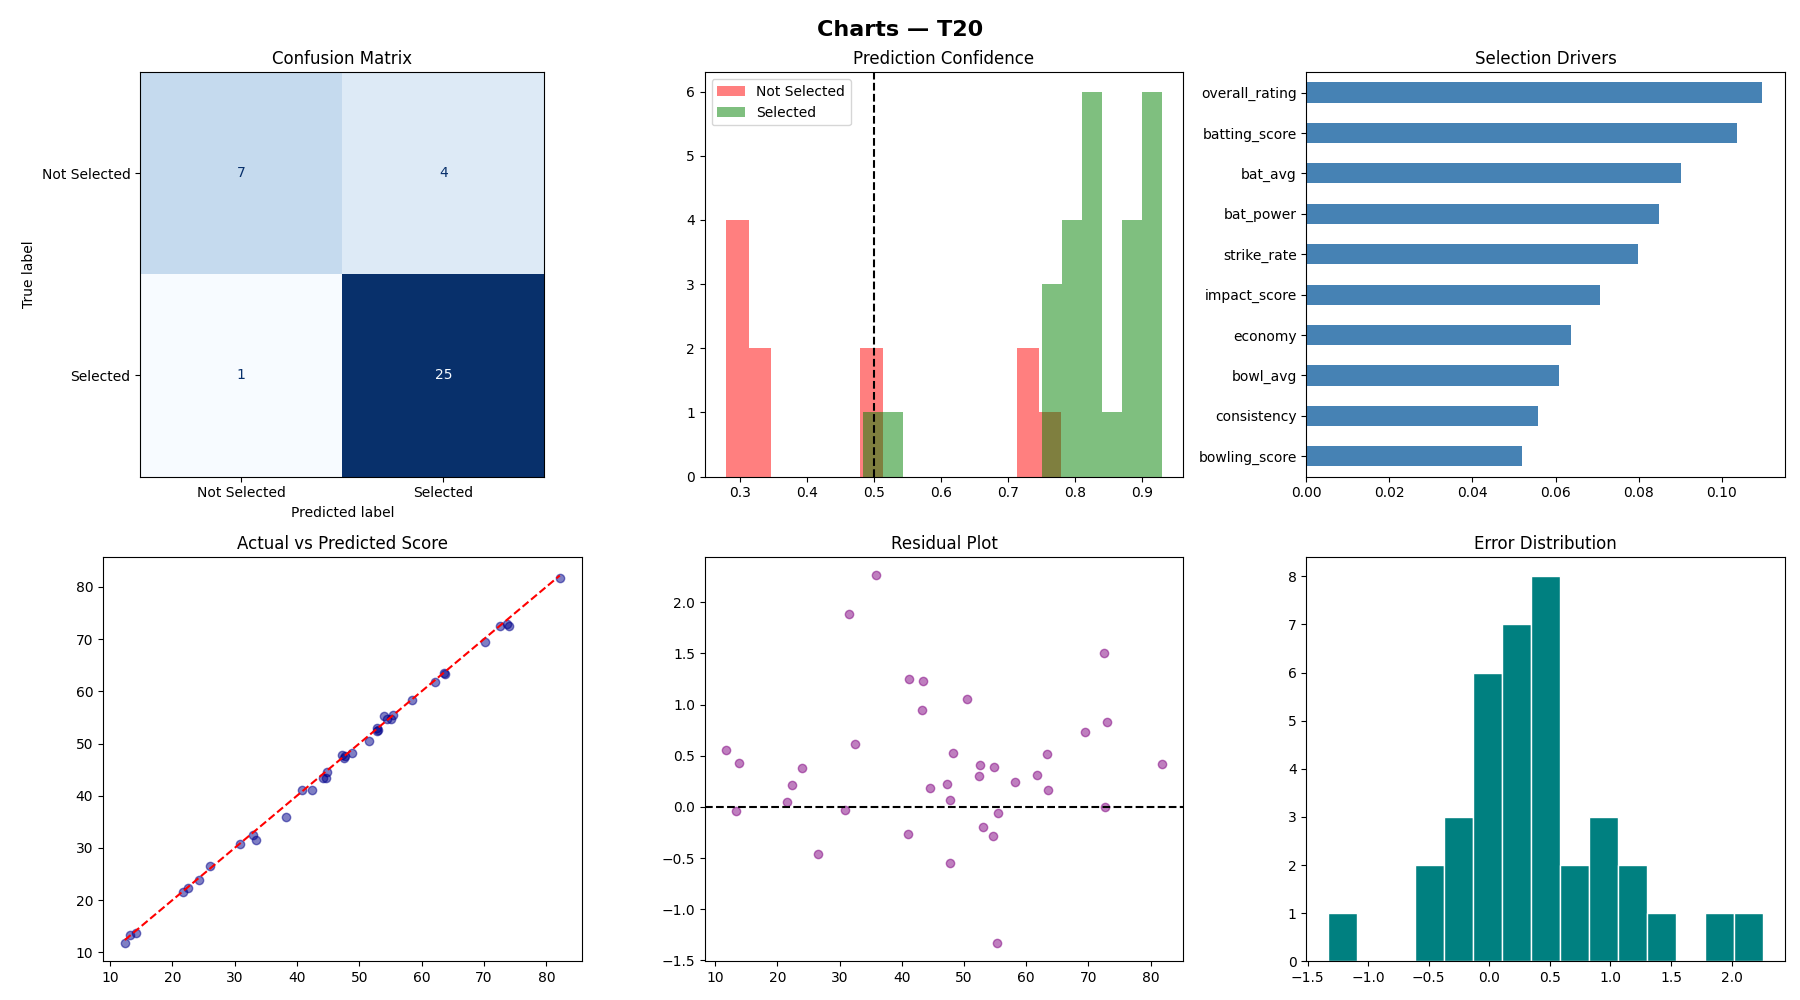


OPTIMIZING ODI
  Label balance: 71.74% selected (132 of 184)

ODI RESULTS
----------------------------------------
Training Accuracy : 0.8707
Testing Accuracy  : 0.8378
Gap               : 0.0329


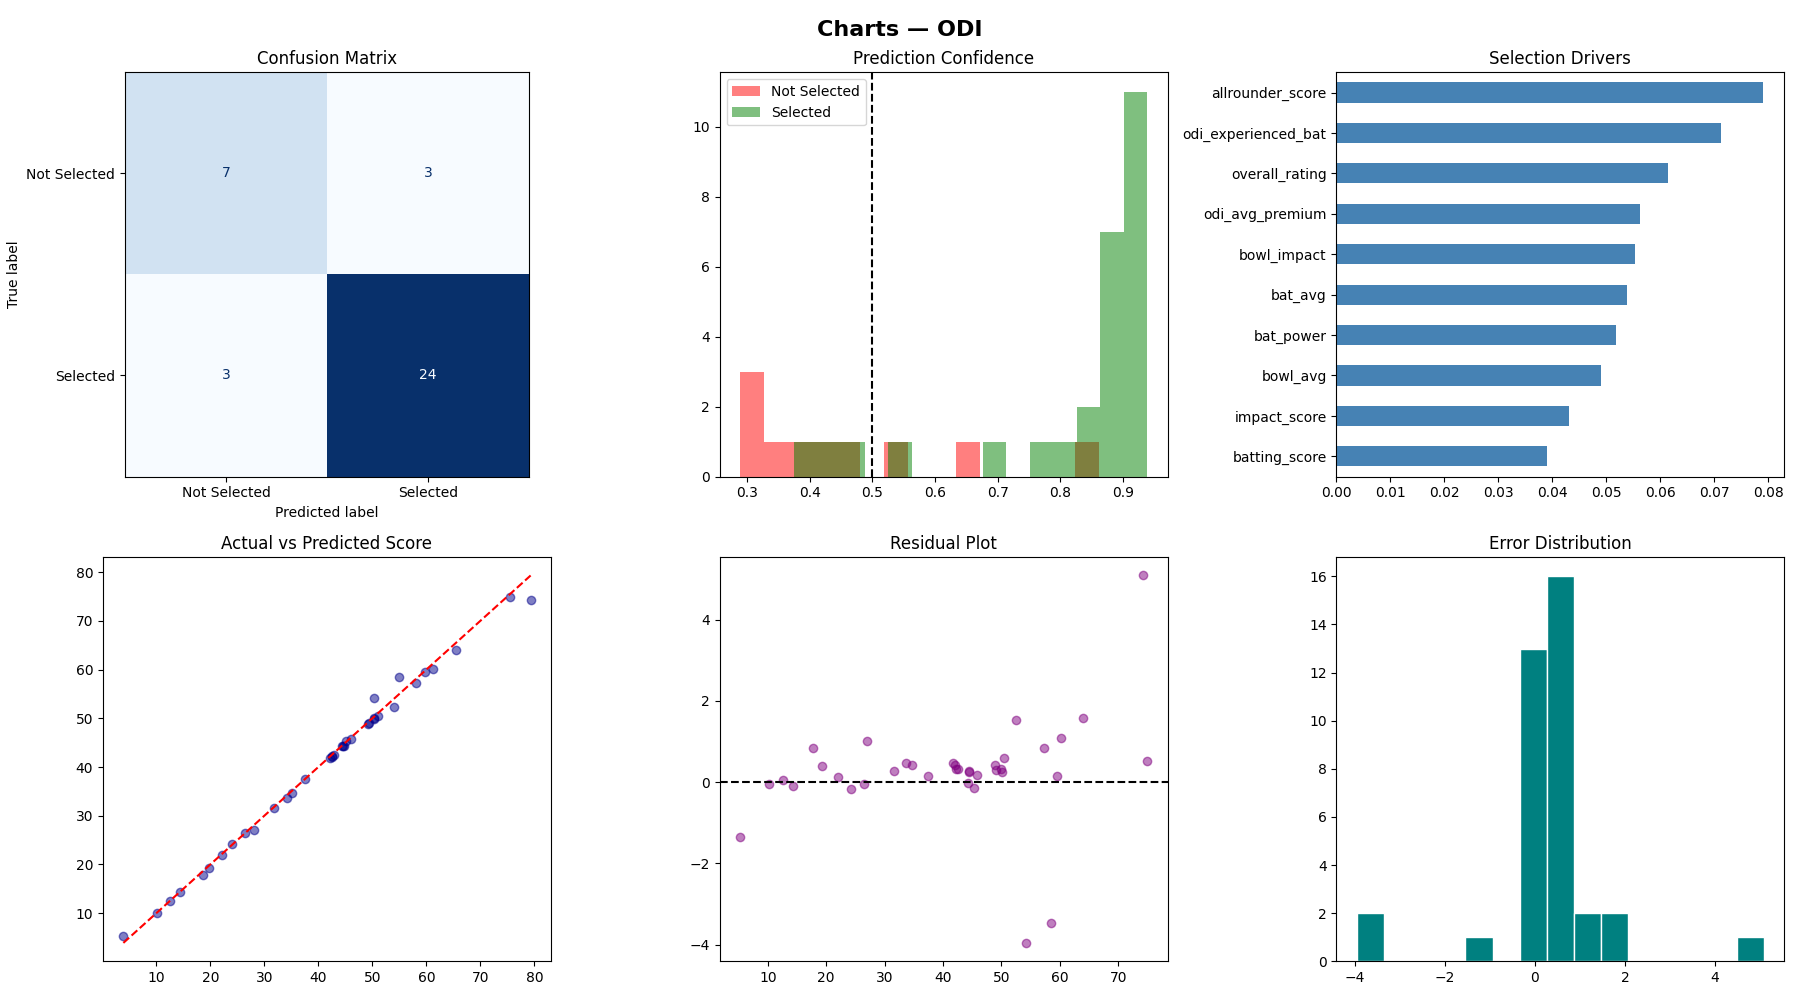


OPTIMIZING Test
  Label balance: 72.93% selected (132 of 181)

Test RESULTS
----------------------------------------
Training Accuracy : 0.7500
Testing Accuracy  : 0.7297
Gap               : 0.0203


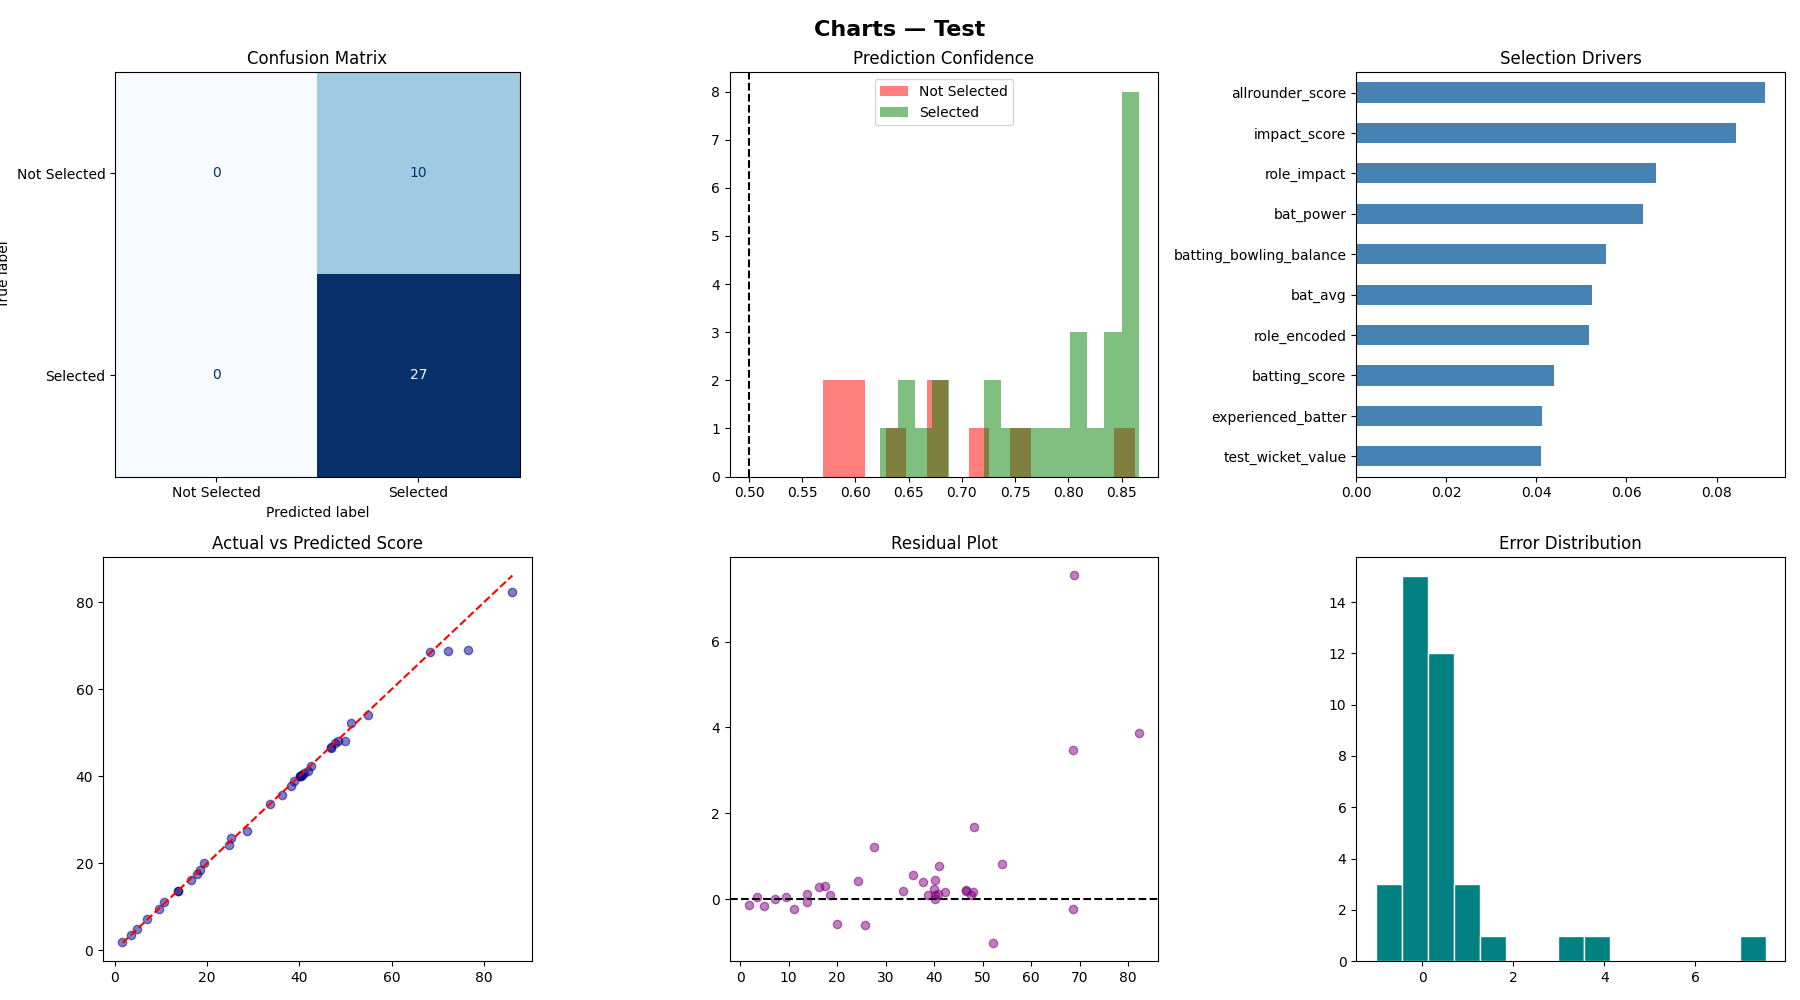


Models successfully optimized and charts generated!


In [10]:



def create_labels(df, fmt, venue_profile=None):
    
    if df.empty:
        return df

    df = df.copy()
    df["is_in_probable_11"] = 0

    all_ar_roles  = ["All-Rounder", "Batting All-Rounder", "Bowling All-Rounder"]
    pitch_type    = venue_profile.get("pitch_type", "Balanced") if venue_profile else "Balanced"

    # ── format-specific raw-stat weights ─────────────────
    # T20:  SR and wickets matter most
    # ODI:  balance avg + SR + wickets
    # Test: avg and wickets dominate
    STAT_WEIGHTS = {
        "T20" : {"runs": 0.10, "bat_avg": 0.20, "strike_rate": 0.35,
                 "wickets": 0.20, "economy": -0.15},
        "ODI" : {"runs": 0.15, "bat_avg": 0.30, "strike_rate": 0.20,
                 "wickets": 0.20, "economy": -0.15},
        "Test": {"runs": 0.20, "bat_avg": 0.40, "strike_rate": 0.05,
                 "wickets": 0.20, "economy": -0.15},
    }

    w = STAT_WEIGHTS.get(fmt, STAT_WEIGHTS["ODI"])

    # ── normalise raw stats 0-1 per column ───────────────
    stat_cols = ["runs", "bat_avg", "strike_rate", "wickets", "economy"]
    norm = {}
    for col in stat_cols:
        if col in df.columns:
            col_min = df[col].min()
            col_max = df[col].max()
            rng     = col_max - col_min
            norm[col] = (df[col] - col_min) / rng if rng > 0 else pd.Series(0.0, index=df.index)
        else:
            norm[col] = pd.Series(0.0, index=df.index)

    # economy: lower is better → invert
    norm["economy"] = 1 - norm["economy"]

    # ── build composite rank score ────────────────────────
    df["_rank_score"] = (
        norm["runs"]         * abs(w["runs"])         +
        norm["bat_avg"]      * abs(w["bat_avg"])       +
        norm["strike_rate"]  * abs(w["strike_rate"])   +
        norm["wickets"]      * abs(w["wickets"])       +
        norm["economy"]      * abs(w["economy"])
    )

    # blend 60% raw rank + 40% computed scores
    # (keeps some score signal but doesn't depend on it 100%)
    score_cols = ["batting_score", "bowling_score", "allrounder_score"]
    for col in score_cols:
        if col not in df.columns:
            df[col] = 0.0

    df["_composite"] = (
        df["_rank_score"] * 0.60 +
        (df["batting_score"]   / 100) * 0.20 +
        (df["bowling_score"]   / 100) * 0.12 +
        (df["allrounder_score"]/ 100) * 0.08
    )

    # ── select 11 per team using role quotas ──────────────
    for team in df["team"].unique():
        tm   = df[df["team"] == team]
        sel  = []

        # 1. Best wicketkeeper
        wk = (tm[tm["role"] == "Wicketkeeper"]
              .nlargest(1, "_composite"))
        sel.extend(wk.index.tolist())

        # 2. Specialist bowlers (3-4 depending on format)
        n_bowlers = 4 if fmt == "Test" else 3
        bw = (tm[(tm["role"] == "Bowler") &
                 (~tm.index.isin(sel))]
              .nlargest(n_bowlers, "_composite"))
        sel.extend(bw.index.tolist())

        # 3. All-rounders
        ar_q = 2 if fmt == "Test" else 3
        ar = (tm[(tm["role"].isin(all_ar_roles)) &
                 (~tm.index.isin(sel))]
              .nlargest(ar_q, "_composite"))
        sel.extend(ar.index.tolist())

        # 4. Fill remaining slots with best available
        remaining = 11 - len(sel)
        if remaining > 0:
            rest = (tm[~tm.index.isin(sel)]
                    .nlargest(remaining, "_composite"))
            sel.extend(rest.index.tolist())

        df.loc[sel[:11], "is_in_probable_11"] = 1

    # cleanup helper columns
    df.drop(columns=["_rank_score", "_composite"], inplace=True)

    label_counts = df["is_in_probable_11"].value_counts().to_dict()
    print(f"  {fmt} labels → Selected: {label_counts.get(1,0)} | "
          f"Not selected: {label_counts.get(0,0)}")

    return df


print("Generating training labels (is_in_probable_11)...")
t20_master  = create_labels(t20_master,  "T20")
odi_master  = create_labels(odi_master,  "ODI")
test_master = create_labels(test_master, "Test")
print("Labels generated successfully!")



# : FEATURES + CONFIGS 


FEATURES = [
    "runs","bat_avg","strike_rate",
    "wickets","bowl_avg","economy",
    "batting_score","bowling_score","allrounder_score",
    "role_encoded",
    "is_wicketkeeper","is_batter","is_bowler","is_allrounder",
    "is_captain","high_striker","economy_bowler",
    "experienced_batter","wicket_taker","power_hitter",
    "elite_bowler","elite_striker","elite_batter","century_scorer"
]

FORMAT_CONFIGS = {
    "T20": {
        "n_estimators"     : 900,
        "max_depth"        : 5,
        "learning_rate"    : 0.015,
        "subsample"        : 0.80,
        "colsample_bytree" : 0.75,
        "min_child_weight" : 4,
        "gamma"            : 1.5,
        "reg_alpha"        : 1.5,
        "reg_lambda"       : 5.0,
        "early_stopping"   : 60,
        "test_size"        : 0.20,
    },
    "ODI": {
        "n_estimators"     : 900,
        "max_depth"        : 6,
        "learning_rate"    : 0.015,
        "subsample"        : 0.85,
        "colsample_bytree" : 0.80,
        "min_child_weight" : 3,
        "gamma"            : 1.0,
        "reg_alpha"        : 1.0,
        "reg_lambda"       : 4.0,
        "early_stopping"   : 60,
        "test_size"        : 0.20,
    },
    "Test": {
        "n_estimators"     : 900,
        "max_depth"        : 6,
        "learning_rate"    : 0.015,
        "subsample"        : 0.85,
        "colsample_bytree" : 0.80,
        "min_child_weight" : 3,
        "gamma"            : 1.0,
        "reg_alpha"        : 1.0,
        "reg_lambda"       : 4.0,
        "early_stopping"   : 60,
        "test_size"        : 0.20,
    },
}



#  SUPPORT FUNCTIONS


def native_oversample(X, y, random_state=42):
    np.random.seed(random_state)
    y_np  = y.values
    idx_0 = np.where(y_np == 0)[0]
    idx_1 = np.where(y_np == 1)[0]

    if len(idx_1) < len(idx_0):
        extra_idx = np.random.choice(
            idx_1, size=len(idx_0) - len(idx_1), replace=True
        )
        new_idx = np.concatenate([np.arange(len(y_np)), extra_idx])
        return (X.iloc[new_idx].reset_index(drop=True),
                y.iloc[new_idx].reset_index(drop=True))

    return X, y


def build_model_features(df, fmt):
    """
    Feature engineering for the MODEL only.
    Deliberately renamed to avoid clash with the
    engineer_features() used in earlier preprocessing.
    """
    df = df.copy()

    # ── universal ────────────────────────────────────────
    df['bat_power']            = df['bat_avg'] * df['strike_rate']
    df['bowl_impact']          = df['wickets'] * (7 - df['economy'])
    df['consistency']          = (df['runs'] + 1) / (df['strike_rate'] + 1)
    df['experience_index']     = (df['runs'] * 0.4) + (df['wickets'] * 30)
    df['impact_score']         = (df['batting_score']    * 0.5 +
                                   df['bowling_score']    * 0.3 +
                                   df['allrounder_score'] * 0.2)
    df['overall_rating']       = df['bat_power'] + df['bowl_impact'] + df['impact_score']
    df['avg_sr_ratio']         = df['bat_avg'] / (df['strike_rate'] + 1)
    df['wicket_economy_ratio'] = (df['wickets'] + 1) / (df['economy'] + 1)
    df['role_impact']          = df['role_encoded'] * df['impact_score']
    df['batting_bowling_balance'] = (df['batting_score'] - df['bowling_score']).abs()

    if fmt == "T20":
        df['t20_sr_premium']      = np.where(df['strike_rate'] > 130,
                                             (df['strike_rate'] - 130) * df['bat_avg'], 0)
        df['t20_economy_bonus']   = np.where(df['economy'] < 7.5,
                                             (7.5 - df['economy']) * df['wickets'], 0)
        df['t20_power_flag']      = df['power_hitter'] * df['high_striker']
        df['t20_death_bowler']    = df['wicket_taker'] * df['economy_bowler']
        df['t20_allrounder_value']= df['is_allrounder'] * (df['batting_score'] + df['bowling_score'])
        df['t20_boundary_proxy']  = df['strike_rate'] * df['power_hitter']
        df['t20_finisher_value']  = df['high_striker'] * df['bat_avg'] * df['is_allrounder']

    elif fmt == "ODI":
        df['odi_anchor_value']    = df['bat_avg'] * df['consistency']
        df['odi_death_bowler']    = df['wicket_taker'] * df['economy_bowler']
        df['odi_avg_premium']     = np.where(df['bat_avg'] > 35,
                                             (df['bat_avg'] - 35) * df['consistency'], 0)
        df['odi_sr_bonus']        = np.where(df['strike_rate'] > 85,
                                             (df['strike_rate'] - 85) * df['bat_avg'], 0)
        df['odi_economy_bonus']   = np.where(df['economy'] < 5.5,
                                             (5.5 - df['economy']) * df['wickets'], 0)
        df['odi_experienced_bat'] = df['experienced_batter'] * df['bat_avg']
        df['odi_allrounder_val']  = df['is_allrounder'] * (df['batting_score'] * 0.6 +
                                                            df['bowling_score'] * 0.4)

    elif fmt == "Test":
        df['test_avg_premium']    = np.where(df['bat_avg'] > 40,
                                             (df['bat_avg'] - 40) * df['consistency'], 0)
        df['test_wicket_value']   = df['wickets'] * df['bowl_avg'].apply(lambda x: max(0, 35 - x))
        df['test_elite_bat']      = np.where(df['bat_avg'] > 45,
                                             (df['bat_avg'] - 45) * df['runs'], 0)
        df['test_bowl_quality']   = np.where(df['bowl_avg'] < 30,
                                             (30 - df['bowl_avg']) * df['wickets'], 0)
        df['test_run_accumulator']= df['experienced_batter'] * df['runs']
        df['test_allrounder_val'] = df['is_allrounder'] * (df['batting_score'] * 0.5 +
                                                            df['bowling_score'] * 0.5)
        df['test_wicket_taker']   = df['wicket_taker'] * df['wickets']

    return df


def get_feature_list(df, fmt):
    base = [f for f in FEATURES if f in df.columns] + [
        'bat_power', 'bowl_impact', 'consistency', 'experience_index',
        'impact_score', 'overall_rating', 'avg_sr_ratio',
        'wicket_economy_ratio', 'role_impact', 'batting_bowling_balance'
    ]
    extras = {
        "T20" : ['t20_sr_premium','t20_economy_bonus','t20_power_flag',
                 't20_death_bowler','t20_allrounder_value',
                 't20_boundary_proxy','t20_finisher_value'],
        "ODI" : ['odi_anchor_value','odi_death_bowler','odi_avg_premium',
                 'odi_sr_bonus','odi_economy_bonus','odi_experienced_bat',
                 'odi_allrounder_val'],
        "Test": ['test_avg_premium','test_wicket_value','test_elite_bat',
                 'test_bowl_quality','test_run_accumulator',
                 'test_allrounder_val','test_wicket_taker'],
    }
    return [f for f in base + extras.get(fmt, []) if f in df.columns]


def plot_all_charts(clf, reg, y_test_c, y_pred_test, y_prob_test,
                    y_test_r, y_pred_r, fmt):
    plt.clf(); plt.close('all')
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Charts — {fmt}", fontsize=16, fontweight='bold')

    cm = confusion_matrix(y_test_c, y_pred_test)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Not Selected","Selected"]
                           ).plot(ax=axes[0,0], colorbar=False, cmap="Blues")
    axes[0,0].set_title("Confusion Matrix")

    axes[0,1].hist(y_prob_test[y_test_c==0], bins=15, alpha=0.5,
                   label="Not Selected", color="red")
    axes[0,1].hist(y_prob_test[y_test_c==1], bins=15, alpha=0.5,
                   label="Selected", color="green")
    axes[0,1].axvline(0.5, color='black', linestyle='--')
    axes[0,1].set_title("Prediction Confidence"); axes[0,1].legend()

    importances = clf.feature_importances_
    feat_names  = [f"F{i}" for i in range(len(importances))]
    try: feat_names = clf.get_booster().feature_names
    except: pass
    pd.Series(importances, index=feat_names).sort_values().tail(10).plot(
        kind='barh', ax=axes[0,2], color='steelblue')
    axes[0,2].set_title("Selection Drivers")

    axes[1,0].scatter(y_test_r, y_pred_r, alpha=0.5, color="darkblue")
    axes[1,0].plot([min(y_test_r), max(y_test_r)],
                   [min(y_test_r), max(y_test_r)], 'r--')
    axes[1,0].set_title("Actual vs Predicted Score")

    residuals = y_test_r - y_pred_r
    axes[1,1].scatter(y_pred_r, residuals, alpha=0.5, color="purple")
    axes[1,1].axhline(0, color='black', linestyle='--')
    axes[1,1].set_title("Residual Plot")

    axes[1,2].hist(residuals, bins=15, color="teal", edgecolor="white")
    axes[1,2].set_title("Error Distribution")

    plt.tight_layout()
    path = f"results_{fmt.lower()}.png"
    plt.savefig(path)
    from IPython.display import display, Image
    display(Image(filename=path))
    plt.close(fig)



#  MAIN TRAINING FUNCTION


def train_all_models(master_df, fmt):

    print(f"\n{'='*60}")
    print(f"OPTIMIZING {fmt}")
    print(f"{'='*60}")

    cfg = FORMAT_CONFIGS[fmt]
    df  = build_model_features(master_df.copy(), fmt)   # ← renamed fn

    EXTENDED_FEATURES = get_feature_list(df, fmt)

    X       = df[EXTENDED_FEATURES].fillna(0)
    y_class = df["is_in_probable_11"]
    y_reg   = df["batting_score"]

    # ── sanity check ────────────────────────────────────
    pos_rate = y_class.mean()
    print(f"  Label balance: {pos_rate:.2%} selected "
          f"({y_class.sum()} of {len(y_class)})")

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y_class,
        test_size=cfg["test_size"],
        stratify=y_class,
        random_state=42
    )

    X_train_c, y_train_c = native_oversample(X_train_c, y_train_c)

    X_tr2, X_val, y_tr2, y_val = train_test_split(
        X_train_c, y_train_c,
        test_size=0.12,
        stratify=y_train_c,
        random_state=42
    )

    clf = xgb.XGBClassifier(
        n_estimators          = cfg["n_estimators"],
        max_depth             = cfg["max_depth"],
        learning_rate         = cfg["learning_rate"],
        subsample             = cfg["subsample"],
        colsample_bytree      = cfg["colsample_bytree"],
        min_child_weight      = cfg["min_child_weight"],
        gamma                 = cfg["gamma"],
        reg_alpha             = cfg["reg_alpha"],
        reg_lambda            = cfg["reg_lambda"],
        objective             = 'binary:logistic',
        random_state          = 42,
        eval_metric           = 'logloss',
        early_stopping_rounds = cfg["early_stopping"]
    )
    clf.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y_reg, test_size=0.20, random_state=42
    )
    reg = xgb.XGBRegressor(
        n_estimators     = 450,
        max_depth        = cfg["max_depth"],
        learning_rate    = cfg["learning_rate"],
        subsample        = cfg["subsample"],
        colsample_bytree = cfg["colsample_bytree"],
        reg_alpha        = cfg["reg_alpha"],
        reg_lambda       = cfg["reg_lambda"],
        random_state     = 42
    )
    reg.fit(X_train_r, y_train_r)

    y_train_prob = clf.predict_proba(X_train_c)[:,1]
    y_train_pred = (y_train_prob >= 0.50).astype(int)
    train_acc    = accuracy_score(y_train_c, y_train_pred)

    y_test_prob  = clf.predict_proba(X_test_c)[:,1]
    y_test_pred  = (y_test_prob >= 0.50).astype(int)
    test_acc     = accuracy_score(y_test_c, y_test_pred)

    print(f"\n{fmt} RESULTS")
    print("-" * 40)
    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Testing Accuracy  : {test_acc:.4f}")
    print(f"Gap               : {abs(train_acc - test_acc):.4f}")

    plot_all_charts(clf, reg, y_test_c, y_test_pred, y_test_prob,
                    y_test_r, reg.predict(X_test_r), fmt)

    return clf, reg



#  EXECUTION


os.makedirs("../models", exist_ok=True)

for master, fmt in [
    (t20_master,  "T20"),
    (odi_master,  "ODI"),
    (test_master, "Test")
]:
    c_m, r_m = train_all_models(master, fmt)

    if c_m and r_m:
        joblib.dump(c_m, f"../models/clf_{fmt.lower()}.pkl")
        joblib.dump(r_m, f"../models/reg_{fmt.lower()}.pkl")

print("\nModels successfully optimized and charts generated!")

In [11]:
import shap
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# HELPER: Rebuild exact feature matrix used during training
# =========================================================

def get_shap_features(master_df, fmt):
    """
    Rebuilds the EXACT feature matrix used during training
    by calling build_model_features + get_feature_list.
    This guarantees feature count/order matches the saved model.
    """
    df = build_model_features(master_df.copy(), fmt)
    feat_cols = get_feature_list(df, fmt)
    X = df[feat_cols].fillna(0)
    return X, feat_cols


def build_explainer(model):
    if model is None:
        print("  WARNING: Model is None, cannot build explainer.")
        return None
    return shap.TreeExplainer(model)


# =========================================================
# LOAD MODELS
# =========================================================

print("Loading models...")

try:
    model_clf_t20  = joblib.load("../models/clf_t20.pkl")
    model_clf_odi  = joblib.load("../models/clf_odi.pkl")
    model_clf_test = joblib.load("../models/clf_test.pkl")
    print("  All classifiers loaded.")
except Exception as e:
    print(f"  Load error: {e}")

# =========================================================
# SHAP ANALYSIS — runs for each format
# =========================================================

SHAP_TARGETS = [
    ("T20",  locals().get("model_clf_t20"),  t20_master),
    ("ODI",  locals().get("model_clf_odi"),  odi_master),
    ("Test", locals().get("model_clf_test"), test_master),
]

os.makedirs("../models", exist_ok=True)

for fmt, model, master_df in SHAP_TARGETS:

    print(f"\n{'='*55}")
    print(f"SHAP ANALYSIS — {fmt}")
    print(f"{'='*55}")

    if model is None:
        print(f"  Skipping {fmt}: model not loaded.")
        continue

    # ── 1. Build exact feature matrix ───────────────────
    X_shap, feat_cols = get_shap_features(master_df, fmt)

    # ── 2. Verify feature alignment with saved model ────
    try:
        model_feat_names = model.get_booster().feature_names

        if model_feat_names is not None:
            missing  = [f for f in model_feat_names if f not in X_shap.columns]
            extra    = [f for f in X_shap.columns   if f not in model_feat_names]

            if missing:
                print(f"  WARNING: {len(missing)} features missing from data: {missing}")
                for f in missing:
                    X_shap[f] = 0.0   # fill with zeros as safe fallback

            # Reorder columns to exactly match model's expected order
            X_shap = X_shap[model_feat_names]
            print(f"  Features aligned: {len(model_feat_names)} features")
        else:
            print(f"  Feature names not stored in model, using computed list.")

    except Exception as e:
        print(f"  Feature alignment warning: {e}")

    print(f"  Input shape: {X_shap.shape}")

    # ── 3. Build explainer + compute SHAP values ────────
    explainer = build_explainer(model)

    if explainer is None:
        continue

    print(f"  Computing SHAP values...")

    try:
        # Use shap_values() directly — more stable than __call__
        # for XGBoost classifiers (avoids the shape mismatch bug)
        shap_vals = explainer.shap_values(X_shap)

        # For binary classifiers XGBoost may return a list [neg, pos]
        # or a single 2D array — handle both
        if isinstance(shap_vals, list):
            sv = shap_vals[1]   # take positive class
        else:
            sv = shap_vals      # single array (already positive class)

        print(f"  SHAP values shape: {sv.shape}")

    except Exception as e:
        print(f"  ERROR computing SHAP values: {e}")
        continue

    # ── 4. Summary plot ─────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        sv,
        X_shap,
        plot_type="dot",
        show=False,
        max_display=15
    )
    plt.title(f"SHAP Feature Impact — {fmt}", fontsize=14, fontweight='bold')
    plt.tight_layout()

    plot_path = f"../models/shap_summary_{fmt.lower()}.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Summary plot saved → {plot_path}")

    # ── 5. Bar plot (mean |SHAP|) ────────────────────────
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        sv,
        X_shap,
        plot_type="bar",
        show=False,
        max_display=15
    )
    plt.title(f"Mean |SHAP| — {fmt}", fontsize=14, fontweight='bold')
    plt.tight_layout()

    bar_path = f"../models/shap_bar_{fmt.lower()}.png"
    plt.savefig(bar_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Bar plot saved → {bar_path}")

    # ── 6. Top features summary table ───────────────────
    mean_shap = np.abs(sv).mean(axis=0)
    feat_importance = (
        pd.DataFrame({
            "feature"    : X_shap.columns.tolist(),
            "mean_|shap|": mean_shap
        })
        .sort_values("mean_|shap|", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n  Top 10 most impactful features ({fmt}):")
    print(feat_importance.head(10).to_string(index=False))

    # ── 7. Save explainer ───────────────────────────────
    try:
        explainer_path = f"../models/explainer_{fmt.lower()}.pkl"
        joblib.dump(explainer, explainer_path)
        print(f"\n  Explainer saved → {explainer_path}")
    except Exception as e:
        print(f"  Explainer save warning: {e}")

print("\nSHAP analysis complete!")

Loading models...
  All classifiers loaded.

SHAP ANALYSIS — T20
  Features aligned: 39 features
  Input shape: (185, 39)
  Computing SHAP values...
  SHAP values shape: (185, 39)
  Summary plot saved → ../models/shap_summary_t20.png
  Bar plot saved → ../models/shap_bar_t20.png

  Top 10 most impactful features (T20):
             feature  mean_|shap|
            bowl_avg     0.336892
         consistency     0.223300
        impact_score     0.149392
         strike_rate     0.110907
    allrounder_score     0.110021
             bat_avg     0.106943
       batting_score     0.097334
           bat_power     0.096722
         role_impact     0.055984
wicket_economy_ratio     0.052943

  Explainer saved → ../models/explainer_t20.pkl

SHAP ANALYSIS — ODI
  Features aligned: 39 features
  Input shape: (184, 39)
  Computing SHAP values...
  SHAP values shape: (184, 39)
  Summary plot saved → ../models/shap_summary_odi.png
  Bar plot saved → ../models/shap_bar_odi.png

  Top 10 most impac

In [12]:
# =========================================================
# COMPLETE MATCH PREVIEW CELL
# All functions defined in execution order — no NameError
# =========================================================

import pandas as pd
import numpy as np


# =========================================================
# 1. VENUE PROFILE
# =========================================================

def get_venue_profile(venue_name, venues_df, allgrounds_df,
                      rpo_df, rpw_df, home_away_df, fmt):
    """
    Profiles a venue into High / Mid / Low scoring environment.
    """
    profile = {
        "country"        : "Unknown",
        "stadium"        : venue_name,
        "city"           : "Unknown",
        "pitch_type"     : "Balanced",
        "pitch_assist"   : "Unknown",
        "boundary"       : "Medium",
        "scoring"        : "Medium",
        "weather"        : "Clear",
        "rpo"            : 0.0,
        "rpw"            : 0.0,
        "matches_played" : 0,
    }

    search  = venue_name.lower().strip()
    fmt_map = {"ODI": "ODI", "T20": "T20", "TEST": "Test"}
    target_fmt_col = fmt_map.get(fmt.upper(), "ODI")

    def find_venue_row(df, search_term):
        if df is None or df.empty:
            return None
        search_cols = [c for c in df.columns
                       if c.lower() in ["ground", "city", "stadium", "ground_name"]]
        mask = df.apply(
            lambda row: any(search_term in str(row[c]).lower()
                            for c in search_cols if c in df.columns),
            axis=1
        )
        matches = df[mask]
        return matches.iloc[0] if not matches.empty else None

    # allgrounds
    ag_row = find_venue_row(allgrounds_df, search)
    if ag_row is not None:
        profile["stadium"] = str(ag_row.get("Ground", venue_name))
        profile["city"]    = str(ag_row.get("City",    "Unknown"))
        profile["country"] = str(ag_row.get("Country", "Unknown"))
        if target_fmt_col in ag_row:
            try:
                profile["matches_played"] = int(ag_row[target_fmt_col])
            except Exception:
                profile["matches_played"] = 0

    # venues CSV
    v_row = find_venue_row(venues_df, search)
    if v_row is not None:
        for key, col in [
            ("pitch_type",   "Pitch Type"),
            ("pitch_assist", "Pitch Assist"),
            ("scoring",      "Scoring"),
            ("weather",      "Weather"),
        ]:
            if col in v_row:
                profile[key] = str(v_row[col])

    # rpo / rpw
    for df, key in [(rpo_df, "rpo"), (rpw_df, "rpw")]:
        row = find_venue_row(df, search)
        if row is not None:
            col_to_use = key if key in row else row.index[-1]
            try:
                profile[key] = float(row[col_to_use])
            except Exception:
                pass

    return profile


# =========================================================
# 2. PROBABLE XI
# =========================================================

def get_probable_11(team_name, opponent_name, master_df,
                    clf_model, reg_model, fmt, venue, **kwargs):

    team_df = master_df[master_df["team"] == team_name].copy()
    if team_df.empty:
        print(f"  WARNING: No players found for team '{team_name}'")
        return []

    # ── Feature engineering (exact training pipeline) ────
    team_df   = build_model_features(team_df, fmt)
    feat_cols = get_feature_list(team_df, fmt)

    # ── Align to model's stored feature names ────────────
    try:
        model_feat_names = clf_model.get_booster().feature_names
        if model_feat_names:
            for f in model_feat_names:          # fill any missing cols
                if f not in team_df.columns:
                    team_df[f] = 0.0
            X = team_df[model_feat_names].fillna(0)
        else:
            X = team_df[feat_cols].fillna(0)
    except Exception as e:
        print(f"  Feature alignment fallback: {e}")
        X = team_df[feat_cols].fillna(0)

    # ── Predict ──────────────────────────────────────────
    team_df["probability"] = clf_model.predict_proba(X)[:, 1]

    # ── Venue adjustments ────────────────────────────────
    pitch   = str(venue.get("pitch_type", "Balanced")).lower()
    scoring = str(venue.get("scoring",    "Medium")).lower()
    avg_rpo = venue.get("rpo", 0)

    is_high_scoring = "high" in scoring or avg_rpo > 8.5
    is_low_scoring  = "low"  in scoring or (0 < avg_rpo < 6.0)

    if "spin" in pitch or "pace" in pitch or is_low_scoring:
        mask = team_df["role"].str.contains("Bowler|All-Rounder", na=False)
        team_df.loc[mask, "probability"] *= 1.12

    if is_high_scoring:
        mask = team_df["role"].str.contains("Batter|All-Rounder", na=False)
        team_df.loc[mask, "probability"] *= 1.12

    team_df["probability"] = team_df["probability"].clip(0, 0.99)

    # ── Role-quota selection (10 core + 1 dynamic) ───────
    selected_indices = []

    def pick_players(roles, count):
        mask = (
            team_df["role"].isin(roles) &
            (~team_df.index.isin(selected_indices))
        )
        return team_df[mask].nlargest(count, "probability").index.tolist()

    selected_indices.extend(pick_players(["Wicketkeeper"], 1))
    selected_indices.extend(pick_players(["Batter", "Batting All-Rounder"], 3))
    selected_indices.extend(pick_players(
        ["All-Rounder", "Batting All-Rounder", "Bowling All-Rounder"], 3))
    selected_indices.extend(pick_players(["Bowler", "Bowling All-Rounder"], 3))

    if is_high_scoring:
        selected_indices.extend(
            pick_players(["Batter", "Batting All-Rounder", "All-Rounder"], 1))
    elif is_low_scoring:
        selected_indices.extend(
            pick_players(["Bowler", "Bowling All-Rounder"], 1))
    else:
        selected_indices.extend(
            pick_players(["All-Rounder", "Batting All-Rounder",
                          "Bowling All-Rounder"], 1))

    # Safety catch
    if len(selected_indices) < 11:
        needed  = 11 - len(selected_indices)
        backups = (team_df[~team_df.index.isin(selected_indices)]
                   .nlargest(needed, "probability").index.tolist())
        selected_indices.extend(backups)

    # Deduplicate — preserve insertion order
    seen = set()
    selected_indices = [i for i in selected_indices
                        if not (i in seen or seen.add(i))]

    final_xi = team_df.loc[selected_indices[:11]].copy()

    # ── Reasoning ────────────────────────────────────────
    def generate_final_reason(row):
        role    = row["role"]
        stadium = venue.get("stadium", "this venue")
        p_val   = row["probability"] * 100

        if is_high_scoring and "Batter" in role:
            s1 = (f"Selected as a primary run-scorer to exploit "
                  f"the high-scoring conditions at {stadium}.")
        elif is_low_scoring and "Bowler" in role:
            s1 = ("Drafted as a strike bowler to capitalise on the "
                  "bowling-friendly surface and low-scoring trends.")
        elif "Wicketkeeper" in role:
            s1 = ("Reliable gloveman and clinical finisher chosen "
                  "to anchor the middle order.")
        else:
            s1 = (f"Tactical inclusion providing balance as a {role} "
                  f"suited for {pitch} conditions.")

        if   p_val >= 85: s2 = f"Elite {p_val:.2f}% score — undisputed starter."
        elif p_val >= 70: s2 = f"Solid {p_val:.2f}% rating — tactical lock."
        else:             s2 = f"Situational specialist at {p_val:.2f}%."

        return f"{s1} {s2}"

    final_xi["reason"] = final_xi.apply(generate_final_reason, axis=1)

    # ── Sort + output ─────────────────────────────────────
    role_priority = {
        "Wicketkeeper"        : 1,
        "Batter"              : 2,
        "Batting All-Rounder" : 3,
        "All-Rounder"         : 4,
        "Bowling All-Rounder" : 5,
        "Bowler"              : 6,
    }
    final_xi["sort_order"] = final_xi["role"].map(role_priority).fillna(7)
    final_xi = final_xi.sort_values(
        by=["sort_order", "probability"], ascending=[True, False]
    )

    if "player_name" in final_xi.columns:
        final_xi["player"] = final_xi["player_name"]

    final_xi["probability"] = (final_xi["probability"] * 100).round(2)
    return final_xi.drop(columns=["sort_order"]).to_dict("records")


# =========================================================
# 3. MATCH PREVIEW
# =========================================================

def match_preview_and_xi(team1, team2, venue_name, fmt,
                         master_df, clf_model, reg_model,
                         explainer, venues_df, allgrounds_df,
                         rpo_df, rpw_df, home_away_df):

    fmt_clean = fmt.strip().upper()

    # Venue profile
    venue = get_venue_profile(
        venue_name, venues_df, allgrounds_df,
        rpo_df, rpw_df, home_away_df, fmt_clean
    )

    # Predicted XIs
    t1_xi = get_probable_11(team1, team2, master_df,
                            clf_model, reg_model, fmt_clean, venue)
    t2_xi = get_probable_11(team2, team1, master_df,
                            clf_model, reg_model, fmt_clean, venue)

    if not t1_xi:
        print(f"  ERROR: No XI for '{team1}' — check team name.")
        return
    if not t2_xi:
        print(f"  ERROR: No XI for '{team2}' — check team name.")
        return

    # Analysis helper
    def generate_analysis(xi):
        ars     = [p for p in xi if "All-Rounder" in p["role"]]
        batters = [p for p in xi if p["role"] in
                   ["Batter", "Wicketkeeper", "Batting All-Rounder"]]
        bowlers = [p for p in xi if p["role"] in
                   ["Bowler", "Bowling All-Rounder"]]

        top_player = sorted(xi, key=lambda x: x["probability"],
                            reverse=True)[0]["player"]
        top_bowler = (sorted(bowlers,
                             key=lambda x: x.get("wickets", 0),
                             reverse=True)[0]["player"]
                      if bowlers else "N/A")

        strengths, concerns = [], []
        if len(batters) >= 6:
            strengths.append("strong batting lineup")
        if len(ars) >= 3:
            strengths.append(
                f"excellent all-round depth ({len(ars)} all-rounders)")
        elif len(ars) >= 2:
            strengths.append(
                f"good all-round cover ({len(ars)} all-rounders)")
        if len([p for p in xi if p["role"] == "Bowler"]) < 4:
            concerns.append("limited specialist bowling options")

        return {
            "keeper"    : next((p["player"] for p in xi
                                if p["role"] == "Wicketkeeper"), "N/A"),
            "key_batter": sorted(batters,
                                 key=lambda x: x.get("bat_avg", 0),
                                 reverse=True)[0]["player"],
            "threat"    : top_bowler,
            "ar_main"   : ars[0]["player"] if ars else "N/A",
            "ar_count"  : len(ars),
            "strengths" : strengths,
            "concerns"  : concerns,
            "watch"     : top_player,
        }

    a1, a2 = generate_analysis(t1_xi), generate_analysis(t2_xi)

    rpo = venue.get("rpo", 0.0)
    thresholds  = {"T20": 8.5, "ODI": 5.25, "TEST": 2.75}
    is_high     = rpo > thresholds.get(fmt_clean, 5.25)
    impact_label = ("High-scoring / Batting friendly"
                    if is_high else "Balanced / Bowling friendly")

    # ── Print output ─────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  MATCH  : {team1.upper()} vs {team2.upper()}")
    print(f"  FORMAT : {fmt_clean}    VENUE : {venue_name}")
    print(f"{'='*65}")

    for t_name, xi in [(team1, t1_xi), (team2, t2_xi)]:
        print(f"\n{'='*60}")
        print(f"PROBABLE XI  —  {t_name.upper()}  ({fmt_clean})")
        print(f"{'='*60}")
        print(f"{'No.':<4}{'Player':<26}{'Role':<22}{'Prob%'}")
        print("-" * 60)
        for i, p in enumerate(xi, 1):
            print(f"{i:<4}{str(p['player']):<26}{p['role']:<22}"
                  f"{float(p['probability']):.2f}%")
            print(f"      ↳ {p['reason']}\n")

    print(f"{'='*65}")
    print(f"MATCH PREVIEW  —  {team1.upper()} vs {team2.upper()}")
    print(f"Format : {fmt_clean}  |  Venue : {venue_name}")
    print(f"{'='*65}")

    print(f"\nVENUE CONDITIONS — {venue_name.upper()}")
    print(f"{'-'*55}")
    print(f"  Matches played   : {venue.get('matches_played', 'N/A')}")
    print(f"  Runs per wicket  : {venue.get('rpw', 0.0):.2f}")
    print(f"  Runs per over    : {rpo:.2f}")
    print(f"  Pitch type       : {venue.get('pitch_type', 'N/A')}")
    print(f"  Contextual impact: {impact_label}")

    for t_name, analysis in [(team1, a1), (team2, a2)]:
        print(f"\n{t_name.upper()} ANALYSIS\n{'-'*55}")
        print(f"  Wicketkeeper  : {analysis['keeper']}")
        print(f"  Key batter    : {analysis['key_batter']}")
        print(f"  Bowling threat: {analysis['threat']}")
        print(f"  All-rounder   : {analysis['ar_main']}  "
              f"(total in XI: {analysis['ar_count']})")
        if analysis["strengths"]:
            print("  Strengths     :")
            for s in analysis["strengths"]:
                print(f"    ✓ {s}")
        if analysis["concerns"]:
            print("  Concerns      :")
            for c in analysis["concerns"]:
                print(f"    ✗ {c}")

    print(f"\nMATCH OUTLOOK\n{'-'*55}")
    print(f"  Watch from {team1:<20}: {a1['watch']}")
    print(f"  Watch from {team2:<20}: {a2['watch']}")
    print(f"\nPredictions via player format metrics & ground scoring indices.")
    print(f"{'='*65}")


# =========================================================
# 4. RUN
# =========================================================

match_preview_and_xi(
    "England",
    "South Africa",
    "Melbourne Cricket Ground",
    "T20",
    t20_master,
    locals().get("model_clf_t20"),
    locals().get("model_reg_t20"),
    locals().get("explainer_t20"),
    venues_df,
    allgrounds_df,
    t20_rpo_df,
    t20_rpw_df,
    odi_home_away_df
)


  MATCH  : ENGLAND vs SOUTH AFRICA
  FORMAT : T20    VENUE : Melbourne Cricket Ground

PROBABLE XI  —  ENGLAND  (T20)
No. Player                    Role                  Prob%
------------------------------------------------------------
1   Jos Buttler               Wicketkeeper          92.85%
      ↳ Reliable gloveman and clinical finisher chosen to anchor the middle order. Elite 92.85% score — undisputed starter.

2   Jonny Bairstow            Wicketkeeper          91.89%
      ↳ Reliable gloveman and clinical finisher chosen to anchor the middle order. Elite 91.89% score — undisputed starter.

3   Phil Salt                 Batter                92.74%
      ↳ Tactical inclusion providing balance as a Batter suited for balanced conditions. Elite 92.74% score — undisputed starter.

4   Harry Brook               Batter                92.74%
      ↳ Tactical inclusion providing balance as a Batter suited for balanced conditions. Elite 92.74% score — undisputed starter.

5   Will Jacks

In [13]:
match_preview_and_xi(
    "Australia",
    "West Indies",
    "Wankhede",
    "ODI",
    odi_master,
    locals().get("model_clf_odi"),
    locals().get("model_reg_odi"),
    locals().get("explainer_odi"),
    venues_df,
    allgrounds_df,
    odi_rpo_df,
    odi_rpw_df,
    odi_home_away_df
)


  MATCH  : AUSTRALIA vs WEST INDIES
  FORMAT : ODI    VENUE : Wankhede

PROBABLE XI  —  AUSTRALIA  (ODI)
No. Player                    Role                  Prob%
------------------------------------------------------------
1   Alex Carey                Wicketkeeper          86.61%
      ↳ Reliable gloveman and clinical finisher chosen to anchor the middle order. Elite 86.61% score — undisputed starter.

2   Travis Head               Batter                90.87%
      ↳ Tactical inclusion providing balance as a Batter suited for balanced conditions. Elite 90.87% score — undisputed starter.

3   Steve Smith               Batter                90.48%
      ↳ Tactical inclusion providing balance as a Batter suited for balanced conditions. Elite 90.48% score — undisputed starter.

4   Mitchell Marsh            Batting All-Rounder   99.00%
      ↳ Tactical inclusion providing balance as a Batting All-Rounder suited for balanced conditions. Elite 99.00% score — undisputed starter.

5   Glen

In [14]:
match_preview_and_xi(
    "Australia",
    "West Indies",
    "Wankhede",
    "TEST",
    t20_master,
    locals().get("model_clf_test"),
    locals().get("model_reg_test"),
    locals().get("explainer_test"),
    venues_df,
    allgrounds_df,
    test_rpo_df,
    test_rpw_df,
    test_home_away_df
)


  MATCH  : AUSTRALIA vs WEST INDIES
  FORMAT : TEST    VENUE : Wankhede

PROBABLE XI  —  AUSTRALIA  (TEST)
No. Player                    Role                  Prob%
------------------------------------------------------------
1   Josh Inglis               Wicketkeeper          77.76%
      ↳ Reliable gloveman and clinical finisher chosen to anchor the middle order. Solid 77.76% rating — tactical lock.

2   Tim David                 Batter                86.30%
      ↳ Tactical inclusion providing balance as a Batter suited for balanced conditions. Elite 86.30% score — undisputed starter.

3   Mitchell Marsh            Batting All-Rounder   93.81%
      ↳ Tactical inclusion providing balance as a Batting All-Rounder suited for balanced conditions. Elite 93.81% score — undisputed starter.

4   Marcus Stoinis            Batting All-Rounder   93.67%
      ↳ Tactical inclusion providing balance as a Batting All-Rounder suited for balanced conditions. Elite 93.67% score — undisputed starter